# Import

In [ ]:
# ============================================================
# 0. Imports e configuração
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

# ------------------------------------------------------------
# Carrega o CSV gerado pelo notebook
# ------------------------------------------------------------
ARQUIVO = 'csv_df_comum_por_ano.csv'


In [ ]:
df = pd.read_csv(ARQUIVO, encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')
df['Fase'] = df['Fase'].astype(str)


In [41]:
print(f"Base carregada: {df.shape[0]} linhas × {df.shape[1]} colunas")

Base carregada: 2845 linhas × 36 colunas


In [42]:
df.head()

,RA,Fase,Turma,Gênero,Ano ingresso,Instituição de ensino,Pedra 20,Pedra 21,Pedra 22,INDE 22,...,IAN,Fase_Ideal,Defasagem,IPP,INDE 23,INDE_ano_atual,pedra_ano_atual,ano,Fase_Ideal_1,Fase_Ideal_2
0,RA-1,7,A,Feminino,2016,Escola Pública,Ametista,Ametista,Quartzo,5.783,...,5.0,Fase 8 (Universitários),-1,7.3125,NaN,5.783,Quartzo,2022,Fase 8,Universitários
1,RA-2,7,A,Feminino,2017,Rede Decisão,Ametista,Ametista,Ametista,7.055,...,10.0,Fase 7 (3º EM),0,7.8940,NaN,7.055,Ametista,2022,Fase 7,3° EM
2,RA-3,7,A,Feminino,2016,Rede Decisão,Ametista,Ametista,Ágata,6.591,...,10.0,Fase 7 (3º EM),0,8.1980,NaN,6.591,Ágata,2022,Fase 7,3° EM
3,RA-4,7,A,Masculino,2017,Rede Decisão,Ametista,Ametista,Quartzo,5.951,...,10.0,Fase 7 (3º EM),0,5.5540,NaN,5.951,Quartzo,2022,Fase 7,3° EM
4,RA-5,7,A,Feminino,2016,Rede Decisão,Ametista,Ametista,Ametista,7.427,...,10.0,Fase 7 (3º EM),0,8.3920,NaN,7.427,Ametista,2022,Fase 7,3° EM


In [43]:
df.columns

Index(['RA', 'Fase', 'Turma', 'Gênero', 'Ano ingresso',
       'Instituição de ensino', 'Pedra 20', 'Pedra 21', 'Pedra 22', 'INDE 22',
       'Cg', 'Cf', 'Ct', 'Nº Av', 'Avaliador1', 'Avaliador2', 'Avaliador3',
       'Avaliador4', 'IAA', 'IEG', 'IPS', 'IDA', 'Mat', 'Por', 'Ing', 'IPV',
       'IAN', 'Fase_Ideal', 'Defasagem', 'IPP', 'INDE 23', 'INDE_ano_atual',
       'pedra_ano_atual', 'ano', 'Fase_Ideal_1', 'Fase_Ideal_2'],
      dtype='object')

# 1. Adequação do nível (IAN)
Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao 
longo do ano?
(Ex.: quantos alunos estão moderadamente ou severamente defasados?)

Pode-se verificar que em 2022 haviam 259 alunos em fase, em 2024 esse número havia dobrado, eram 520 em fase. Demonstrando um avanço na quantitativo desses alunos em fase. Percentualmente também se verifica o avanço que sai dos 30,1% em 2022 chegando a 49,3% em 2024. Ou seja, se percebe uma melhora do perfil de adequação do nível (IAN) passando de 3 em cada 10 alunos em fase adequada, em 2022, para 1 em cada 2, em 2024.

Em relação a defasagem vemos a situação inversa que tem sido reduzida, percentualmente. Quantitativamente, em relação a defasagem moderada, até houve uma redução de 2022 (573) para 2023 (531), ficando estagnado em 2024 (531). O que demonstra que está sendo possivel conter essa defasagem. Vê se um grande avanço em relação a defasagem severa, que em 2022 era de 28 (3,26%) e chega em 24 com 3 casos (0,28%). Observação: a quantidade de alunos atendidos pelo programa aumenta em 2022, em 71 e em 2024, 123.


Validação IAN × Defasagem:
                    min  max  count
IAN_categoria                      
Defasagem moderada   -2   -1   1635
Defasagem severa     -5   -3     44
Em fase               0    3   1166

CONTAGEM DE ALUNOS POR CATEGORIA IAN E ANO (com totais)
IAN_categoria  Em fase  Defasagem moderada  Defasagem severa  Sem informação  Total
ano                                                                                
2022               259                 573                28               0    860
2023               387                 531                13               0    931
2024               520                 531                 3               0   1054

PERCENTUAL (%) POR CATEGORIA IAN E ANO (com totais)
IAN_categoria  Em fase  Defasagem moderada  Defasagem severa  Sem informação
ano                                                                         
2022             30.12               66.63              3.26             0.0
2023             41.57         

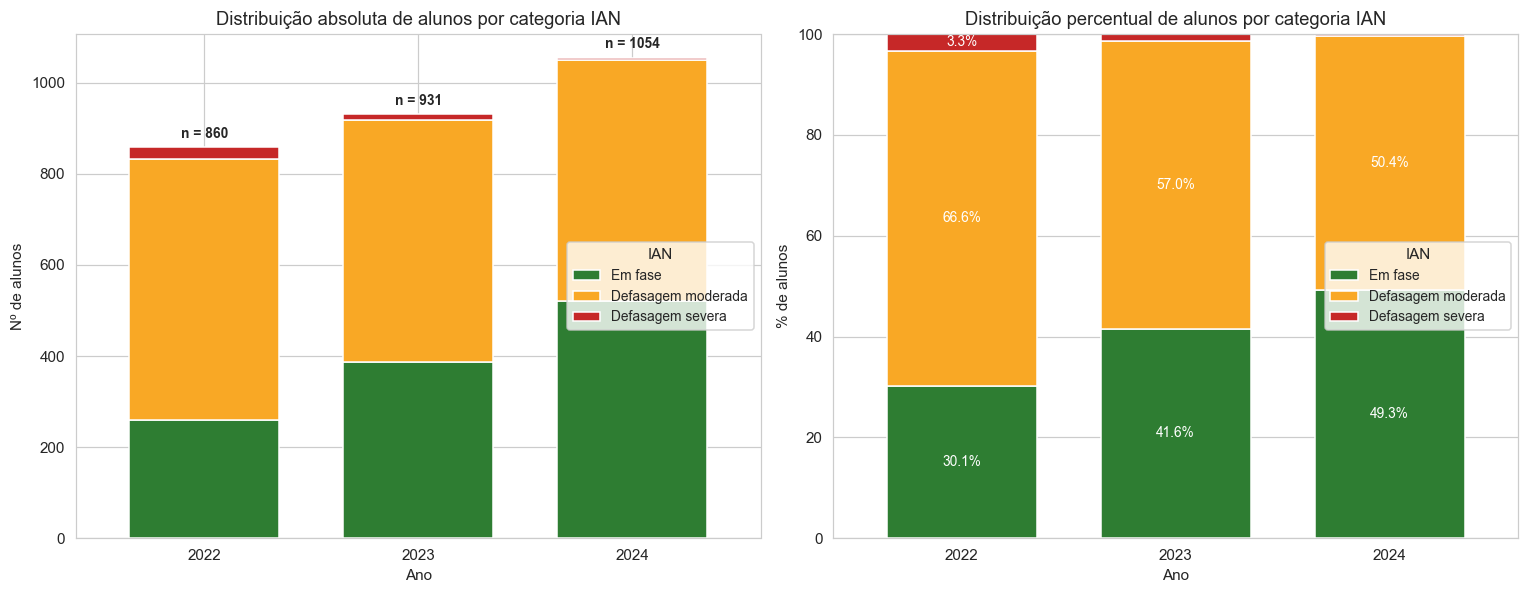

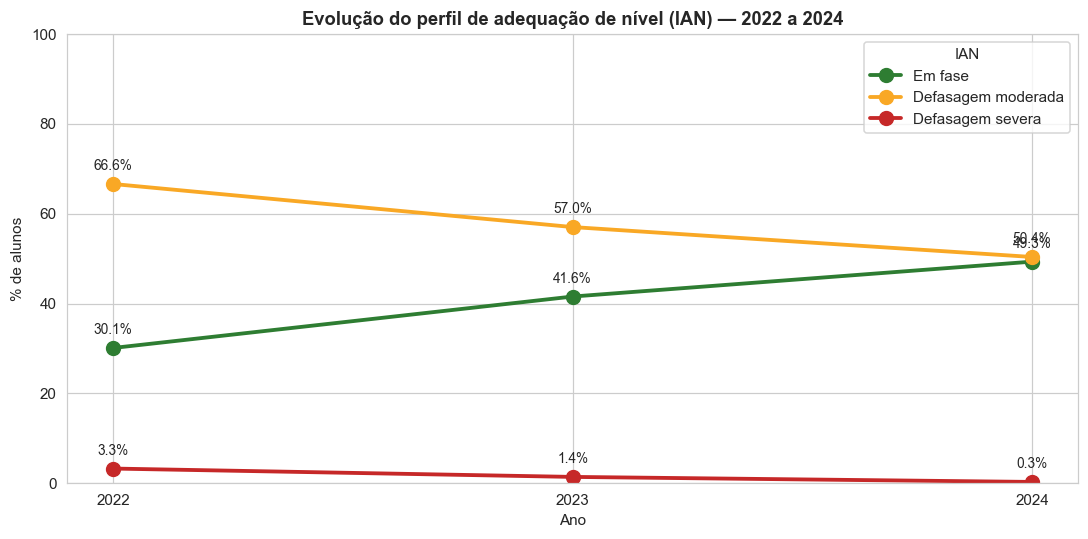

In [44]:
# ============================================================
# 1. Classificação do IAN em categorias legíveis
# ============================================================
def categorizar_ian(ian):
    """Converte o valor numérico do IAN em rótulo textual."""
    if pd.isna(ian):
        return 'Sem informação'
    if ian >= 10:
        return 'Em fase'
    if ian >= 5:
        return 'Defasagem moderada'
    return 'Defasagem severa'

df['IAN_categoria'] = df['IAN'].apply(categorizar_ian)

# Ordem canônica para exibição
ordem_ian = ['Em fase', 'Defasagem moderada', 'Defasagem severa', 'Sem informação']
cores_ian = {
    'Em fase':             '#2E7D32',   # verde
    'Defasagem moderada':  '#F9A825',   # amarelo
    'Defasagem severa':    '#C62828',   # vermelho
    'Sem informação':      '#9E9E9E',   # cinza
}

# Validação cruzada com Defasagem (sanity check)
print("\nValidação IAN × Defasagem:")
print(
    df.groupby('IAN_categoria', observed=True)['Defasagem']
      .agg(['min', 'max', 'count'])
)


# ============================================================
# 3. PERFIL POR ANO — EVOLUÇÃO 2022 → 2023 → 2024
# ============================================================
# --- 3.1 Contagem absoluta por ano e categoria ---
tab_ano = (
    pd.crosstab(df['ano'], df['IAN_categoria'])
      .reindex(columns=ordem_ian, fill_value=0)
)

# ▶ Adiciona total por linha (total de alunos em cada ano)
tab_ano['Total'] = tab_ano.sum(axis=1)

# ▶ Adiciona total por coluna (total geral em cada categoria)
# tab_ano.loc['Total'] = tab_ano.sum(axis=0)

# --- 3.2 Percentual por ano (cálculo feito SEM a coluna Total) ---
#    O % é calculado dentro de cada ano, então usa apenas as colunas de categoria
tab_ano_pct = (
    tab_ano
    .drop(index='Total', columns='Total', errors='ignore')   # remove totais antes do cálculo
    .pipe(lambda d: d.div(d.sum(axis=1), axis=0) * 100)
    .round(2)
)

# ▶ Adiciona total por linha (sempre 100%) e por coluna (participação da categoria no total geral)
# tab_ano_pct['Total'] = tab_ano_pct.sum(axis=1)
# tab_ano_pct.loc['Total'] = (
#     tab_ano.drop(index='Total', columns='Total')
#           .sum(axis=0)
#           / tab_ano.drop(index='Total', columns='Total').values.sum()
#           * 100
# ).round(2)

# Exibição
print("\n" + "=" * 70)
print("CONTAGEM DE ALUNOS POR CATEGORIA IAN E ANO (com totais)")
print("=" * 70)
print(tab_ano.to_string())

print("\n" + "=" * 70)
print("PERCENTUAL (%) POR CATEGORIA IAN E ANO (com totais)")
print("=" * 70)
print(tab_ano_pct.to_string())


# ============================================================
# 4. VISUALIZAÇÃO 1 — Barras empilhadas por ano (contagem + %)
#    Obs.: as colunas/linhas 'Total' NÃO entram no gráfico
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Remove a coluna/linha 'Total' antes de plotar
tab_ano_plot     = tab_ano.drop(columns=['Sem informação', 'Total'], errors='ignore') \
                          .drop(index='Total', errors='ignore')
tab_pct_plot     = tab_ano_pct.drop(columns=['Sem informação', 'Total'], errors='ignore') \
                              .drop(index='Total', errors='ignore')

# ---- 4.1 Contagem absoluta ----
tab_ano_plot.plot(
    kind='bar', stacked=True, ax=axes[0],
    color=[cores_ian[c] for c in tab_ano_plot.columns],
    edgecolor='white', width=0.7
)
axes[0].set_title('Distribuição absoluta de alunos por categoria IAN', fontsize=12)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Nº de alunos')
axes[0].legend(title='IAN', loc='center right', fontsize=9)
axes[0].tick_params(axis='x', rotation=0)

# ▶ Anotação do total no topo de cada barra
for i, ano in enumerate(tab_ano_plot.index):
    total = tab_ano_plot.loc[ano].sum()
    axes[0].text(i, total + total * 0.015, f"n = {int(total)}",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# ---- 4.2 Percentual ----
tab_pct_plot.plot(
    kind='bar', stacked=True, ax=axes[1],
    color=[cores_ian[c] for c in tab_pct_plot.columns],
    edgecolor='white', width=0.7
)
axes[1].set_title('Distribuição percentual de alunos por categoria IAN', fontsize=12)
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('% de alunos')
axes[1].set_ylim(0, 100)
axes[1].legend(title='IAN', loc='center right', fontsize=9)
axes[1].tick_params(axis='x', rotation=0)

# Anotações de percentual
for i, ano in enumerate(tab_pct_plot.index):
    y_cum = 0
    for cat in tab_pct_plot.columns:
        val = tab_pct_plot.loc[ano, cat]
        if val > 3:
            axes[1].text(i, y_cum + val/2, f"{val:.1f}%",
                         ha='center', va='center', fontsize=9, color='white')
        y_cum += val
    # # ▶ Total absoluto no topo
    # axes[1].text(i, 101.5, f"n = {int(tab_ano_plot.loc[ano].sum())}",
    #              ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


# ============================================================
# 5. VISUALIZAÇÃO 2 — Evolução das % ao longo dos anos
#    Obs.: usa tab_ano_pct SEM a linha/coluna 'Total'
# ============================================================
tab_pct_evol = tab_ano_pct.drop(index='Total', columns='Total', errors='ignore')

fig, ax = plt.subplots(figsize=(10, 5))

for cat in ['Em fase', 'Defasagem moderada', 'Defasagem severa']:
    if cat in tab_pct_evol.columns:
        ax.plot(
            tab_pct_evol.index.astype(str),
            tab_pct_evol[cat],
            marker='o', linewidth=2.5, markersize=9,
            color=cores_ian[cat], label=cat
        )
        for x, y in zip(tab_pct_evol.index.astype(str), tab_pct_evol[cat]):
            ax.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                        xytext=(0, 9), ha='center', fontsize=9)

ax.set_title('Evolução do perfil de adequação de nível (IAN) — 2022 a 2024',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('% de alunos')
ax.set_ylim(0, 100)
ax.legend(title='IAN', loc='upper right')
plt.tight_layout()
plt.show()

# 2. Desempenho acadêmico (IDA)
O desempenho acadêmico médio (IDA) está melhorando, estagnado ou 
caindo ao longo das fases e anos?

Obs1: Foi tentado preencher os valores e IDA zerados, não haviam nulos, mas não se demonstrou relevante essa operação.

Obs2: E foram retirados dados nulos e zerados para essa analise.

Pode-se observar uma melhora na média do IDA entre 2022 e 2023, de 6,14 para 6,68. E uma queda em em 2024 para 6,45; ainda superior a 2022. Parece um momento de estagnação.

Nota-se nos boxplots por fase que os valores das medianas caem mais nas fazes intermediárias, entre as fases 3 e 6. Importante decompor essa analise nas notas de cada materia que compõem esse indicador. Onde se nota que a menor média geral é de matemárica para essas fases. 

Importante avaliar quais as materias que estão mais impactando negativamente o IDA em cada fase. No caso das últimas fases o que tem dado maior impacto negativo é o Português.


In [50]:
df = df[(df['IDA'] != 0) | (df['IDA'].isna())].copy()  # dropando os zeros e nulos

# Ordem lógica das fases
ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
               'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

print(f"Base: {df.shape[0]} registros")
print(f"IDA — nulos: {df['IDA'].isna().sum()}")

Base: 2822 registros
IDA — nulos: 0


IDA POR ANO (com totais)
       n_alunos  media  mediana  desvio  minimo  maximo
2022        854  6.136     6.40   1.988     0.7     9.9
2023        930  6.677     6.80   1.580     1.5    10.0
2024       1038  6.448     6.75   1.996     0.5    10.0
Total      2822  6.429     6.70   1.879     0.5    10.0

IDA POR FASE IDEAL (com totais)
              n_alunos  media  mediana  desvio
Fase_Ideal_1                                  
ALFA             234.0  7.514    7.800   1.608
Fase 1           383.0  7.346    7.500   1.550
Fase 2           743.0  6.729    7.000   1.762
Fase 3           638.0  5.946    6.100   1.846
Fase 4           270.0  5.584    5.700   1.876
Fase 5           214.0  5.771    5.683   1.690
Fase 6           168.0  5.867    6.100   1.925
Fase 7           138.0  6.151    6.450   1.864
Fase 8            34.0  5.847    6.650   2.041
Total           2822.0  6.429    6.700   1.879

IDA MÉDIO POR FASE × ANO (com totais)
ano           2022  2023  2024  Média geral
Fase_Ideal_1   

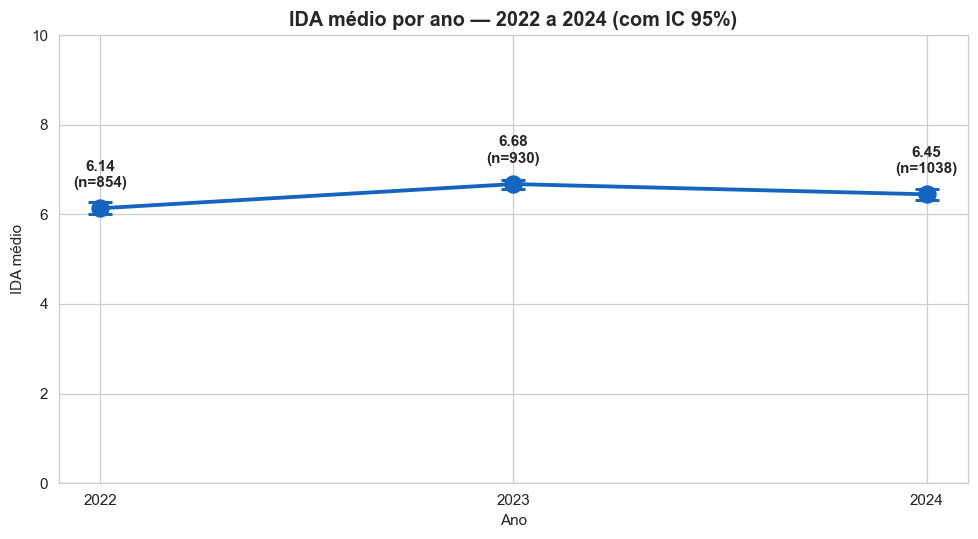

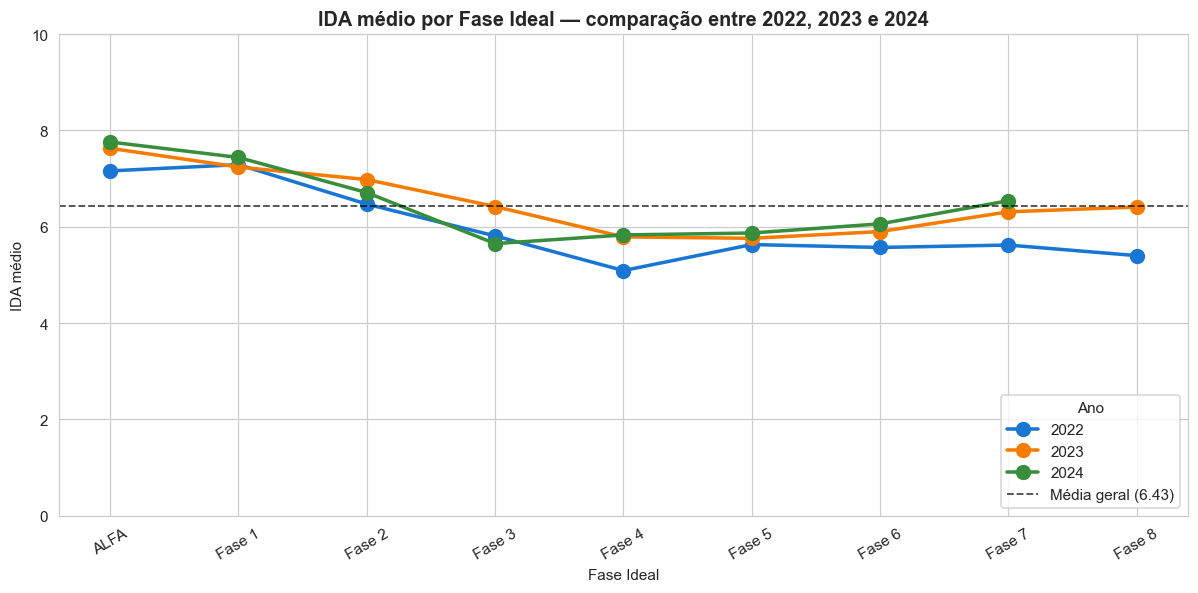

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\3023181929.py:178: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='ano', y='IDA', palette='Set2', ax=axes[0])
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\3023181929.py:186: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fase_Ideal_1', y='IDA',


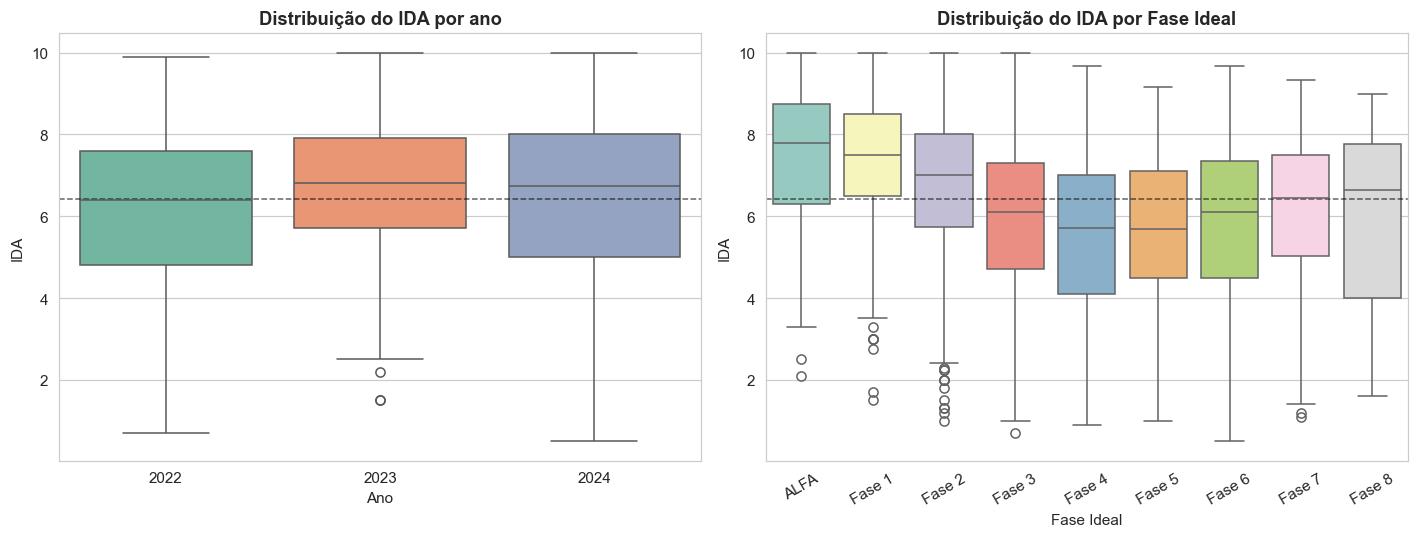

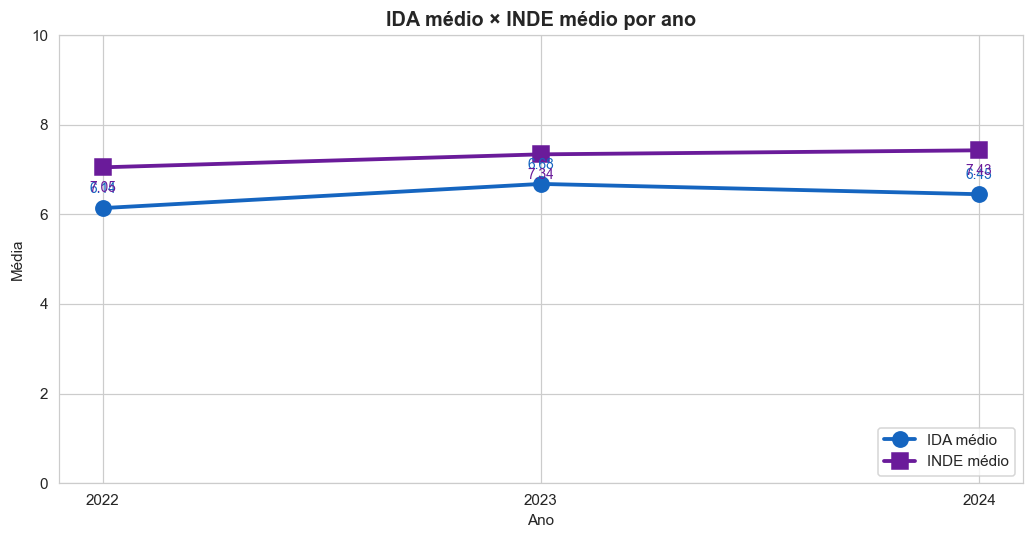


DIAGNÓSTICO AUTOMÁTICO — TENDÊNCIA DO IDA
  2022 → 2023:  Δ = +0.541 pontos
  2023 → 2024:  Δ = -0.229 pontos

Variação total 2022 → 2024: Δ = +0.312 pontos

▶ Tendência global do IDA: OSCILANDO (sem tendência clara)

TENDÊNCIA DO IDA POR FASE (2022 → 2024)
ano           2022  2023  2024  Δ 22→24     Status
Fase_Ideal_1                                      
ALFA          7.16  7.63  7.76     0.60  📈 Melhora
Fase 1        7.29  7.24  7.44     0.14  ➖ Estável
Fase 2        6.47  6.98  6.71     0.24  ➖ Estável
Fase 3        5.81  6.42  5.65    -0.16  ➖ Estável
Fase 4        5.09  5.79  5.83     0.75  📈 Melhora
Fase 5        5.63  5.76  5.87     0.24  ➖ Estável
Fase 6        5.57  5.90  6.06     0.49  📈 Melhora
Fase 7        5.62  6.31  6.54     0.92  📈 Melhora
Fase 8        5.40  6.41   NaN      NaN          —


In [53]:

# ============================================================
# 1. TABELA — IDA médio por ano (com totais)
# ============================================================
tab_ida_ano = (
    df.groupby('ano', observed=True)['IDA']
      .agg(n_alunos='size',
           media='mean',
           mediana='median',
           desvio='std',
           minimo='min',
           maximo='max')
      .round(3)
)

# Linha de total geral
total_row = pd.DataFrame({
    'n_alunos': [tab_ida_ano['n_alunos'].sum()],
    'media':    [round(df['IDA'].mean(), 3)],
    'mediana':  [round(df['IDA'].median(), 3)],
    'desvio':   [round(df['IDA'].std(), 3)],
    'minimo':   [round(df['IDA'].min(), 3)],
    'maximo':   [round(df['IDA'].max(), 3)],
}, index=['Total'])

tab_ida_ano = pd.concat([tab_ida_ano, total_row])

print("=" * 70)
print("IDA POR ANO (com totais)")
print("=" * 70)
print(tab_ida_ano.to_string())


# ============================================================
# 2. TABELA — IDA médio por fase (com totais)
# ============================================================
tab_ida_fase = (
    df.groupby('Fase_Ideal_1', observed=True)['IDA']
      .agg(n_alunos='size',
           media='mean',
           mediana='median',
           desvio='std')
      .round(3)
)

# Total geral
tab_ida_fase.loc['Total'] = [
    tab_ida_fase['n_alunos'].sum(),
    round(df['IDA'].mean(), 3),
    round(df['IDA'].median(), 3),
    round(df['IDA'].std(), 3),
]

print("\n" + "=" * 70)
print("IDA POR FASE IDEAL (com totais)")
print("=" * 70)
print(tab_ida_fase.to_string())


# ============================================================
# 3. TABELA CRUZADA — IDA médio por fase × ano (com totais)
# ============================================================
pivot_ida = (
    df.pivot_table(index='Fase_Ideal_1',
                   columns='ano',
                   values='IDA',
                   aggfunc='mean',
                   observed=True)
      .round(2)
)

# Total por coluna (média geral de cada ano)
pivot_ida.loc['Total'] = pivot_ida.mean(axis=0).round(2)

# Total por linha (média do aluno em cada fase ao longo dos anos)
pivot_ida['Média geral'] = (
    df.groupby('Fase_Ideal_1', observed=True)['IDA'].mean().round(2)
)
# Ajusta a linha Total
pivot_ida.loc['Total', 'Média geral'] = round(df['IDA'].mean(), 2)

print("\n" + "=" * 70)
print("IDA MÉDIO POR FASE × ANO (com totais)")
print("=" * 70)
print(pivot_ida.to_string())


# ============================================================
# 4. TABELA CRUZADA auxiliar — n de alunos por fase × ano
#    (para contextualizar as médias)
# ============================================================
pivot_n = (
    df.pivot_table(index='Fase_Ideal_1',
                   columns='ano',
                   values='IDA',
                   aggfunc='size',
                   observed=True)
      .fillna(0)
      .astype(int)
)
pivot_n.loc['Total'] = pivot_n.sum(axis=0)
pivot_n['Total'] = pivot_n.sum(axis=1)

print("\n" + "=" * 70)
print("Nº DE ALUNOS POR FASE × ANO (com totais)")
print("=" * 70)
print(pivot_n.to_string())


# ============================================================
# 5. VISUALIZAÇÃO 1 — IDA médio por ano (com intervalo de confiança)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

ida_ano_stats = df.groupby('ano', observed=True)['IDA'].agg(['mean', 'std', 'count'])
ida_ano_stats['se'] = ida_ano_stats['std'] / np.sqrt(ida_ano_stats['count'])

ax.errorbar(ida_ano_stats.index.astype(str),
            ida_ano_stats['mean'],
            yerr=ida_ano_stats['se'] * 1.96,   # IC 95%
            marker='o', markersize=11, linewidth=2.5,
            color='#1565C0', capsize=8, capthick=2)

for x, y, n in zip(ida_ano_stats.index.astype(str),
                   ida_ano_stats['mean'],
                   ida_ano_stats['count']):
    ax.annotate(f"{y:.2f}\n(n={n})", (x, y),
                textcoords="offset points", xytext=(0, 14),
                ha='center', fontsize=10, fontweight='bold')

ax.set_title('IDA médio por ano — 2022 a 2024 (com IC 95%)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('IDA médio')
ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()


# ============================================================
# 6. VISUALIZAÇÃO 2 — IDA médio por fase, linha por ano
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

cores_ano = {2022: '#1976D2', 2023: '#F57C00', 2024: '#388E3C'}
tab_plot = pivot_ida.drop(index='Total', columns='Média geral', errors='ignore')

for ano in tab_plot.columns:
    ax.plot(tab_plot.index.astype(str),
            tab_plot[ano],
            marker='o', linewidth=2.3, markersize=9,
            color=cores_ano.get(int(ano), 'gray'),
            label=f'{int(ano)}')

# Linha de referência da média geral (todas as fases, todos os anos)
ax.axhline(df['IDA'].mean(), color='black', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Média geral ({df["IDA"].mean():.2f})')

ax.set_title('IDA médio por Fase Ideal — comparação entre 2022, 2023 e 2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fase Ideal')
ax.set_ylabel('IDA médio')
ax.set_ylim(0, 10)
ax.legend(title='Ano', loc='lower right')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()




# ============================================================
# 8. VISUALIZAÇÃO 4 — Boxplot IDA por ano (distribuição)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 8.1 IDA por ano
sns.boxplot(data=df, x='ano', y='IDA', palette='Set2', ax=axes[0])
axes[0].set_title('Distribuição do IDA por ano', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IDA')
axes[0].axhline(df['IDA'].mean(), color='black', linestyle='--',
                linewidth=1, alpha=0.6)

# 8.2 IDA por fase
sns.boxplot(data=df, x='Fase_Ideal_1', y='IDA',
            palette='Set3', ax=axes[1])
axes[1].set_title('Distribuição do IDA por Fase Ideal', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fase Ideal')
axes[1].set_ylabel('IDA')
axes[1].axhline(df['IDA'].mean(), color='black', linestyle='--',
                linewidth=1, alpha=0.6)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 5 — IDA vs INDE por ano (linhas paralelas)
#    Ajuda a saber se o IDA puxa o INDE junto ou não
# ============================================================
fig, ax = plt.subplots(figsize=(9.5, 5))

comp = (
    df.groupby('ano', observed=True)[['IDA', 'INDE_ano_atual']]
      .mean()
      .round(2)
)

ax.plot(comp.index.astype(str), comp['IDA'],
        marker='o', linewidth=2.5, markersize=10,
        color='#1565C0', label='IDA médio')

ax.plot(comp.index.astype(str), comp['INDE_ano_atual'],
        marker='s', linewidth=2.5, markersize=10,
        color='#6A1B9A', label='INDE médio')

for x, y in zip(comp.index.astype(str), comp['IDA']):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=9, color='#1565C0')
for x, y in zip(comp.index.astype(str), comp['INDE_ano_atual']):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                xytext=(0, -16), ha='center', fontsize=9, color='#6A1B9A')

ax.set_title('IDA médio × INDE médio por ano', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Média')
ax.set_ylim(0, 10)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


# ============================================================
# 10. DIAGNÓSTICO AUTOMÁTICO — melhora, estagnação ou queda?
# ============================================================
print("\n" + "=" * 70)
print("DIAGNÓSTICO AUTOMÁTICO — TENDÊNCIA DO IDA")
print("=" * 70)

medias = df.groupby('ano', observed=True)['IDA'].mean().sort_index()
anos   = medias.index.tolist()

variacoes = []
for i in range(1, len(medias)):
    delta = medias.iloc[i] - medias.iloc[i-1]
    variacoes.append(delta)
    print(f"  {anos[i-1]} → {anos[i]}:  Δ = {delta:+.3f} pontos")

delta_total = medias.iloc[-1] - medias.iloc[0]
print(f"\nVariação total {anos[0]} → {anos[-1]}: Δ = {delta_total:+.3f} pontos")

# Classificação simples
if all(v > 0.05 for v in variacoes):
    tendencia = "MELHORANDO consistentemente"
elif all(v < -0.05 for v in variacoes):
    tendencia = "CAINDO consistentemente"
elif abs(delta_total) < 0.15:
    tendencia = "ESTAGNADO"
else:
    tendencia = "OSCILANDO (sem tendência clara)"

print(f"\n▶ Tendência global do IDA: {tendencia}")

# Por fase — quais fases melhoraram/pioraram?
print("\n" + "=" * 70)
print("TENDÊNCIA DO IDA POR FASE (2022 → 2024)")
print("=" * 70)

fase_trend = (
    df.pivot_table(index='Fase_Ideal_1', columns='ano',
                   values='IDA', aggfunc='mean', observed=True)
)
fase_trend['Δ 22→24'] = (fase_trend[2024] - fase_trend[2022]).round(2)

def classificar(delta):
    if pd.isna(delta):  return '—'
    if delta >  0.3:    return '📈 Melhora'
    if delta < -0.3:    return '📉 Queda'
    return '➖ Estável'

fase_trend['Status'] = fase_trend['Δ 22→24'].apply(classificar)
print(fase_trend.round(2).to_string())

Base: 2822 registros
COBERTURA (%) — % de valores não nulos por matéria e ano
         Mat    Por   Ing    IDA
2022   100.0  100.0  33.1  100.0
2023   100.0  100.0  35.3  100.0
2024    99.7   99.5  44.6  100.0
Total   99.9   99.8  38.1  100.0

DESCRITIVAS POR ANO (média / mediana / desvio)
       Mat                Por                Ing             
      mean median   std  mean median   std  mean median   std
ano                                                          
2022  5.83    6.0  2.39  6.35    6.7  2.04  5.88    6.3  2.96
2023  6.42    6.5  1.81  6.83    7.0  1.82  6.21    6.5  2.24
2024  6.32    6.5  2.70  6.27    6.5  2.27  6.73    7.0  2.74

DESCRITIVAS POR FASE IDEAL (média / mediana / desvio)
               Mat                Por                Ing             
              mean median   std  mean median   std  mean median   std
Fase_Ideal_1                                                         
ALFA          7.58    8.0  1.94  7.42   8.00  1.85   NaN    NaN   NaN
Fa

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\725257653.py:184: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[MATERIAS + ['IDA']].corr()['IDA'][MATERIAS])
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\725257653.py:189: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g[MATERIAS + ['IDA']].corr()['IDA'][MATERIAS])


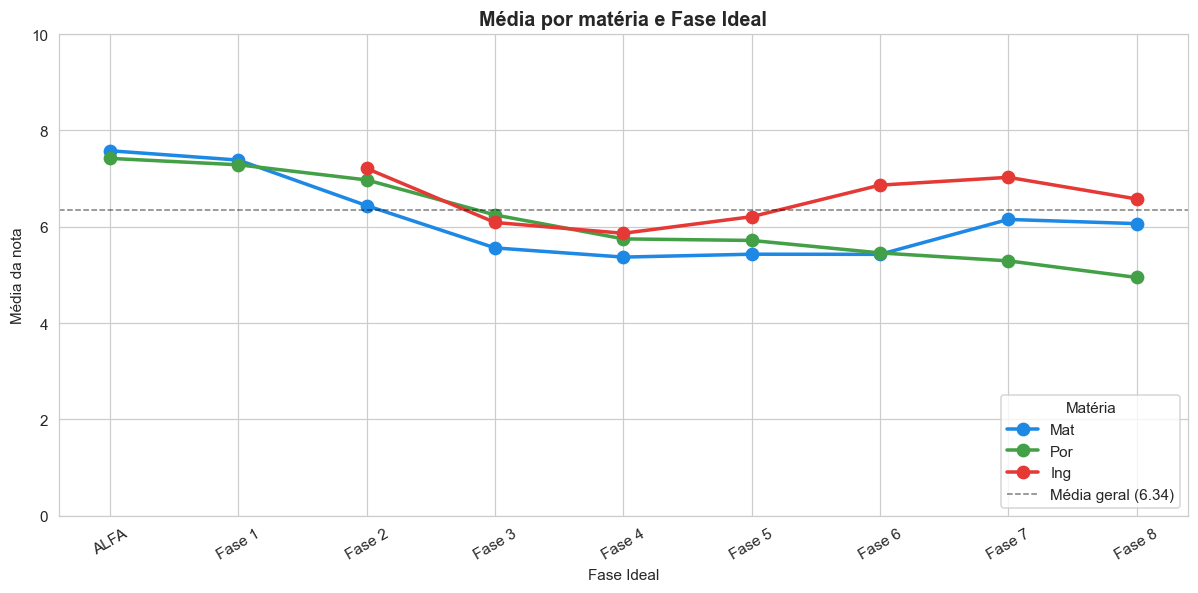

In [52]:

# df['ano'] = df['ano'].astype('Int64')

# ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
#                'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

MATERIAS = ['Mat', 'Por', 'Ing']
CORES = {'Mat': '#1E88E5', 'Por': '#43A047', 'Ing': '#E53935'}

print(f"Base: {df.shape[0]} registros")


# ============================================================
# 1. COBERTURA — quantos nulos cada matéria tem
# ============================================================
cobertura_ano = (
    df.groupby('ano', observed=True)[MATERIAS]
      .apply(lambda g: g.notna().mean() * 100)
      .round(1)
)
cobertura_ano['IDA'] = (
    df.groupby('ano', observed=True)['IDA']
      .apply(lambda s: s.notna().mean() * 100)
      .round(1)
)

# Total geral
cobertura_total = (df[MATERIAS + ['IDA']].notna().mean() * 100).round(1)
cobertura_total.name = 'Total'

cobertura_ano = pd.concat([cobertura_ano, cobertura_total.to_frame().T])

print("=" * 70)
print("COBERTURA (%) — % de valores não nulos por matéria e ano")
print("=" * 70)
print(cobertura_ano.to_string())


# ============================================================
# 2. ESTATÍSTICAS DESCRITIVAS por matéria — global, por ano e por fase
# ============================================================
def resumo_por(df_in, grupo):
    """Retorna tabela com média/mediana/std por matéria para o grupo dado."""
    return (
        df_in.groupby(grupo, observed=True)[MATERIAS]
             .agg(['mean', 'median', 'std'])
             .round(2)
    )

# -- 2.1 Por ano --
desc_ano = resumo_por(df, 'ano')
print("\n" + "=" * 70)
print("DESCRITIVAS POR ANO (média / mediana / desvio)")
print("=" * 70)
print(desc_ano.to_string())

# -- 2.2 Por fase --
desc_fase = resumo_por(df, 'Fase_Ideal_1')
print("\n" + "=" * 70)
print("DESCRITIVAS POR FASE IDEAL (média / mediana / desvio)")
print("=" * 70)
print(desc_fase.to_string())

# -- 2.3 Por fase × ano (somente médias para ficar enxuto) --
media_fase_ano = (
    df.pivot_table(index='Fase_Ideal_1', columns='ano',
                   values=MATERIAS, aggfunc='mean', observed=True)
      .round(2)
)
print("\n" + "=" * 70)
print("MÉDIAS POR FASE × ANO")
print("=" * 70)
print(media_fase_ano.to_string())


# ============================================================
# 3. GAP ATÉ O TETO (10) — quem mais "perde pontos" no IDA
#    Déficit = 10 - média da matéria
#    Contribuição ao déficit do IDA = déficit / 3
# ============================================================
def gap_table(df_in, grupo):
    med = df_in.groupby(grupo, observed=True)[MATERIAS].mean()
    gap = (10 - med).round(2)
    gap['Déficit_total_IDA'] = (gap[MATERIAS].sum(axis=1) / 3).round(2)
    # Ranking: qual matéria tem MAIOR déficit (ou seja, puxa mais o IDA para baixo)
    gap['Matéria_crítica'] = gap[MATERIAS].idxmax(axis=1)
    return gap

gap_ano  = gap_table(df, 'ano')
gap_fase = gap_table(df, 'Fase_Ideal_1')

print("\n" + "=" * 70)
print("DÉFICIT ATÉ 10 POR ANO (quem puxa o IDA para baixo)")
print("=" * 70)
print(gap_ano.to_string())

print("\n" + "=" * 70)
print("DÉFICIT ATÉ 10 POR FASE IDEAL")
print("=" * 70)
print(gap_fase.to_string())


# ============================================================
# 4. DECOMPOSIÇÃO DA VARIÂNCIA DO IDA
#    Var(IDA) = [Var(M)+Var(P)+Var(I) + 2*(Cov_MP+Cov_MI+Cov_PI)] / 9
#    Atribuímos a cada matéria:
#      - sua variância própria
#      - metade das covariâncias em que participa
# ============================================================
def decompor_variancia(df_in, grupo='ano'):
    """Retorna % da variância do IDA explicada por cada matéria, por grupo."""
    resultados = []
    for g, sub in df_in.groupby(grupo, observed=True):
        sub = sub[MATERIAS + ['IDA']].dropna()
        if len(sub) < 10:
            continue
        cov = sub[MATERIAS].cov().values
        v_m, v_p, v_i = cov[0,0], cov[1,1], cov[2,2]
        c_mp, c_mi, c_pi = cov[0,1], cov[0,2], cov[1,2]

        contrib_m = v_m + c_mp + c_mi
        contrib_p = v_p + c_mp + c_pi
        contrib_i = v_i + c_mi + c_pi
        total = contrib_m + contrib_p + contrib_i

        resultados.append({
            grupo: g,
            'n': len(sub),
            'Mat_%': round(contrib_m / total * 100, 1),
            'Por_%': round(contrib_p / total * 100, 1),
            'Ing_%': round(contrib_i / total * 100, 1),
        })
    return pd.DataFrame(resultados).set_index(grupo)

var_ano  = decompor_variancia(df, 'ano')
var_fase = decompor_variancia(df, 'Fase_Ideal_1')

print("\n" + "=" * 70)
print("DECOMPOSIÇÃO DA VARIÂNCIA DO IDA (%) POR ANO")
print("=" * 70)
print(var_ano.to_string())

print("\n" + "=" * 70)
print("DECOMPOSIÇÃO DA VARIÂNCIA DO IDA (%) POR FASE")
print("=" * 70)
print(var_fase.to_string())


# ============================================================
# 5. BOTTLENECK — qual matéria é o "gargalo" do aluno
#    Para cada aluno, identifica a MENOR das 3 notas.
#    A matéria mais frequente como menor nota é a que mais limita o IDA.
# ============================================================
def bottleneck(df_in, grupo):
    sub = df_in[MATERIAS].dropna()
    idx = sub.index
    menor = sub.idxmin(axis=1)

    tab = pd.crosstab(df_in.loc[idx, grupo], menor, normalize='index') * 100
    tab = tab.round(1).reindex(columns=MATERIAS, fill_value=0)

    # coluna de matéria mais frequente
    tab['Crítica'] = tab[MATERIAS].idxmax(axis=1)
    return tab

bn_ano  = bottleneck(df, 'ano')
bn_fase = bottleneck(df, 'Fase_Ideal_1')

print("\n" + "=" * 70)
print("GARGALO (%) — % de alunos em que cada matéria é a PIOR nota")
print("=" * 70)
print("Por ano:")
print(bn_ano.to_string())
print("\nPor fase:")
print(bn_fase.to_string())


# ============================================================
# 6. CORRELAÇÃO COM IDA
# ============================================================
corr_ano = (
    df.groupby('ano', observed=True)
      .apply(lambda g: g[MATERIAS + ['IDA']].corr()['IDA'][MATERIAS])
      .round(3)
)
corr_fase = (
    df.groupby('Fase_Ideal_1', observed=True)
      .apply(lambda g: g[MATERIAS + ['IDA']].corr()['IDA'][MATERIAS])
      .round(3)
)

print("\n" + "=" * 70)
print("CORRELAÇÃO DE PEARSON DE CADA MATÉRIA COM O IDA")
print("=" * 70)
print("Por ano:")
print(corr_ano.to_string())
print("\nPor fase:")
print(corr_fase.to_string())


# ============================================================
# 8. VISUALIZAÇÃO 2 — Médias por fase (linhas paralelas por matéria)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))
medias_por_fase = df.groupby('Fase_Ideal_1', observed=True)[MATERIAS].mean()

for m in MATERIAS:
    ax.plot(medias_por_fase.index.astype(str), medias_por_fase[m],
            marker='o', linewidth=2.3, markersize=8,
            color=CORES[m], label=m)

ax.axhline(df[MATERIAS].mean().mean(), color='black',
           linestyle='--', linewidth=1, alpha=0.5,
           label=f'Média geral ({df[MATERIAS].mean().mean():.2f})')

ax.set_title('Média por matéria e Fase Ideal',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fase Ideal')
ax.set_ylabel('Média da nota')
ax.set_ylim(0, 10)
ax.legend(title='Matéria', loc='lower right')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



# 3. Engajamento nas atividades (IEG)
O grau de engajamento dos alunos (IEG) tem relação direta com seus 
indicadores de desempenho (IDA) e do ponto de virada (IPV)?

A correlação  entre o Engajamento nas atividades (IEG) são moderadamente relacionadas com os indicadores de desempenho (IDA) e do ponto de virada (IPV)

  IEG × IDA: r = +0.544  →  Moderada    
  IEG × IPV: r = +0.558  →  Moderada

Quando se analisa por fase, se percebe que a uma correlação mais forte entre IEG e IDA, nas fases 4 até a 8, e mais fraca nas primeiras fases (ALFA e fase 1). O que demonstra que há um crescimento dessa correlação conforme se avança entre as fases. 

Nas fases onde a correlação é mais fraca pode ser um indicativo da necessidade da reformulação das atividades, se essas tem o objetivo de refletir nos outros indicadores.

Por fase (Pearson):
  ALFA — IEG×IDA: r=+0.383 (Fraca-moderada)   |   IEG×IPV: r=+0.509 (Moderada)
  Fase 1 — IEG×IDA: r=+0.283 (Fraca-moderada)   |   IEG×IPV: r=+0.383 (Fraca-moderada)
  Fase 2 — IEG×IDA: r=+0.485 (Moderada)   |   IEG×IPV: r=+0.517 (Moderada)
  Fase 3 — IEG×IDA: r=+0.468 (Moderada)   |   IEG×IPV: r=+0.609 (Forte)
  Fase 4 — IEG×IDA: r=+0.602 (Forte)   |   IEG×IPV: r=+0.657 (Forte)
  Fase 5 — IEG×IDA: r=+0.652 (Forte)   |   IEG×IPV: r=+0.563 (Moderada)
  Fase 6 — IEG×IDA: r=+0.602 (Forte)   |   IEG×IPV: r=+0.674 (Forte)
  Fase 7 — IEG×IDA: r=+0.732 (Forte)   |   IEG×IPV: r=+0.427 (Moderada)
  Fase 8 — IEG×IDA: r=+0.707 (Forte)   |   IEG×IPV: r=+0.482 (Moderada)

Base: 2845 registros
COBERTURA (%) — IEG, IDA, IPV
IEG    100.0
IDA    100.0
IPV    100.0

Registros com as 3 variáveis preenchidas: 2845 (100.0%)

CORRELAÇÃO GLOBAL (n = 2845)

Pearson:
  IEG × IDA: r = +0.544   p = 0.0000
  IEG × IPV: r = +0.558   p = 0.0000

Spearman:
  IEG × IDA: r = +0.499   p = 0.0000
  IEG × IPV: r = +0.546   p = 0.0000

CORRELAÇÃO POR ANO — Pearson
         n  r_IEG_IDA  p_IEG_IDA  r_IEG_IPV  p_IEG_IPV
ano                                                   
2022   860      0.564        0.0      0.589        0.0
2023   931      0.461        0.0      0.448        0.0
2024  1054      0.547        0.0      0.535        0.0

CORRELAÇÃO POR ANO — Spearman
         n  r_IEG_IDA  p_IEG_IDA  r_IEG_IPV  p_IEG_IPV
ano                                                   
2022   860      0.507        0.0      0.540        0.0
2023   931      0.446        0.0      0.491        0.0
2024  1054      0.519        0.0      0.551        0.0

CORRELAÇÃO POR FASE — Pearson
            

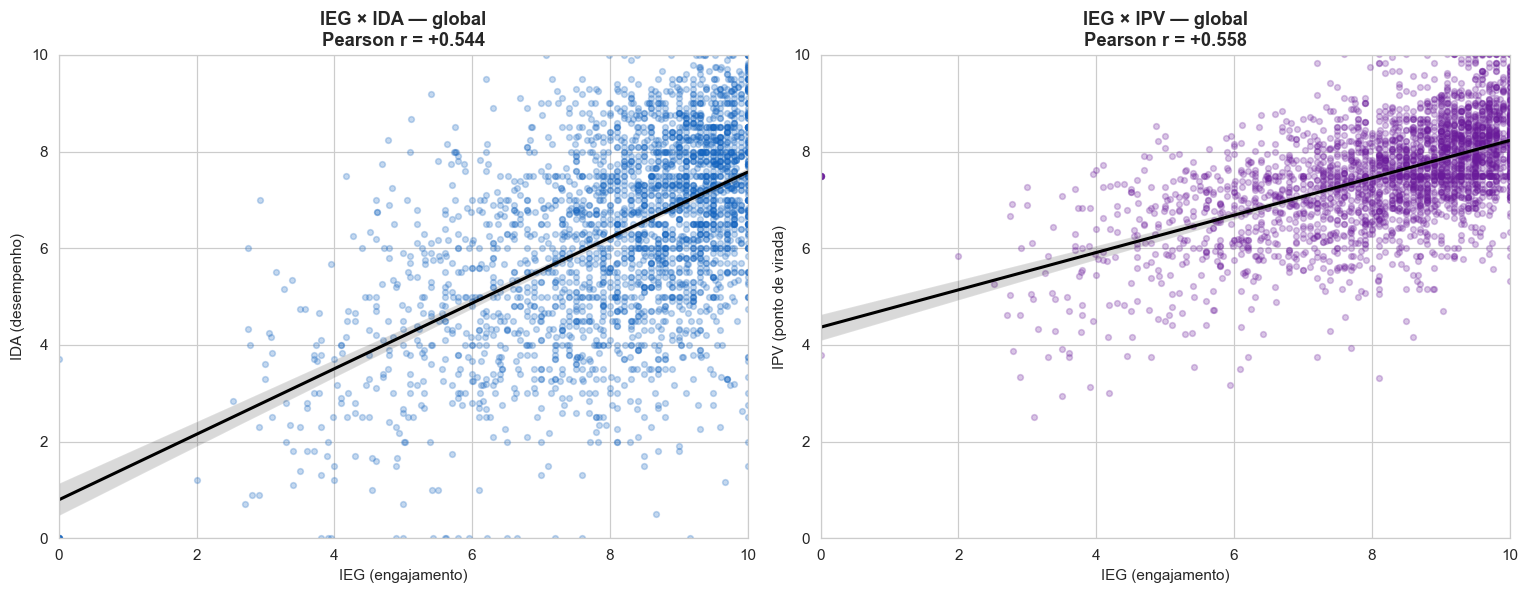


DIAGNÓSTICO — FORÇA DAS RELAÇÕES
  IEG × IDA: r = +0.544  →  Moderada
  IEG × IPV: r = +0.558  →  Moderada

Por ano (Pearson):
  2022 — IEG×IDA: r=+0.564 (Moderada)   |   IEG×IPV: r=+0.589 (Moderada)
  2023 — IEG×IDA: r=+0.461 (Moderada)   |   IEG×IPV: r=+0.448 (Moderada)
  2024 — IEG×IDA: r=+0.547 (Moderada)   |   IEG×IPV: r=+0.535 (Moderada)

Por fase (Pearson):
  ALFA — IEG×IDA: r=+0.383 (Fraca-moderada)   |   IEG×IPV: r=+0.509 (Moderada)
  Fase 1 — IEG×IDA: r=+0.283 (Fraca-moderada)   |   IEG×IPV: r=+0.383 (Fraca-moderada)
  Fase 2 — IEG×IDA: r=+0.485 (Moderada)   |   IEG×IPV: r=+0.517 (Moderada)
  Fase 3 — IEG×IDA: r=+0.468 (Moderada)   |   IEG×IPV: r=+0.609 (Forte)
  Fase 4 — IEG×IDA: r=+0.602 (Forte)   |   IEG×IPV: r=+0.657 (Forte)
  Fase 5 — IEG×IDA: r=+0.652 (Forte)   |   IEG×IPV: r=+0.563 (Moderada)
  Fase 6 — IEG×IDA: r=+0.602 (Forte)   |   IEG×IPV: r=+0.674 (Forte)
  Fase 7 — IEG×IDA: r=+0.732 (Forte)   |   IEG×IPV: r=+0.427 (Moderada)
  Fase 8 — IEG×IDA: r=+0.707 (Forte) 

In [57]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
               'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

print(f"Base: {df.shape[0]} registros")


# ============================================================
# 1. COBERTURA E NULOS DAS 3 VARIÁVEIS
# ============================================================
vars_alvo = ['IEG', 'IDA', 'IPV']
cov = df[vars_alvo].notna().mean().mul(100).round(2)
print("=" * 70)
print("COBERTURA (%) — IEG, IDA, IPV")
print("=" * 70)
print(cov.to_string())

# Amostra conjunta (só quem tem as 3 variáveis preenchidas)
mask_ok = df[vars_alvo].notna().all(axis=1)
df_ok = df[mask_ok].copy()
print(f"\nRegistros com as 3 variáveis preenchidas: {len(df_ok)} "
      f"({len(df_ok)/len(df)*100:.1f}%)")


# ============================================================
# 2. CORRELAÇÃO — Pearson e Spearman
# ============================================================
def corr_tabela(df_in, grupo, metodo='pearson'):
    """Correlação de IEG com IDA e IEG com IPV por grupo."""
    res = []
    for g, sub in df_in.groupby(grupo, observed=True):
        sub2 = sub[vars_alvo].dropna()
        if len(sub2) < 20:
            continue
        if metodo == 'pearson':
            r_ida, p_ida = stats.pearsonr(sub2['IEG'], sub2['IDA'])
            r_ipv, p_ipv = stats.pearsonr(sub2['IEG'], sub2['IPV'])
        else:
            r_ida, p_ida = stats.spearmanr(sub2['IEG'], sub2['IDA'])
            r_ipv, p_ipv = stats.spearmanr(sub2['IEG'], sub2['IPV'])
        res.append({
            grupo: g, 'n': len(sub2),
            'r_IEG_IDA': round(r_ida, 3), 'p_IEG_IDA': round(p_ida, 4),
            'r_IEG_IPV': round(r_ipv, 3), 'p_IEG_IPV': round(p_ipv, 4),
        })
    return pd.DataFrame(res).set_index(grupo)

# Global
global_corr = {}
for metodo in ['pearson', 'spearman']:
    sub = df_ok[vars_alvo]
    if metodo == 'pearson':
        r_ida, p_ida = stats.pearsonr(sub['IEG'], sub['IDA'])
        r_ipv, p_ipv = stats.pearsonr(sub['IEG'], sub['IPV'])
    else:
        r_ida, p_ida = stats.spearmanr(sub['IEG'], sub['IDA'])
        r_ipv, p_ipv = stats.spearmanr(sub['IEG'], sub['IPV'])
    global_corr[metodo] = {
        'IEG × IDA': (round(r_ida, 3), round(p_ida, 4)),
        'IEG × IPV': (round(r_ipv, 3), round(p_ipv, 4)),
    }

print("\n" + "=" * 70)
print("CORRELAÇÃO GLOBAL (n = {})".format(len(df_ok)))
print("=" * 70)
for metodo, d in global_corr.items():
    print(f"\n{metodo.capitalize()}:")
    for k, (r, p) in d.items():
        print(f"  {k}: r = {r:+.3f}   p = {p:.4f}")

# Por ano
corr_ano_pear = corr_tabela(df_ok, 'ano', 'pearson')
corr_ano_spear = corr_tabela(df_ok, 'ano', 'spearman')
print("\n" + "=" * 70)
print("CORRELAÇÃO POR ANO — Pearson")
print("=" * 70)
print(corr_ano_pear.to_string())
print("\n" + "=" * 70)
print("CORRELAÇÃO POR ANO — Spearman")
print("=" * 70)
print(corr_ano_spear.to_string())

# Por fase
corr_fase_pear = corr_tabela(df_ok, 'Fase_Ideal_1', 'pearson')
print("\n" + "=" * 70)
print("CORRELAÇÃO POR FASE — Pearson")
print("=" * 70)
print(corr_fase_pear.to_string())


# ============================================================
# 3. REGRESSÃO LINEAR SIMPLES — quantifica o efeito
# ============================================================
def reg_simples(df_in, x_col, y_col):
    sub = df_in[[x_col, y_col]].dropna()
    X = sm.add_constant(sub[x_col])
    modelo = sm.OLS(sub[y_col], X).fit()
    return {
        'n': int(modelo.nobs),
        'coef': round(modelo.params[x_col], 4),
        'const': round(modelo.params['const'], 4),
        'R2': round(modelo.rsquared, 4),
        'p_valor': round(modelo.pvalues[x_col], 6),
    }

print("\n" + "=" * 70)
print("REGRESSÃO LINEAR SIMPLES")
print("=" * 70)

for y in ['IDA', 'IPV']:
    print(f"\n▶ {y} ~ IEG (global):")
    r = reg_simples(df_ok, 'IEG', y)
    for k, v in r.items():
        print(f"  {k:>8}: {v}")

# Por ano
print("\n" + "=" * 70)
print("REGRESSÃO POR ANO — IDA ~ IEG")
print("=" * 70)
for ano, sub in df_ok.groupby('ano', observed=True):
    r = reg_simples(sub, 'IEG', 'IDA')
    print(f"  {ano}: coef={r['coef']:+.4f}  R²={r['R2']:.4f}  "
          f"p={r['p_valor']:.4f}  n={r['n']}")

print("\n" + "=" * 70)
print("REGRESSÃO POR ANO — IPV ~ IEG")
print("=" * 70)
for ano, sub in df_ok.groupby('ano', observed=True):
    r = reg_simples(sub, 'IEG', 'IPV')
    print(f"  {ano}: coef={r['coef']:+.4f}  R²={r['R2']:.4f}  "
          f"p={r['p_valor']:.4f}  n={r['n']}")


# ============================================================
# 4. REGRESSÃO MÚLTIPLA — IEG + IDA como preditores de IPV
# ============================================================
sub = df_ok[['IPV', 'IEG', 'IDA']].dropna()
X = sm.add_constant(sub[['IEG', 'IDA']])
modelo = sm.OLS(sub['IPV'], X).fit()

print("\n" + "=" * 70)
print("REGRESSÃO MÚLTIPLA — IPV ~ IEG + IDA")
print("=" * 70)
print(modelo.summary().tables[1])
print(f"\nR² = {modelo.rsquared:.4f}   R² ajustado = {modelo.rsquared_adj:.4f}   n = {int(modelo.nobs)}")


# ============================================================
# 5. QUARTIS DE IEG — IDA e IPV médios por nível de engajamento
# ============================================================
df_ok['IEG_quartil'] = pd.qcut(df_ok['IEG'], q=4,
                               labels=['Q1 (baixo)', 'Q2', 'Q3', 'Q4 (alto)'])

quartis = (
    df_ok.groupby('IEG_quartil', observed=True)
         .agg(n=('IEG', 'size'),
              IEG_medio=('IEG', 'mean'),
              IDA_medio=('IDA', 'mean'),
              IPV_medio=('IPV', 'mean'))
         .round(2)
)

print("\n" + "=" * 70)
print("IDA E IPV MÉDIOS POR QUARTIL DE IEG")
print("=" * 70)
print(quartis.to_string())

# Ganho do Q1 para o Q4
delta_ida = quartis.loc['Q4 (alto)', 'IDA_medio'] - quartis.loc['Q1 (baixo)', 'IDA_medio']
delta_ipv = quartis.loc['Q4 (alto)', 'IPV_medio'] - quartis.loc['Q1 (baixo)', 'IPV_medio']
print(f"\n▶ Diferença Q4 − Q1 no IDA: {delta_ida:+.2f} pontos")
print(f"▶ Diferença Q4 − Q1 no IPV: {delta_ipv:+.2f} pontos")


# ============================================================
# 6. VISUALIZAÇÃO 1 — Dispersão IEG × IDA e IEG × IPV (global)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 6.1 IEG × IDA
ax = axes[0]
sns.regplot(data=df_ok, x='IEG', y='IDA', ax=ax,
            scatter_kws={'alpha': 0.25, 's': 14, 'color': '#1565C0'},
            line_kws={'color': 'black', 'linewidth': 2})
r_ida = stats.pearsonr(df_ok['IEG'], df_ok['IDA'])[0]
ax.set_title(f'IEG × IDA — global\nPearson r = {r_ida:+.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('IEG (engajamento)')
ax.set_ylabel('IDA (desempenho)')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

# 6.2 IEG × IPV
ax = axes[1]
sns.regplot(data=df_ok, x='IEG', y='IPV', ax=ax,
            scatter_kws={'alpha': 0.25, 's': 14, 'color': '#6A1B9A'},
            line_kws={'color': 'black', 'linewidth': 2})
r_ipv = stats.pearsonr(df_ok['IEG'], df_ok['IPV'])[0]
ax.set_title(f'IEG × IPV — global\nPearson r = {r_ipv:+.3f}',
             fontsize=12, fontweight='bold')
ax.set_xlabel('IEG (engajamento)')
ax.set_ylabel('IPV (ponto de virada)')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()

# ============================================================
# 12. DIAGNÓSTICO AUTOMÁTICO — força das relações
# ============================================================
def classificar_r(r):
    ar = abs(r)
    if ar < 0.20:   return 'Fraca'
    if ar < 0.40:   return 'Fraca-moderada'
    if ar < 0.60:   return 'Moderada'
    if ar < 0.80:   return 'Forte'
    return 'Muito forte'

print("\n" + "=" * 70)
print("DIAGNÓSTICO — FORÇA DAS RELAÇÕES")
print("=" * 70)

for par, r in [('IEG × IDA', global_corr['pearson']['IEG × IDA'][0]),
               ('IEG × IPV', global_corr['pearson']['IEG × IPV'][0])]:
    print(f"  {par}: r = {r:+.3f}  →  {classificar_r(r)}")

print("\nPor ano (Pearson):")
for ano, row in corr_ano_pear.iterrows():
    print(f"  {ano} — IEG×IDA: r={row['r_IEG_IDA']:+.3f} "
          f"({classificar_r(row['r_IEG_IDA'])})   |   "
          f"IEG×IPV: r={row['r_IEG_IPV']:+.3f} "
          f"({classificar_r(row['r_IEG_IPV'])})")

print("\nPor fase (Pearson):")
for fase, row in corr_fase_pear.iterrows():
    print(f"  {fase} — IEG×IDA: r={row['r_IEG_IDA']:+.3f} "
          f"({classificar_r(row['r_IEG_IDA'])})   |   "
          f"IEG×IPV: r={row['r_IEG_IPV']:+.3f} "
          f"({classificar_r(row['r_IEG_IPV'])})")

# 4. Autoavaliação (IAA)
As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu 
desempenho real (IDA) e engajamento (IEG)?

Obs.: Restrita (3 anos)
Usa apenas os 434 RAs presentes em 2022, 2023 e 2024 simultaneamente. Cada aluno que entra nesse escopo tem um registro em cada ano. O total de registros é 434 × 3 = 1.302 — exatamente o n que aparece na tabela de lag=0 do escopo restrito.

As correlações entre a Autoavaliação (IAA) e os indicadores desempenho (IDA) e engajamento (IEG), aplicado para diversos deslocamentos temporais apresenta correlação fraca, abaixo de (r = 0,20). 
A correlação mais forte é no lag 1 (IPS do ano anterior → IDA/IEG do ano atual), com r ~ 0,18–0,19.

A Restrita é marginalmente melhor que a Geral, sugerindo que parte do sinal é real para quem permanece no programa.

"Fraca" não significa "inútil" — significa que IPS sozinho não prediz, mas pode compor um score de risco com outras variáveis.

1. A correlação global é fraca — mas isso já era esperado

IAA × IDA: r = +0.115
IAA × IEG: r = +0.131

A correlação mede se duas variáveis "andam juntas". O valor r vai de −1 a +1.
r = +0.115 → praticamente nenhuma relação linear.

Traduzindo: saber o IAA de um aluno quase não ajuda a prever seu IDA ou IEG (e vice-versa).

O IAA não mede desempenho nem engajamento. Ele mede como o aluno se sente consigo mesmo, com os estudos, com a família, com os amigos. São dimensões diferentes. Uma correlação fraca só diz que o que o aluno sente não é o mesmo que o que ele entrega.


2. 65,3% dos alunos superestimam o próprio desempenho - IAA X IDA

Gap médio IAA − IDA: +1.55
Coerente    : 23.2%
Superestima : 65.3%
Subestima   : 11.5%
Como ler:

Os alunos tendem a se superstimar em relação ao seu desempenho (IDA).


3. Em relação ao IEG, a história é diferente

Gap médio IAA − IEG: −0.30
Coerente    : 49.5%
Superestima : 26.8%
Subestima   : 23.7%
Como ler:

Gap médio −0,30 → quase neutro, ligeiramente para o lado de "subestimar o próprio engajamento".

Metade dos alunos (49,5%) é coerente com o IEG.

A distribuição é bem mais equilibrada entre superestimar (26,8%) e subestimar (23,7%).

Os alunos tem uma noção muito melhor do seu engajamento (se esforça ou não nas tarefas) do que do seu desempenho (nota que tira). Isso faz sentido intuitivo — esforço é auto-observável (“fiz ou não fiz a lição”), enquanto desempenho depende de comparação externa (“minha nota é boa?”) e é mais difícil de calibrar sozinho.

Base: 2845 registros
COBERTURA (%) — IAA, IDA, IEG
IAA    100.0
IDA    100.0
IEG    100.0

Registros com as 3 variáveis preenchidas: 2845 (100.0%)

CORRELAÇÃO GLOBAL

▶ Pearson:
  IAA × IDA: r = +0.115   p = 0.00000   n = 2845
  IAA × IEG: r = +0.131   p = 0.00000   n = 2845

▶ Spearman:
  IAA × IDA: r = +0.151   p = 0.00000   n = 2845
  IAA × IEG: r = +0.180   p = 0.00000   n = 2845

CORRELAÇÃO POR ANO — Pearson
         n  r_IAA_IDA  p_IAA_IDA  r_IAA_IEG  p_IAA_IEG
ano                                                   
2022   860      0.209     0.0000      0.323        0.0
2023   931      0.107     0.0011      0.165        0.0
2024  1054      0.220     0.0000      0.230        0.0

CORRELAÇÃO POR FASE — Pearson
                n  r_IAA_IDA  p_IAA_IDA  r_IAA_IEG  p_IAA_IEG
Fase_Ideal_1                                                 
ALFA          236      0.007     0.9201      0.016     0.8065
Fase 1        386      0.151     0.0029      0.116     0.0225
Fase 2        745      0.056 

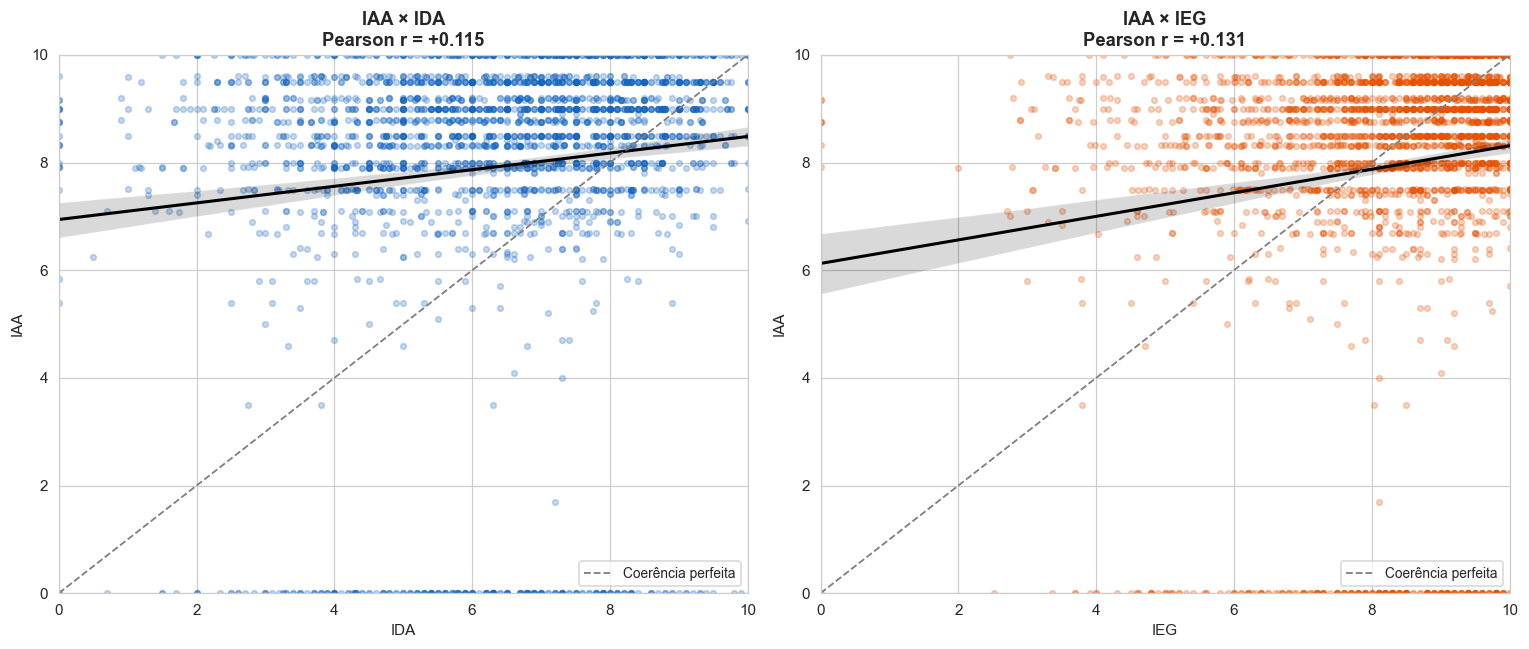

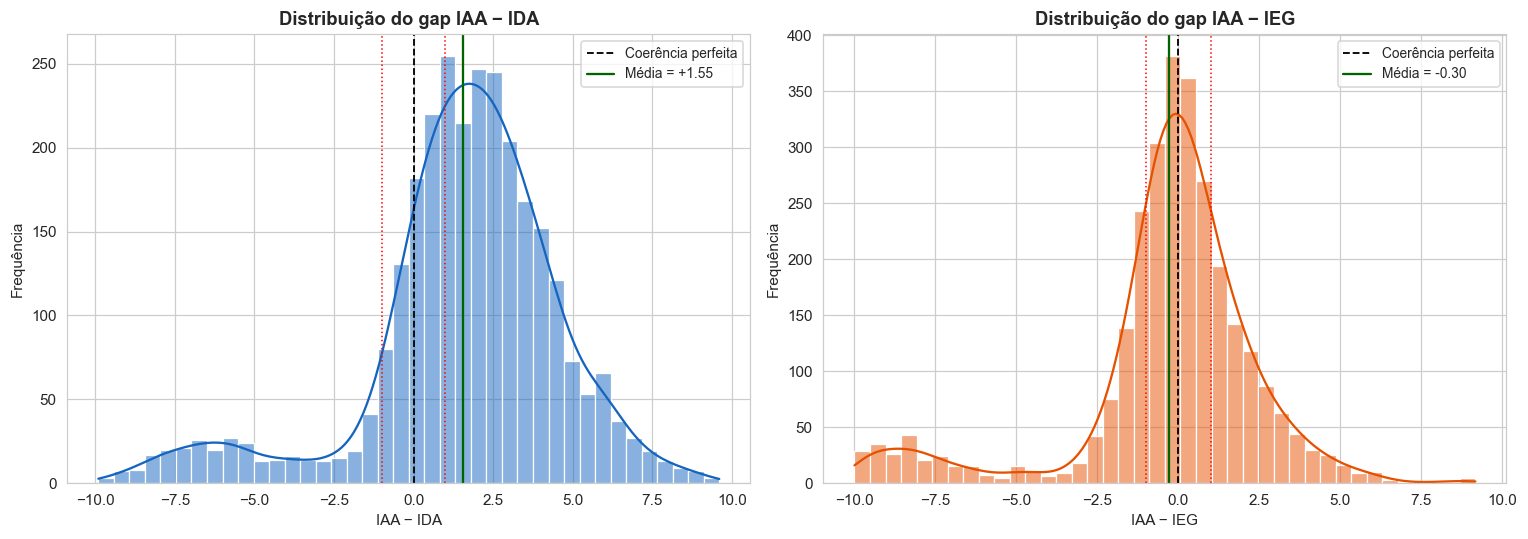

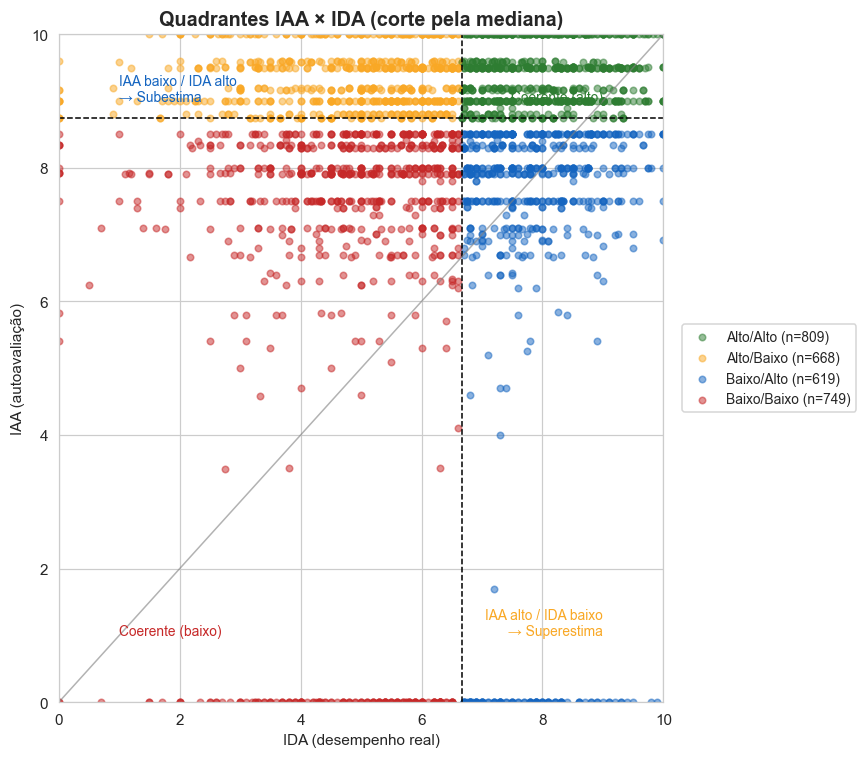

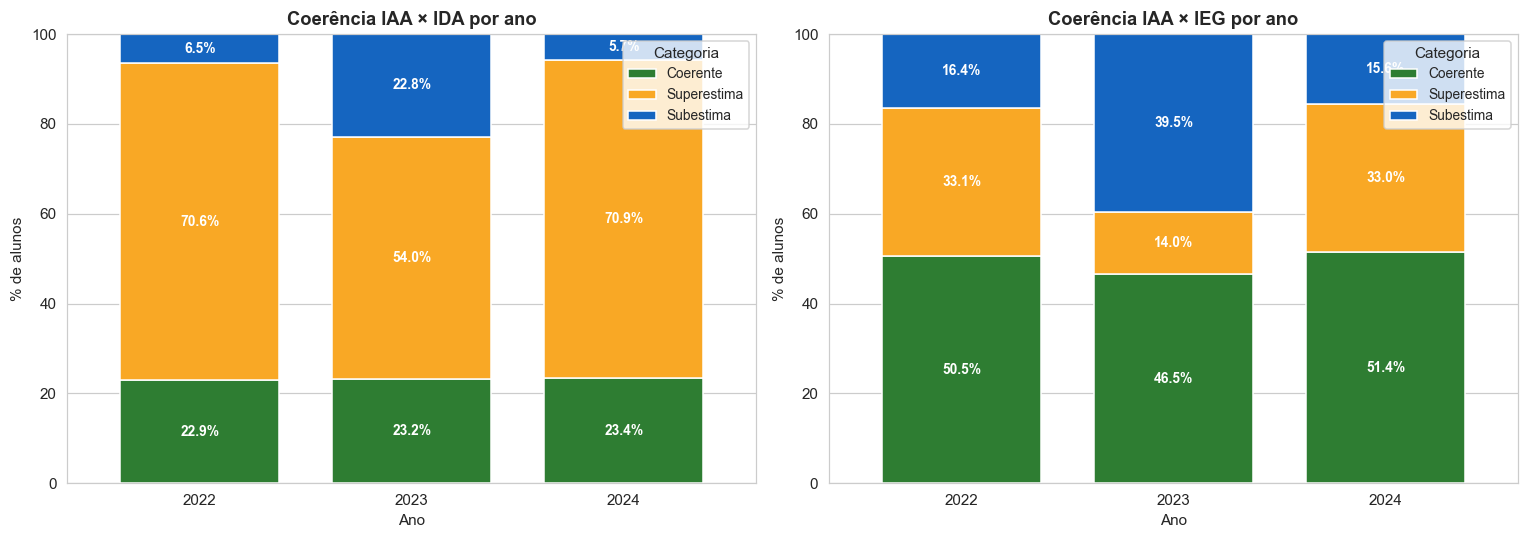

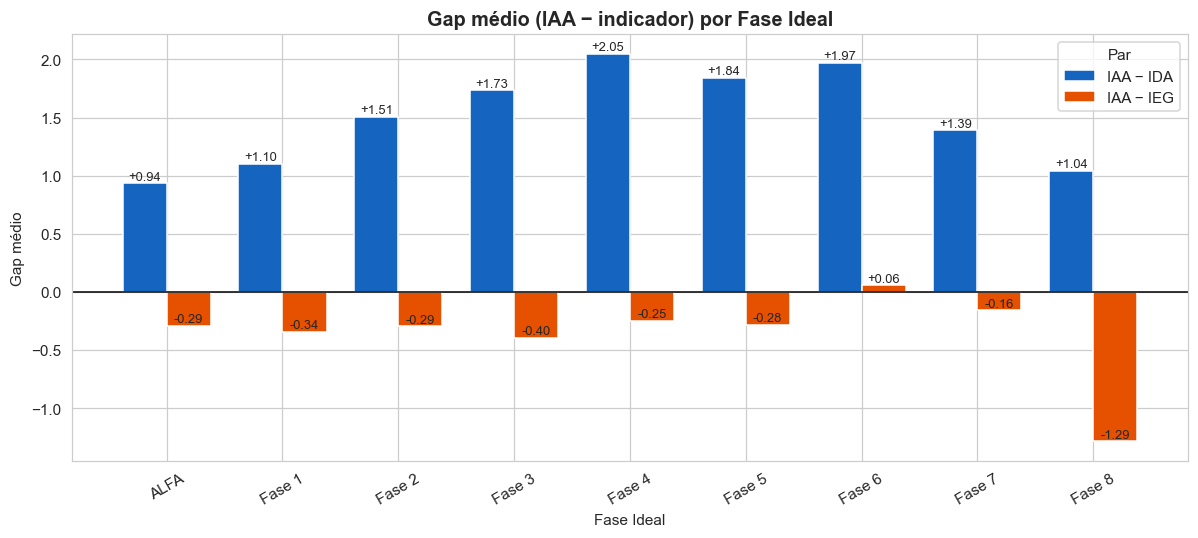


DIAGNÓSTICO — COERÊNCIA DA AUTOAVALIAÇÃO

▶ IAA × IDA: r = +0.115 → relação Fraca

▶ IAA × IEG: r = +0.131 → relação Fraca

▶ Gap médio IAA − IDA: +1.55
▶ Gap médio IAA − IEG: -0.30

▶ Coerência IAA × IDA:
   Coerente     :  23.2%
   Superestima  :  65.3%
   Subestima    :  11.5%

▶ Coerência IAA × IEG:
   Coerente     :  49.5%
   Superestima  :  26.8%
   Subestima    :  23.7%

VEREDITO
→ Alunos tendem a SUPERESTIMAR seu desempenho (IAA > IDA).


In [58]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
               'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

vars_alvo = ['IAA', 'IDA', 'IEG']
print(f"Base: {df.shape[0]} registros")


# ============================================================
# 1. COBERTURA E AMOSTRA ÚTIL
# ============================================================
cov = df[vars_alvo].notna().mean().mul(100).round(2)
print("=" * 70)
print("COBERTURA (%) — IAA, IDA, IEG")
print("=" * 70)
print(cov.to_string())

mask_ok = df[vars_alvo].notna().all(axis=1)
df_ok = df[mask_ok].copy()
print(f"\nRegistros com as 3 variáveis preenchidas: {len(df_ok)} "
      f"({len(df_ok)/len(df)*100:.1f}%)")


# ============================================================
# 2. CORRELAÇÃO — Pearson e Spearman (global)
# ============================================================
def par_corr(df_in, x, y, metodo='pearson'):
    sub = df_in[[x, y]].dropna()
    if len(sub) < 20:
        return None
    fn = stats.pearsonr if metodo == 'pearson' else stats.spearmanr
    r, p = fn(sub[x], sub[y])
    return {'n': len(sub), 'r': round(r, 3), 'p': round(p, 5)}

print("\n" + "=" * 70)
print("CORRELAÇÃO GLOBAL")
print("=" * 70)
for metodo in ['pearson', 'spearman']:
    print(f"\n▶ {metodo.capitalize()}:")
    for par in [('IAA', 'IDA'), ('IAA', 'IEG')]:
        d = par_corr(df_ok, par[0], par[1], metodo)
        print(f"  {par[0]} × {par[1]}: r = {d['r']:+.3f}   "
              f"p = {d['p']:.5f}   n = {d['n']}")


# ============================================================
# 3. CORRELAÇÃO POR ANO E POR FASE
# ============================================================
def corr_por(df_in, grupo):
    res = []
    for g, sub in df_in.groupby(grupo, observed=True):
        s1 = sub[['IAA', 'IDA']].dropna()
        s2 = sub[['IAA', 'IEG']].dropna()
        if len(s1) < 20 or len(s2) < 20:
            continue
        r1, p1 = stats.pearsonr(s1['IAA'], s1['IDA'])
        r2, p2 = stats.pearsonr(s2['IAA'], s2['IEG'])
        res.append({
            grupo: g, 'n': len(s1),
            'r_IAA_IDA': round(r1, 3), 'p_IAA_IDA': round(p1, 4),
            'r_IAA_IEG': round(r2, 3), 'p_IAA_IEG': round(p2, 4),
        })
    return pd.DataFrame(res).set_index(grupo)

corr_ano  = corr_por(df_ok, 'ano')
corr_fase = corr_por(df_ok, 'Fase_Ideal_1')

print("\n" + "=" * 70)
print("CORRELAÇÃO POR ANO — Pearson")
print("=" * 70)
print(corr_ano.to_string())

print("\n" + "=" * 70)
print("CORRELAÇÃO POR FASE — Pearson")
print("=" * 70)
print(corr_fase.to_string())


# ============================================================
# 4. GAP IAA − IDA E IAA − IEG
#    > 0 → aluno superestima a si mesmo (IAA acima do desempenho)
#    ≈ 0 → coerência
#    < 0 → aluno subestima
# ============================================================
df_ok['gap_IDA'] = (df_ok['IAA'] - df_ok['IDA']).round(2)
df_ok['gap_IEG'] = (df_ok['IAA'] - df_ok['IEG']).round(2)

gap_ano = df_ok.groupby('ano', observed=True)[['gap_IDA', 'gap_IEG']].agg(
    ['mean', 'median', 'std']
).round(2)

print("\n" + "=" * 70)
print("GAP MÉDIO (IAA − IDA e IAA − IEG) POR ANO")
print("=" * 70)
print(gap_ano.to_string())

gap_fase = df_ok.groupby('Fase_Ideal_1', observed=True)[['gap_IDA', 'gap_IEG']].agg(
    ['mean', 'median']
).round(2)
print("\n" + "=" * 70)
print("GAP MÉDIO POR FASE IDEAL")
print("=" * 70)
print(gap_fase.to_string())


# ============================================================
# 5. CLASSIFICAÇÃO EM QUADRANTES (coerência)
#    Para cada aluno, cruza IAA com IDA em faixas "alta/baixa"
#    usando a mediana como corte.
# ============================================================
def classificar_coerencia(df_in, x_col, y_col, tol=1.0):
    """
    Classifica cada aluno em:
      - Superestima:  IAA − y >  tol
      - Subestima:    IAA − y < −tol
      - Coerente:     |IAA − y| ≤ tol
    """
    gap = df_in[x_col] - df_in[y_col]
    return np.select(
        [gap >  tol, gap < -tol],
        ['Superestima', 'Subestima'],
        default='Coerente'
    )

TOL = 1.0  # tolerância de 1 ponto na escala 0–10

df_ok['coer_IDA'] = classificar_coerencia(df_ok, 'IAA', 'IDA', TOL)
df_ok['coer_IEG'] = classificar_coerencia(df_ok, 'IAA', 'IEG', TOL)

for col, ref in [('coer_IDA', 'IDA'), ('coer_IEG', 'IEG')]:
    tab = df_ok[col].value_counts().reindex(
        ['Coerente', 'Superestima', 'Subestima']
    )
    print(f"\n▶ Coerência IAA vs {ref} (tolerância = ±{TOL}):")
    for cat, n in tab.items():
        print(f"   {cat:<13}: {n:>4}  ({n/len(df_ok)*100:.1f}%)")


# ============================================================
# 6. QUADRANTES 2×2 — IAA × IDA e IAA × IEG
#    Corte pela mediana de cada eixo.
# ============================================================
def quadrantes(df_in, x, y):
    med_x, med_y = df_in[x].median(), df_in[y].median()
    return np.select(
        [(df_in[x] >= med_x) & (df_in[y] >= med_y),
         (df_in[x] >= med_x) & (df_in[y] <  med_y),
         (df_in[x] <  med_x) & (df_in[y] >= med_y),
         (df_in[x] <  med_x) & (df_in[y] <  med_y)],
        ['Alto/Alto', 'Alto/Baixo', 'Baixo/Alto', 'Baixo/Baixo'],
        default='?'
    )

df_ok['quad_IDA'] = quadrantes(df_ok, 'IAA', 'IDA')
df_ok['quad_IEG'] = quadrantes(df_ok, 'IAA', 'IEG')

for col, ref in [('quad_IDA', 'IDA'), ('quad_IEG', 'IEG')]:
    print(f"\n▶ Quadrantes IAA × {ref} (corte = mediana):")
    print(df_ok[col].value_counts().reindex(
        ['Alto/Alto', 'Alto/Baixo', 'Baixo/Alto', 'Baixo/Baixo']
    ).to_string())


# ============================================================
# 7. REGRESSÃO MÚLTIPLA — IAA ~ IDA + IEG
#    Mede se IDA e IEG, juntos, explicam a autoavaliação
# ============================================================
sub = df_ok[['IAA', 'IDA', 'IEG']].dropna()
X = sm.add_constant(sub[['IDA', 'IEG']])
modelo = sm.OLS(sub['IAA'], X).fit()

print("\n" + "=" * 70)
print("REGRESSÃO MÚLTIPLA — IAA ~ IDA + IEG")
print("=" * 70)
print(modelo.summary().tables[1])
print(f"\nR² = {modelo.rsquared:.4f}   "
      f"R² ajustado = {modelo.rsquared_adj:.4f}   n = {int(modelo.nobs)}")


# ============================================================
# 8. VISUALIZAÇÃO 1 — Dispersão IAA × IDA e IAA × IEG
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ref, cor in zip(axes, ['IDA', 'IEG'], ['#1565C0', '#E65100']):
    sns.regplot(data=df_ok, x=ref, y='IAA', ax=ax,
                scatter_kws={'alpha': 0.25, 's': 14, 'color': cor},
                line_kws={'color': 'black', 'linewidth': 2})
    r, _ = stats.pearsonr(df_ok[ref], df_ok['IAA'])
    # Linha de identidade (IAA == ref)
    ax.plot([0, 10], [0, 10], '--', color='gray',
            linewidth=1.2, label='Coerência perfeita')
    ax.set_title(f'IAA × {ref}\nPearson r = {r:+.3f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(ref)
    ax.set_ylabel('IAA')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 2 — Histograma dos gaps
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, ref, cor in zip(axes,
                             ['gap_IDA', 'gap_IEG'],
                             ['IDA', 'IEG'],
                             ['#1565C0', '#E65100']):
    sns.histplot(df_ok[col].dropna(), bins=40, kde=True,
                 color=cor, ax=ax)
    ax.axvline(0, color='black', linewidth=1.2, linestyle='--',
               label='Coerência perfeita')
    ax.axvline(TOL, color='red', linewidth=1, linestyle=':')
    ax.axvline(-TOL, color='red', linewidth=1, linestyle=':')
    media = df_ok[col].mean()
    ax.axvline(media, color='darkgreen', linewidth=1.5,
               label=f'Média = {media:+.2f}')
    ax.set_title(f'Distribuição do gap IAA − {ref}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'IAA − {ref}')
    ax.set_ylabel('Frequência')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 10. VISUALIZAÇÃO 3 — Quadrantes IAA × IDA
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

med_iaa = df_ok['IAA'].median()
med_ida = df_ok['IDA'].median()

cor_quad = {
    'Alto/Alto':   '#2E7D32',
    'Alto/Baixo':  '#F9A825',
    'Baixo/Alto':  '#1565C0',
    'Baixo/Baixo': '#C62828',
}

for q, cor in cor_quad.items():
    sub = df_ok[df_ok['quad_IDA'] == q]
    ax.scatter(sub['IDA'], sub['IAA'], alpha=0.5, s=18,
               color=cor, label=f'{q} (n={len(sub)})')

ax.axvline(med_ida, color='black', linewidth=1, linestyle='--')
ax.axhline(med_iaa, color='black', linewidth=1, linestyle='--')
ax.plot([0, 10], [0, 10], color='gray', linewidth=1, alpha=0.6)

ax.text(9, 1, 'IAA alto / IDA baixo\n→ Superestima',
        fontsize=9, color='#F9A825', ha='right')
ax.text(1, 9, 'IAA baixo / IDA alto\n→ Subestima',
        fontsize=9, color='#1565C0')
ax.text(9, 9, 'Coerente (alto)', fontsize=9, color='#2E7D32',
        ha='right')
ax.text(1, 1, 'Coerente (baixo)', fontsize=9, color='#C62828')

ax.set_title('Quadrantes IAA × IDA (corte pela mediana)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IDA (desempenho real)')
ax.set_ylabel('IAA (autoavaliação)')
ax.set_xlim(0, 10); ax.set_ylim(0, 10)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 11. VISUALIZAÇÃO 4 — % de cada categoria de coerência por ano
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, ref in zip(axes,
                        ['coer_IDA', 'coer_IEG'],
                        ['IDA', 'IEG']):
    tab = pd.crosstab(df_ok['ano'], df_ok[col], normalize='index') * 100
    tab = tab.reindex(columns=['Coerente', 'Superestima', 'Subestima'],
                      fill_value=0).round(1)
    tab.plot(kind='bar', stacked=True, ax=ax,
             color={'Coerente': '#2E7D32',
                    'Superestima': '#F9A825',
                    'Subestima': '#1565C0'},
             edgecolor='white', width=0.75)
    ax.set_title(f'Coerência IAA × {ref} por ano', fontsize=12, fontweight='bold')
    ax.set_xlabel('Ano')
    ax.set_ylabel('% de alunos')
    ax.set_ylim(0, 100)
    ax.legend(title='Categoria', loc='upper right', fontsize=9)
    ax.tick_params(axis='x', rotation=0)

    # Anotação
    for i, ano in enumerate(tab.index):
        y = 0
        for cat in tab.columns:
            v = tab.loc[ano, cat]
            if v > 5:
                ax.text(i, y + v/2, f'{v:.1f}%', ha='center',
                        va='center', color='white', fontsize=9,
                        fontweight='bold')
            y += v

plt.tight_layout()
plt.show()


# ============================================================
# 12. VISUALIZAÇÃO 5 — Gap médio por fase
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5))
gap_plot = df_ok.groupby('Fase_Ideal_1', observed=True)[
    ['gap_IDA', 'gap_IEG']
].mean()

x = np.arange(len(gap_plot))
w = 0.38
ax.bar(x - w/2, gap_plot['gap_IDA'], width=w,
       color='#1565C0', edgecolor='white', label='IAA − IDA')
ax.bar(x + w/2, gap_plot['gap_IEG'], width=w,
       color='#E65100', edgecolor='white', label='IAA − IEG')

for i in range(len(gap_plot)):
    ax.text(i - w/2, gap_plot['gap_IDA'].iloc[i] + 0.03,
            f"{gap_plot['gap_IDA'].iloc[i]:+.2f}",
            ha='center', fontsize=8.5)
    ax.text(i + w/2, gap_plot['gap_IEG'].iloc[i] + 0.03,
            f"{gap_plot['gap_IEG'].iloc[i]:+.2f}",
            ha='center', fontsize=8.5)

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(gap_plot.index.astype(str), rotation=30)
ax.set_title('Gap médio (IAA − indicador) por Fase Ideal',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Fase Ideal')
ax.set_ylabel('Gap médio')
ax.legend(title='Par')
plt.tight_layout()
plt.show()


# ============================================================
# 13. DIAGNÓSTICO AUTOMÁTICO
# ============================================================
def classificar_r(r):
    ar = abs(r)
    if ar < 0.20: return 'Fraca'
    if ar < 0.40: return 'Fraca-moderada'
    if ar < 0.60: return 'Moderada'
    if ar < 0.80: return 'Forte'
    return 'Muito forte'

print("\n" + "=" * 70)
print("DIAGNÓSTICO — COERÊNCIA DA AUTOAVALIAÇÃO")
print("=" * 70)

for par in [('IAA', 'IDA'), ('IAA', 'IEG')]:
    d = par_corr(df_ok, par[0], par[1])
    print(f"\n▶ {par[0]} × {par[1]}: r = {d['r']:+.3f} "
          f"→ relação {classificar_r(d['r'])}")

# Gap médio global
gap_ida_medio = df_ok['gap_IDA'].mean()
gap_ieg_medio = df_ok['gap_IEG'].mean()
print(f"\n▶ Gap médio IAA − IDA: {gap_ida_medio:+.2f}")
print(f"▶ Gap médio IAA − IEG: {gap_ieg_medio:+.2f}")

# Distribuição das categorias
for col, ref in [('coer_IDA', 'IDA'), ('coer_IEG', 'IEG')]:
    tab = df_ok[col].value_counts(normalize=True).reindex(
        ['Coerente', 'Superestima', 'Subestima']
    ) * 100
    print(f"\n▶ Coerência IAA × {ref}:")
    for cat, v in tab.items():
        print(f"   {cat:<13}: {v:>5.1f}%")

print("\n" + "=" * 70)
print("VEREDITO")
print("=" * 70)

if gap_ida_medio > 0.3:
    print("→ Alunos tendem a SUPERESTIMAR seu desempenho (IAA > IDA).")
elif gap_ida_medio < -0.3:
    print("→ Alunos tendem a SUBESTIMAR seu desempenho (IAA < IDA).")
else:
    print("→ Autoavaliação está, em média, alinhada ao desempenho real.")

In [59]:
# Anomalia nos dados do IAA de 2023
df.groupby('ano')[['IAA', 'IDA', 'IEG']].mean().round(2)

,IAA,IDA,IEG
ano,,,
2022,8.27,6.09,7.89
2023,6.91,6.67,8.70
2024,8.54,6.35,8.09


# 5. Aspectos psicossociais (IPS)
Há padrões psicossociais (IPS) que antecedem quedas de desempenho 
acadêmico ou de engajamento?

Sim, mas de forma fraca. O IPS do ano anterior tem uma relação positiva com o desempenho (IDA) e o engajamento (IEG) do ano seguinte — mas essa relação é fraca o suficiente para não servir como "alarme" confiável sozinha. O sinal existe, é consistente, mas é pequeno.

Pontos positivos

Há um sinal temporal real. O IPS do ano passado tem valor preditivo para o ano seguinte. Não é coincidência — o efeito é estatisticamente significativo (p < 0,0001).

O timing é ideal para intervenção. Como o IPS aparece 1 ano antes da queda, o programa tem tempo de agir. Isso é ouro em políticas educacionais: dá para usar o IPS como triagem precoce.

O IPS é complementar aos outros indicadores. Ele não substitui IDA nem IEG — ele acrescenta informação que os outros não capturam.

O IPS do ano anterior tem relação positiva fraca com o desempenho (IDA) e o engajamento (IEG) do ano seguinte — as correlações ficam entre 0,14 e 0,19, o que significa que o IPS explica cerca de 3% da variação dos indicadores seguintes. O efeito é estatisticamente significativo e temporalmente coerente (o melhor prazo é 1 ano, não o mesmo ano nem 2 anos depois), mas não é forte o suficiente para prever quedas individualmente. O IPS deve ser usado como indicador complementar de triagem, combinado com IDA e IEG prévios, e não como preditor único.

Base: 2845 registros
RAs únicos: 1586

▶ RAs em 1 ano : 761
▶ RAs em 2 anos: 391
▶ RAs em 3 anos: 434

Pivot IPS — shape: (1586, 3)  (RAs × anos: [np.int64(2022), np.int64(2023), np.int64(2024)])

ANÁLISE GERAL — TODOS OS RAs

--- Detalhamento por transição ---

▶ LAG 0
   2022→2022    IPS × IDA: r = +0.132  p = 0.0001  n = 860
   2023→2023    IPS × IDA: r = +0.132  p = 0.0001  n = 931
   2024→2024    IPS × IDA: r = +0.014  p = 0.6384  n = 1054
   2022→2022    IPS × IEG: r = +0.093  p = 0.0062  n = 860
   2023→2023    IPS × IEG: r = +0.043  p = 0.1907  n = 931
   2024→2024    IPS × IEG: r = +0.061  p = 0.0490  n = 1054

▶ LAG 1
   2022→2023    IPS × IDA: r = +0.246  p = 0.0000  n = 570
   2023→2024    IPS × IDA: r = +0.140  p = 0.0002  n = 678
   2022→2023    IPS × IEG: r = +0.101  p = 0.0161  n = 570
   2023→2024    IPS × IEG: r = +0.062  p = 0.1045  n = 678

▶ LAG 2
   2022→2024    IPS × IDA: r = +0.098  p = 0.0388  n = 445
   2022→2024    IPS × IEG: r = +0.105  p = 0.0271  n = 445



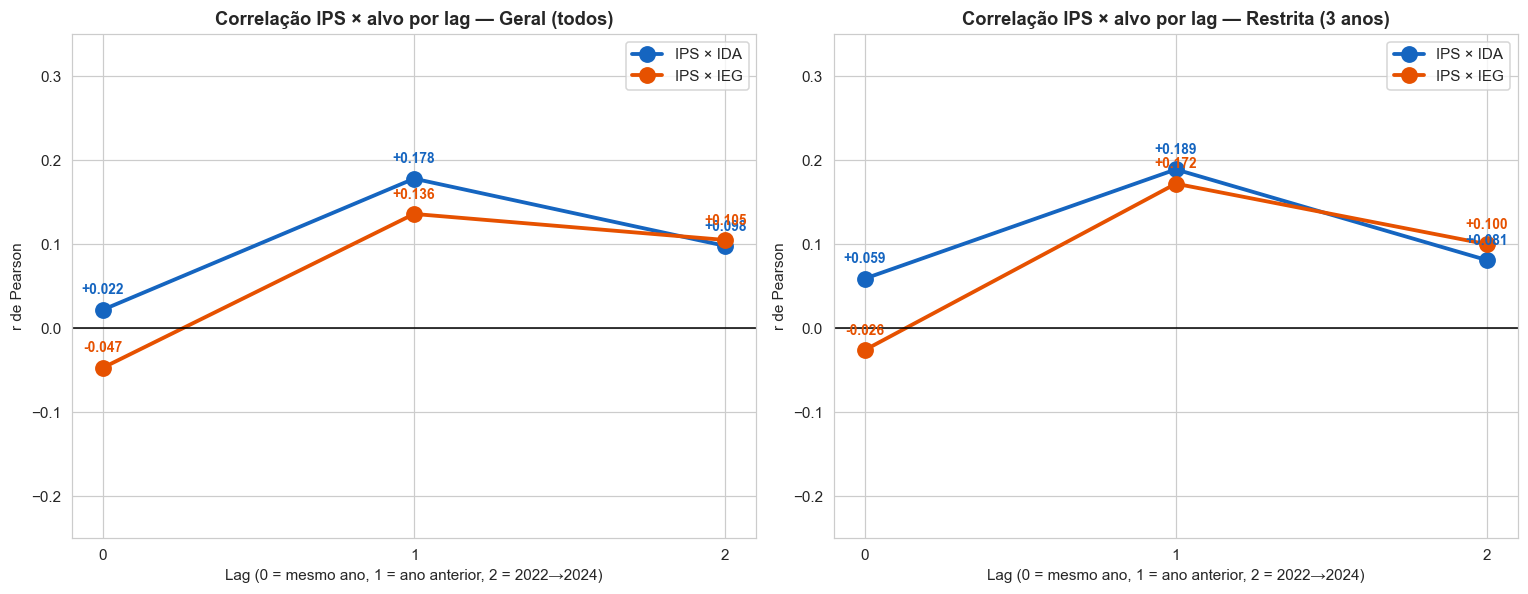

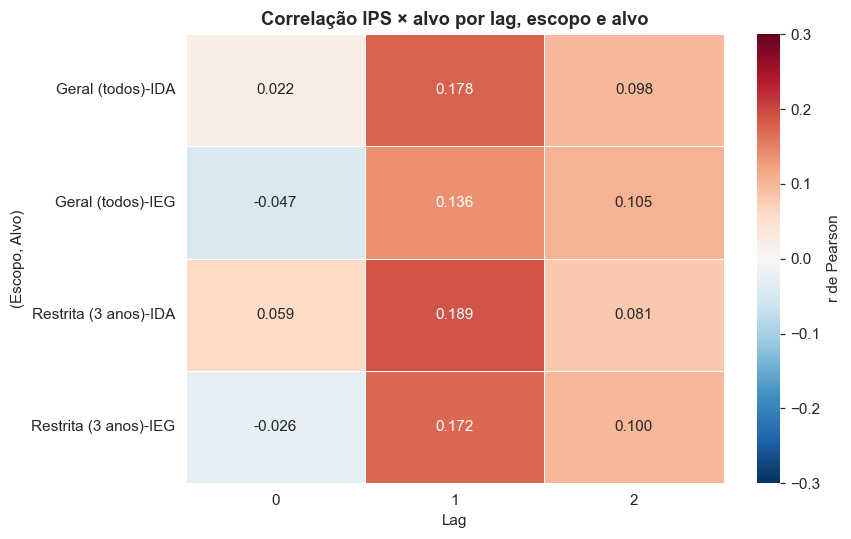

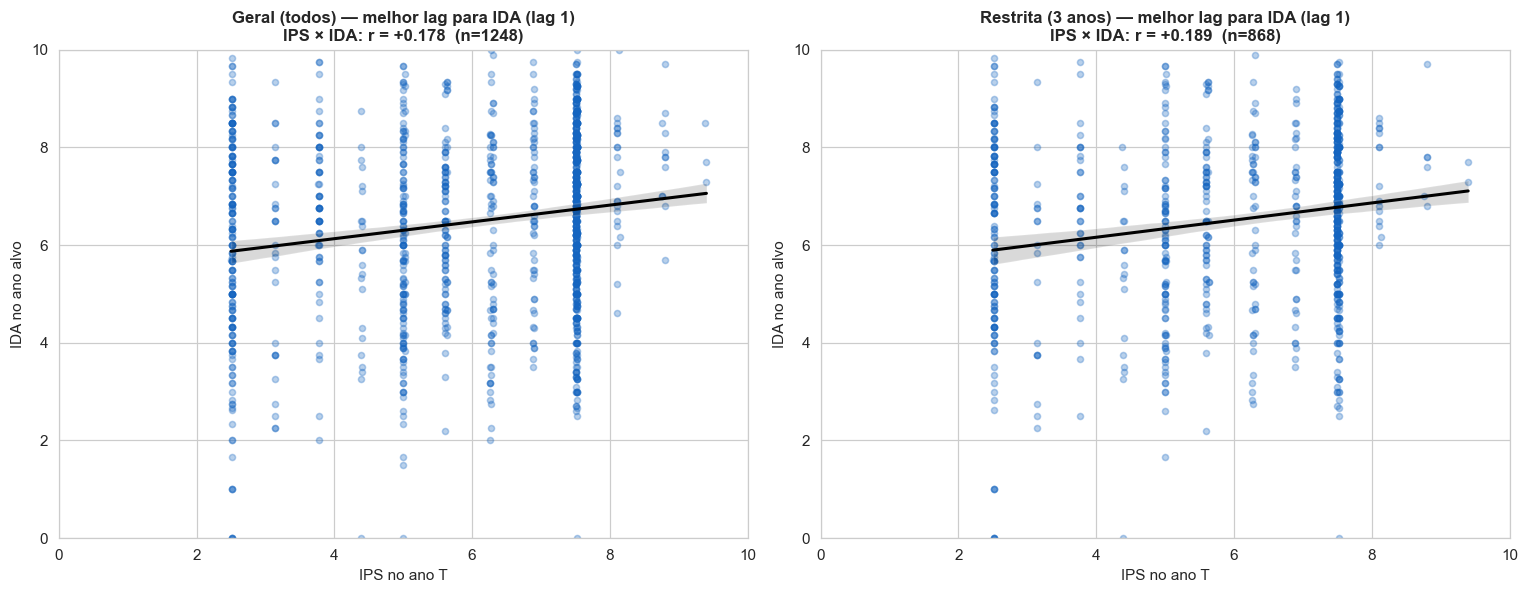


DIAGNÓSTICO — QUAL DESLOCAMENTO TEMPORAL É MAIS RELEVANTE?

▶ Geral (todos):
   IPS × IDA: melhor lag = 1  (r = +0.178, p = 0.0000, n = 1248)
   IPS × IEG: melhor lag = 1  (r = +0.136, p = 0.0000, n = 1248)

▶ Restrita (3 anos):
   IPS × IDA: melhor lag = 1  (r = +0.189, p = 0.0000, n = 868)
   IPS × IEG: melhor lag = 1  (r = +0.172, p = 0.0000, n = 868)

▶ Maior |r| de toda a análise: Restrita (3 anos) | IPS × IDA | lag 1 → r = +0.189

▶ Classificação das correlações mais fortes:
   Geral (todos)        | IPS × IDA | lag 1 → r = +0.178  (Fraca)
   Geral (todos)        | IPS × IEG | lag 1 → r = +0.136  (Fraca)
   Restrita (3 anos)    | IPS × IDA | lag 1 → r = +0.189  (Fraca)
   Restrita (3 anos)    | IPS × IEG | lag 1 → r = +0.172  (Fraca)


In [60]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

print(f"Base: {df.shape[0]} registros")
print(f"RAs únicos: {df['RA'].nunique()}")

# Identifica RAs presentes nos 3 anos
anos_por_ra = df.groupby('RA')['ano'].nunique()
ras_3anos = anos_por_ra[anos_por_ra == 3].index
ras_1ano  = anos_por_ra[anos_por_ra == 1].index
ras_2anos = anos_por_ra[anos_por_ra == 2].index

print(f"\n▶ RAs em 1 ano : {len(ras_1ano)}")
print(f"▶ RAs em 2 anos: {len(ras_2anos)}")
print(f"▶ RAs em 3 anos: {len(ras_3anos)}")


# ============================================================
# 1. PIVOTS RA × ANO
# ============================================================
def pivot_wide(col):
    return df.pivot_table(index='RA', columns='ano',
                          values=col, aggfunc='last')

piv_ips = pivot_wide('IPS')
piv_ida = pivot_wide('IDA')
piv_ieg = pivot_wide('IEG')

print(f"\nPivot IPS — shape: {piv_ips.shape}  "
      f"(RAs × anos: {list(piv_ips.columns)})")


# ============================================================
# 2. FUNÇÃO QUE MONTA A BASE LONGITUDINAL PARA UM LAG
# ============================================================
def montar_base_lag(piv_ips, piv_alvo, lag, ras_filtro=None):
    """
    lag=0 → IPS_T e alvo_T no mesmo ano
    lag=1 → IPS_{T-1} e alvo_T (transições 2022→2023 e 2023→2024)
    lag=2 → IPS_2022 e alvo_2024 (salto de 2 anos)
    ras_filtro: lista/Index de RAs a manter (opcional)
    """
    if lag == 0:
        pares = [(y, y) for y in [2022, 2023, 2024]]
    elif lag == 1:
        pares = [(2022, 2023), (2023, 2024)]
    elif lag == 2:
        pares = [(2022, 2024)]
    else:
        raise ValueError("lag deve ser 0, 1 ou 2")

    blocos = []
    for t_ips, t_alvo in pares:
        if t_ips not in piv_ips.columns or t_alvo not in piv_alvo.columns:
            continue
        bloco = pd.DataFrame({
            'IPS_T':   piv_ips[t_ips],
            'ALVO_T':  piv_alvo[t_alvo],
        }).dropna()
        bloco = bloco.reset_index()
        bloco['lag']       = lag
        bloco['t_ips']     = t_ips
        bloco['t_alvo']    = t_alvo
        bloco['transicao'] = f'{t_ips}→{t_alvo}'
        blocos.append(bloco)

    base = pd.concat(blocos, ignore_index=True)

    if ras_filtro is not None:
        base = base[base['RA'].isin(ras_filtro)].copy()

    return base


# ============================================================
# 3. FUNÇÃO QUE CALCULA AS CORRELAÇÕES PARA UM LAG
# ============================================================
def correlacao_lag(base, nome_alvo):
    """Retorna r de Pearson, Spearman, p-valor e n para IPS × alvo."""
    sub = base[['IPS_T', 'ALVO_T']].dropna()
    if len(sub) < 20:
        return None
    r_p, p_p = stats.pearsonr(sub['IPS_T'], sub['ALVO_T'])
    r_s, p_s = stats.spearmanr(sub['IPS_T'], sub['ALVO_T'])
    return {
        'alvo': nome_alvo, 'n': len(sub),
        'r_pearson': round(r_p, 3),
        'p_pearson': round(p_p, 5),
        'r_spearman': round(r_s, 3),
        'p_spearman': round(p_s, 5),
    }


# ============================================================
# 4. ANÁLISE GERAL (TODOS OS RAs) — por lag
# ============================================================
print("\n" + "=" * 72)
print("ANÁLISE GERAL — TODOS OS RAs")
print("=" * 72)

resultados_geral = []

for lag in [0, 1, 2]:
    base_ida = montar_base_lag(piv_ips, piv_ida, lag)
    base_ieg = montar_base_lag(piv_ips, piv_ieg, lag)

    r_ida = correlacao_lag(base_ida, 'IDA')
    r_ieg = correlacao_lag(base_ieg, 'IEG')

    if r_ida:
        r_ida['lag'] = lag
        resultados_geral.append(r_ida)
    if r_ieg:
        r_ieg['lag'] = lag
        resultados_geral.append(r_ieg)

# Detalhamento por transição dentro de cada lag
print("\n--- Detalhamento por transição ---")
for lag in [0, 1, 2]:
    print(f"\n▶ LAG {lag}")
    for nome, piv in [('IDA', piv_ida), ('IEG', piv_ieg)]:
        base = montar_base_lag(piv_ips, piv, lag)
        for tr, sub in base.groupby('transicao'):
            sub2 = sub[['IPS_T', 'ALVO_T']].dropna()
            if len(sub2) < 20:
                continue
            r, p = stats.pearsonr(sub2['IPS_T'], sub2['ALVO_T'])
            print(f"   {tr:<12} IPS × {nome}: r = {r:+.3f}  p = {p:.4f}  n = {len(sub2)}")

# Tabela-resumo geral
tab_geral = pd.DataFrame(resultados_geral).sort_values(['lag', 'alvo'])
print("\n" + "=" * 72)
print("RESUMO GERAL — IPS × ALVO POR LAG (todos os RAs)")
print("=" * 72)
print(tab_geral.to_string(index=False))


# ============================================================
# 5. ANÁLISE RESTRITA — RAs PRESENTES NOS 3 ANOS
# ============================================================
print("\n" + "=" * 72)
print("ANÁLISE RESTRITA — RAs PRESENTES EM 2022, 2023 E 2024")
print(f"(n = {len(ras_3anos)} alunos)")
print("=" * 72)

resultados_3anos = []

for lag in [0, 1, 2]:
    base_ida = montar_base_lag(piv_ips, piv_ida, lag, ras_filtro=ras_3anos)
    base_ieg = montar_base_lag(piv_ips, piv_ieg, lag, ras_filtro=ras_3anos)

    r_ida = correlacao_lag(base_ida, 'IDA')
    r_ieg = correlacao_lag(base_ieg, 'IEG')

    if r_ida:
        r_ida['lag'] = lag
        resultados_3anos.append(r_ida)
    if r_ieg:
        r_ieg['lag'] = lag
        resultados_3anos.append(r_ieg)

# Detalhamento por transição
print("\n--- Detalhamento por transição (3 anos) ---")
for lag in [0, 1, 2]:
    print(f"\n▶ LAG {lag}")
    for nome, piv in [('IDA', piv_ida), ('IEG', piv_ieg)]:
        base = montar_base_lag(piv_ips, piv, lag, ras_filtro=ras_3anos)
        for tr, sub in base.groupby('transicao'):
            sub2 = sub[['IPS_T', 'ALVO_T']].dropna()
            if len(sub2) < 20:
                continue
            r, p = stats.pearsonr(sub2['IPS_T'], sub2['ALVO_T'])
            print(f"   {tr:<12} IPS × {nome}: r = {r:+.3f}  p = {p:.4f}  n = {len(sub2)}")

tab_3anos = pd.DataFrame(resultados_3anos).sort_values(['lag', 'alvo'])
print("\n" + "=" * 72)
print("RESUMO — RAs DE 3 ANOS (IPS × ALVO POR LAG)")
print("=" * 72)
print(tab_3anos.to_string(index=False))


# ============================================================
# 6. COMPARATIVO — QUAL LAG TEM A CORRELAÇÃO MAIS FORTE?
# ============================================================
def enriquecer(tab, escopo):
    tab = tab.copy()
    tab['escopo'] = escopo
    tab['abs_r'] = tab['r_pearson'].abs()
    return tab

comp = pd.concat([
    enriquecer(tab_geral, 'Geral (todos)'),
    enriquecer(tab_3anos, 'Restrita (3 anos)'),
], ignore_index=True)

print("\n" + "=" * 72)
print("COMPARATIVO FINAL — FORÇA DA CORRELAÇÃO POR LAG E ALVO")
print("=" * 72)
comp_sorted = comp.sort_values(['escopo', 'alvo', 'abs_r'],
                               ascending=[True, True, False])
print(comp_sorted[['escopo', 'alvo', 'lag', 'n',
                   'r_pearson', 'p_pearson',
                   'r_spearman', 'p_spearman']].to_string(index=False))

# Melhor lag por alvo × escopo
print("\n" + "=" * 72)
print("▶ LAG MAIS RELEVANTE (maior |r| de Pearson) POR ALVO E ESCOPO")
print("=" * 72)
melhores = (
    comp.loc[comp.groupby(['escopo', 'alvo'])['abs_r'].idxmax()]
        [['escopo', 'alvo', 'lag', 'r_pearson', 'p_pearson', 'n']]
        .sort_values(['escopo', 'alvo'])
)
print(melhores.to_string(index=False))


# ============================================================
# 7. VISUALIZAÇÃO 1 — Barras de |r| por lag, por escopo
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, escopo in zip(axes, ['Geral (todos)', 'Restrita (3 anos)']):
    sub = comp[comp['escopo'] == escopo]

    for alvo, cor in [('IDA', '#1565C0'), ('IEG', '#E65100')]:
        sub_alvo = sub[sub['alvo'] == alvo].sort_values('lag')
        x = sub_alvo['lag'].astype(str)
        y = sub_alvo['r_pearson']
        ax.plot(x, y, marker='o', linewidth=2.5, markersize=10,
                color=cor, label=f'IPS × {alvo}')
        for xi, yi in zip(x, y):
            ax.annotate(f"{yi:+.3f}", (xi, yi),
                        textcoords="offset points", xytext=(0, 10),
                        ha='center', fontsize=9, color=cor, fontweight='bold')

    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Correlação IPS × alvo por lag — {escopo}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Lag (0 = mesmo ano, 1 = ano anterior, 2 = 2022→2024)')
    ax.set_ylabel('r de Pearson')
    ax.legend()
    ax.set_ylim(-0.25, 0.35)

plt.tight_layout()
plt.show()


# ============================================================
# 8. VISUALIZAÇÃO 2 — Heatmap: escopo × lag × alvo
# ============================================================
pivot_heat = comp.pivot_table(
    index=['escopo', 'alvo'],
    columns='lag',
    values='r_pearson'
).round(3)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot_heat, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-0.3, vmax=0.3,
            linewidths=0.6, cbar_kws={'label': 'r de Pearson'}, ax=ax)
ax.set_title('Correlação IPS × alvo por lag, escopo e alvo',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Lag')
ax.set_ylabel('(Escopo, Alvo)')
plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 3 — Dispersão do melhor lag (por escopo)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, escopo, filtro in zip(
        axes,
        ['Geral (todos)', 'Restrita (3 anos)'],
        [None, ras_3anos]):

    # Melhor lag para IDA nesse escopo
    melhor_lag = melhores[
        (melhores['escopo'] == escopo) & (melhores['alvo'] == 'IDA')
    ]['lag'].iloc[0]

    base = montar_base_lag(piv_ips, piv_ida, melhor_lag, ras_filtro=filtro)
    sub = base[['IPS_T', 'ALVO_T']].dropna()

    sns.regplot(x=sub['IPS_T'], y=sub['ALVO_T'], ax=ax,
                scatter_kws={'alpha': 0.3, 's': 16, 'color': '#1565C0'},
                line_kws={'color': 'black', 'linewidth': 2})
    r, _ = stats.pearsonr(sub['IPS_T'], sub['ALVO_T'])
    ax.set_title(f'{escopo} — melhor lag para IDA (lag {melhor_lag})\n'
                 f'IPS × IDA: r = {r:+.3f}  (n={len(sub)})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('IPS no ano T')
    ax.set_ylabel('IDA no ano alvo')
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)

plt.tight_layout()
plt.show()


# ============================================================
# 10. DIAGNÓSTICO FINAL
# ============================================================
print("\n" + "=" * 72)
print("DIAGNÓSTICO — QUAL DESLOCAMENTO TEMPORAL É MAIS RELEVANTE?")
print("=" * 72)

for escopo in ['Geral (todos)', 'Restrita (3 anos)']:
    sub = comp[comp['escopo'] == escopo]
    print(f"\n▶ {escopo}:")

    for alvo in ['IDA', 'IEG']:
        sub_alvo = sub[sub['alvo'] == alvo].sort_values('abs_r', ascending=False)
        if sub_alvo.empty:
            continue
        best = sub_alvo.iloc[0]
        print(f"   IPS × {alvo}: melhor lag = {int(best['lag'])}  "
              f"(r = {best['r_pearson']:+.3f}, p = {best['p_pearson']:.4f}, "
              f"n = {int(best['n'])})")

# Identifica lag mais relevante globalmente
best_overall = comp.loc[comp['abs_r'].idxmax()]
print(f"\n▶ Maior |r| de toda a análise: "
      f"{best_overall['escopo']} | IPS × {best_overall['alvo']} | "
      f"lag {int(best_overall['lag'])} → "
      f"r = {best_overall['r_pearson']:+.3f}")

# Interpretação da força
def classificar(r):
    a = abs(r)
    if a < 0.10: return 'Muito fraca / inexistente'
    if a < 0.20: return 'Fraca'
    if a < 0.35: return 'Moderada'
    if a < 0.50: return 'Forte'
    return 'Muito forte'

print("\n▶ Classificação das correlações mais fortes:")
for _, row in melhores.iterrows():
    print(f"   {row['escopo']:<20} | IPS × {row['alvo']} | "
          f"lag {int(row['lag'])} → r = {row['r_pearson']:+.3f}  "
          f"({classificar(row['r_pearson'])})")

# 6. Aspectos psicopedagógicos (IPP)
As avaliações psicopedagógicas (IPP) confirmam ou contradizem a 
defasagem identificada pelo IAN?

O IPP confirma o IAN. As três evidências (médias, correlação e distribuição por quartis) apontam na mesma direção: alunos mais defasados têm IPP mais baixo. A confirmação é consistente, mas de intensidade moderada — os pedagogos percebem a defasagem, só que com menos intensidade do que o IAN a sinaliza.


a) Correlação positiva e significativa
Métrica	    Valor	Interpretação
Pearson	    +0,177	Positiva, fraca-moderada
Spearman	+0,187	Consistente com Pearson
n	        2.845	Amostra robusta

Estabilidade por ano:
2022: +0,105
2023: +0,094
2024: +0,154

A direção se mantém nos três anos — não é artefato de um ano isolado.


b) Teste estatístico confirma diferença entre grupos
Kruskal-Wallis: H = 99,57, p < 0,0001 → as três categorias não têm o mesmo IPP.
Mann-Whitney pareado:
- Em fase vs Moderada → significativo
- Em fase vs Severa → significativo
- Moderada vs Severa → não significativo (p = 0,30)


c) Distribuição por quartis reforça o gradiente
Categoria IAN	    % no Q1 (pior IPP)	% no Q4 (melhor IPP)
Em fase	            17,8%	            31,9%
Defasagem moderada	30,0%	            19,0%
Defasagem severa	29,5%	            9,1%

Alunos "Em fase" concentram-se no quartil de melhor IPP; alunos "Severamente defasados" praticamente desaparecem do Q4 (só 9,1%). 


4. Ressalvas que valorizam a análise
Categoria "severa" tem só 44 alunos. Isso enfraquece os testes que envolvem essa categoria. O achado forte é a diferença entre "em fase" e as duas categorias defasadas, não a diferença entre moderada e severa.

A magnitude é modesta. Δ = 0,68 ponto em escala de 10. Não é uma confirmação dramática — os pedagogos concordam com a direção do IAN, mas com menor intensidade. O IPP captura dimensões (cognitivas, emocionais, comportamentais) que vão além da defasagem de nível.

Correlação de 0,18 explica ~3% da variância. Isso significa: IAN e IPP não são redundantes. Confirmar não é o mesmo que duplicar — os dois indicadores convergem na direção, mas medem coisas complementares.

Consistência temporal é o argumento mais forte. O r fica entre 0,09 e 0,15 nos três anos. A constância entre anos independentes é o que sustenta a conclusão — mais do que a magnitude isolada de um único ano.


5. O IPP confirma a direção do IAN, mas não o substitui: os dois indicadores caminham juntos (r ≈ 0,18, p < 0,0001) e mostram gradiente consistente entre alunos em fase, moderadamente defasados e severamente defasados. A confirmação é moderada em intensidade e estável nos três anos analisados, indicando que a avaliação psicopedagógica captura a defasagem identificada pelo IAN, mas agrega informação adicional — o que justifica manter ambos os indicadores no acompanhamento dos alunos.

Base: 2845 registros
IPP nulos: 0
IPP POR CATEGORIA DE IAN (com Total)
                       n  media  mediana  desvio   p25   p75
Em fase             1166   7.42     7.50    1.10  6.88  8.12
Defasagem moderada  1635   7.01     7.19    1.16  6.17  7.81
Defasagem severa      44   6.74     7.13    1.21  6.09  7.66
Total               2845   7.17     7.50    1.16  6.33  7.97

▶ IPP médio Em fase − Defasagem moderada : +0.41
▶ IPP médio Moderada − Severa            : +0.27
▶ IPP médio Em fase − Defasagem severa   : +0.68

CORRELAÇÃO IAN × IPP
Pearson  : r = +0.177   p = 0.000000   n = 2845
Spearman : r = +0.187   p = 0.000000

Por ano (Pearson):
  2022: r = +0.105   p = 0.002028   n = 860
  2023: r = +0.094   p = 0.004201   n = 931
  2024: r = +0.154   p = 0.000001   n = 1054

TESTE DE KRUSKAL-WALLIS
H = 99.57   p = 0.000000
→ Há diferença significativa de IPP entre as categorias de IAN.

TESTES PAREADOS — Mann-Whitney U (α ajustado = 0.017)
  Em fase                vs Defasagem moderada 

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\3763786451.py:163: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='IAN_categoria', y='IPP',


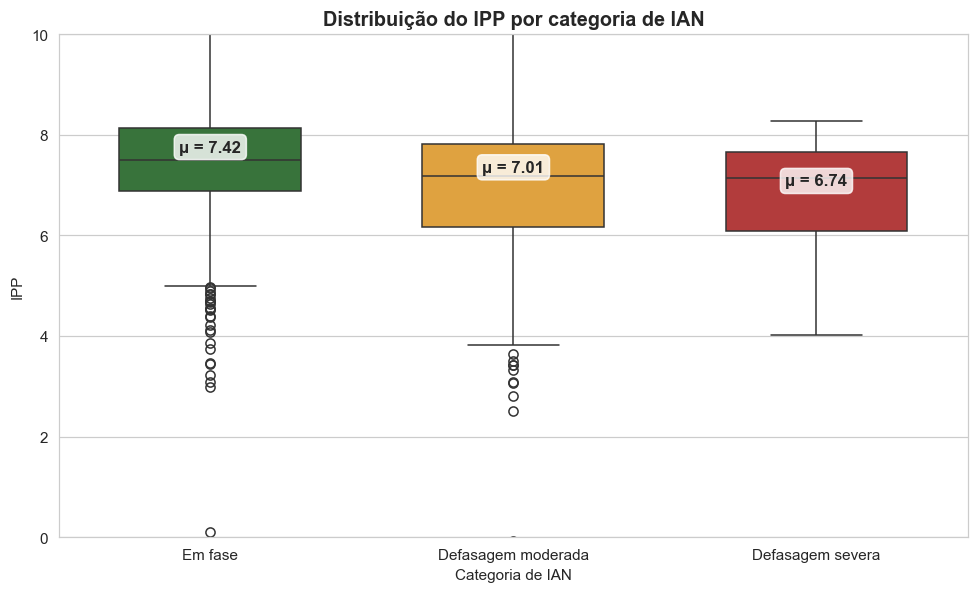

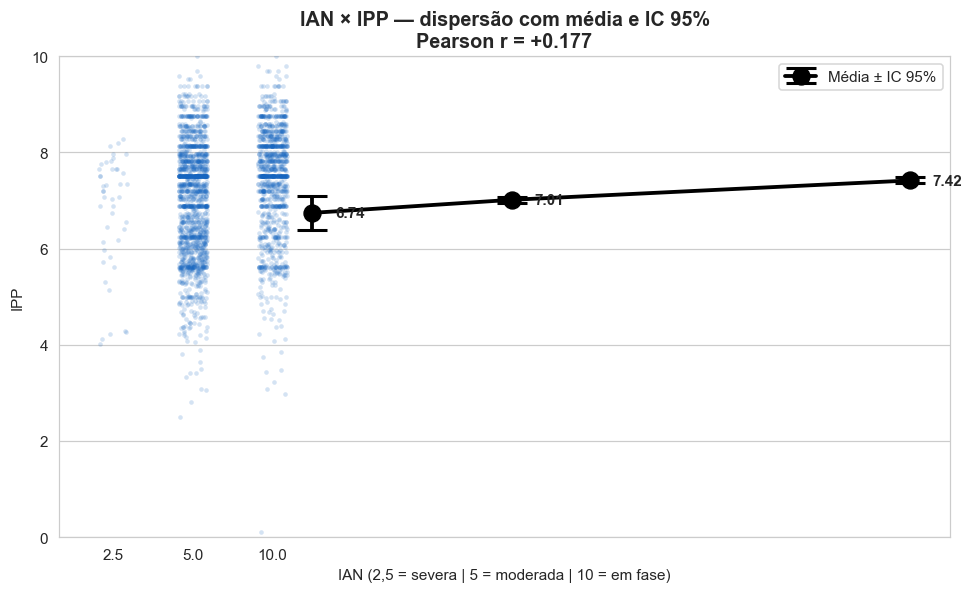

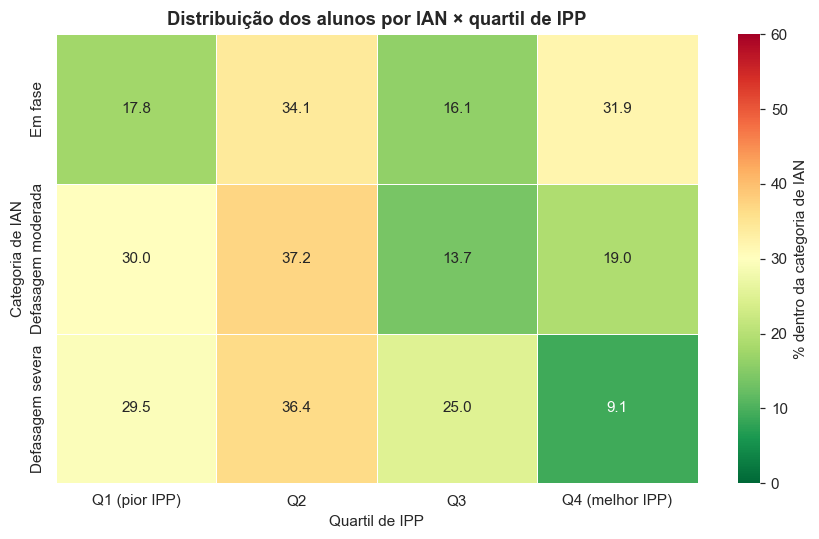

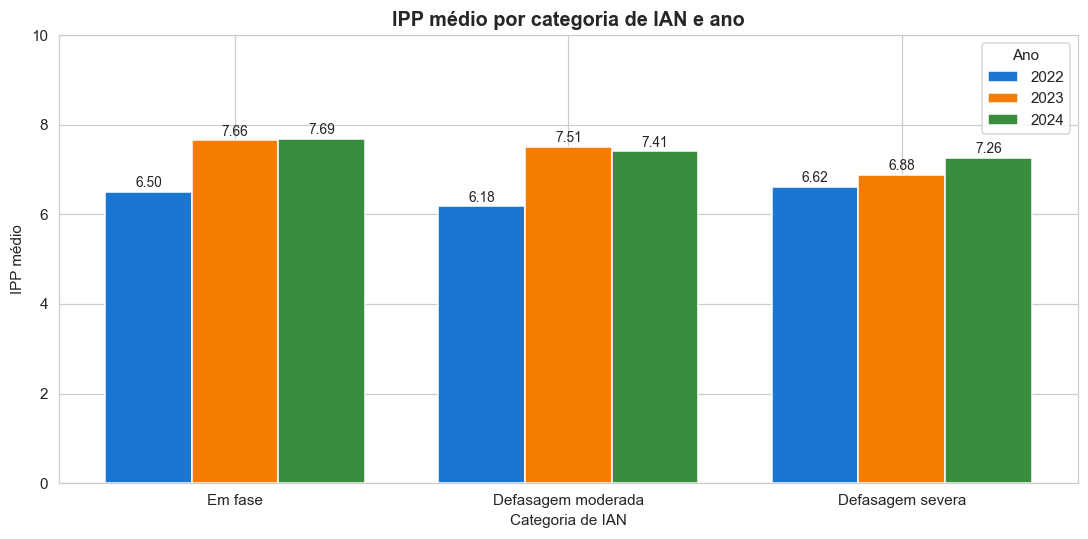


DIAGNÓSTICO — O IPP CONFIRMA OU CONTRADIZ O IAN?

IPP médio 'Em fase'           : 7.42
IPP médio 'Defasagem moderada': 7.01
IPP médio 'Defasagem severa'  : 6.74

Δ Em fase − Severa : +0.68

→ IPP CONFIRMA o IAN.
   O IPP médio cai de forma consistente conforme a defasagem aumenta.


In [62]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')


# ============================================================
# 1. CATEGORIZAÇÃO DO IAN
# ============================================================
def categorizar_ian(x):
    if pd.isna(x):  return 'Sem informação'
    if x >= 10:     return 'Em fase'
    if x >= 5:      return 'Defasagem moderada'
    return 'Defasagem severa'

df['IAN_categoria'] = df['IAN'].apply(categorizar_ian)

ordem_ian = ['Em fase', 'Defasagem moderada', 'Defasagem severa']
cores_ian = {
    'Em fase':            '#2E7D32',
    'Defasagem moderada': '#F9A825',
    'Defasagem severa':   '#C62828',
}

print(f"Base: {df.shape[0]} registros")
print(f"IPP nulos: {df['IPP'].isna().sum()}")


# ============================================================
# 2. ESTATÍSTICAS DO IPP POR CATEGORIA DE IAN
# ============================================================
resumo = (
    df.groupby('IAN_categoria', observed=True)['IPP']
      .agg(n='size', media='mean', mediana='median',
           desvio='std',
           p25=lambda s: s.quantile(0.25),
           p75=lambda s: s.quantile(0.75))
      .reindex(ordem_ian)
      .round(2)
)

# Adiciona uma linha de Total
total_row = pd.DataFrame({
    'n': [int(resumo['n'].sum())],
    'media': [round(df['IPP'].mean(), 2)],
    'mediana': [round(df['IPP'].median(), 2)],
    'desvio': [round(df['IPP'].std(), 2)],
    'p25': [round(df['IPP'].quantile(0.25), 2)],
    'p75': [round(df['IPP'].quantile(0.75), 2)],
}, index=['Total'])

resumo = pd.concat([resumo, total_row])

print("=" * 78)
print("IPP POR CATEGORIA DE IAN (com Total)")
print("=" * 78)
print(resumo.to_string())

# Diferenças explícitas
d_em_vs_mod   = resumo.loc['Em fase', 'media'] - resumo.loc['Defasagem moderada', 'media']
d_mod_vs_sev  = resumo.loc['Defasagem moderada', 'media'] - resumo.loc['Defasagem severa', 'media']
d_em_vs_sev   = resumo.loc['Em fase', 'media'] - resumo.loc['Defasagem severa', 'media']

print(f"\n▶ IPP médio Em fase − Defasagem moderada : {d_em_vs_mod:+.2f}")
print(f"▶ IPP médio Moderada − Severa            : {d_mod_vs_sev:+.2f}")
print(f"▶ IPP médio Em fase − Defasagem severa   : {d_em_vs_sev:+.2f}")


# ============================================================
# 3. CORRELAÇÃO IAN × IPP
# ============================================================
sub = df[['IAN', 'IPP']].dropna()
r_p, p_p = stats.pearsonr(sub['IAN'], sub['IPP'])
r_s, p_s = stats.spearmanr(sub['IAN'], sub['IPP'])

print("\n" + "=" * 78)
print("CORRELAÇÃO IAN × IPP")
print("=" * 78)
print(f"Pearson  : r = {r_p:+.3f}   p = {p_p:.6f}   n = {len(sub)}")
print(f"Spearman : r = {r_s:+.3f}   p = {p_s:.6f}")

# Por ano
print("\nPor ano (Pearson):")
for ano, sub_a in df.groupby('ano', observed=True):
    s = sub_a[['IAN', 'IPP']].dropna()
    if len(s) < 20: continue
    r, p = stats.pearsonr(s['IAN'], s['IPP'])
    print(f"  {ano}: r = {r:+.3f}   p = {p:.6f}   n = {len(s)}")


# ============================================================
# 4. TESTES ESTATÍSTICOS — Kruskal-Wallis + Mann-Whitney pareado
# ============================================================
grupos = [sub_a['IPP'].dropna().values
          for cat, sub_a in df.groupby('IAN_categoria', observed=True)
          if cat in ordem_ian]

stat_kw, p_kw = stats.kruskal(*grupos)
print("\n" + "=" * 78)
print("TESTE DE KRUSKAL-WALLIS")
print("=" * 78)
print(f"H = {stat_kw:.2f}   p = {p_kw:.6f}")
if p_kw < 0.05:
    print("→ Há diferença significativa de IPP entre as categorias de IAN.")
else:
    print("→ IPP NÃO difere significativamente entre categorias de IAN.")

print("\n" + "=" * 78)
print("TESTES PAREADOS — Mann-Whitney U (α ajustado = 0.017)")
print("=" * 78)
for i, c1 in enumerate(ordem_ian):
    for c2 in ordem_ian[i+1:]:
        g1 = df.loc[df['IAN_categoria'] == c1, 'IPP'].dropna()
        g2 = df.loc[df['IAN_categoria'] == c2, 'IPP'].dropna()
        u, p = stats.mannwhitneyu(g1, g2, alternative='two-sided')
        sig = '✓ significativo' if p < 0.017 else '× não significativo'
        print(f"  {c1:<22} vs {c2:<22}: U = {u:>10.1f}  p = {p:.6f}  {sig}")


# ============================================================
# 5. TABELA CRUZADA — IAN × Quartil de IPP
# ============================================================
df['IPP_quartil'] = pd.qcut(df['IPP'], q=4,
                            labels=['Q1 (pior IPP)', 'Q2', 'Q3', 'Q4 (melhor IPP)'],
                            duplicates='drop')

tab_cruz   = pd.crosstab(df['IAN_categoria'], df['IPP_quartil'],
                         normalize='index') * 100
tab_cruz   = tab_cruz.reindex(ordem_ian).round(1)
tab_cruz_n = pd.crosstab(df['IAN_categoria'], df['IPP_quartil']).reindex(ordem_ian)

# Adiciona totais
tab_cruz['Total']   = tab_cruz.sum(axis=1)
tab_cruz_n['Total'] = tab_cruz_n.sum(axis=1)
tab_cruz.loc['Total']   = tab_cruz.sum(axis=0)
tab_cruz_n.loc['Total'] = tab_cruz_n.sum(axis=0)

print("\n" + "=" * 78)
print("DISTRIBUIÇÃO (%) — CATEGORIA DE IAN × QUARTIL DE IPP (com totais)")
print("=" * 78)
print(tab_cruz.to_string())

print("\nContagens absolutas:")
print(tab_cruz_n.to_string())


# ============================================================
# 6. VISUALIZAÇÃO 1 — Boxplot IPP por IAN (com médias anotadas)
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

sns.boxplot(data=df, x='IAN_categoria', y='IPP',
            order=ordem_ian,
            palette=[cores_ian[c] for c in ordem_ian],
            ax=ax, width=0.6)

medias = df.groupby('IAN_categoria', observed=True)['IPP'].mean().reindex(ordem_ian)
for i, m in enumerate(medias):
    ax.text(i, m + 0.25, f"μ = {m:.2f}",
            ha='center', fontsize=11, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_title('Distribuição do IPP por categoria de IAN',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Categoria de IAN')
ax.set_ylabel('IPP')
ax.set_ylim(0, 10)
plt.tight_layout()
plt.show()


# ============================================================
# 7. VISUALIZAÇÃO 2 — Dispersão IAN × IPP com média e IC
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

# Scatter com jitter
sns.stripplot(data=df, x='IAN', y='IPP', ax=ax,
              jitter=0.18, alpha=0.18, size=3, color='#1565C0')

# Média + IC 95% por valor de IAN
med = df.groupby('IAN')['IPP'].agg(['mean', 'std', 'count'])
med['se'] = med['std'] / np.sqrt(med['count'])

ax.errorbar(med.index, med['mean'],
            yerr=med['se'] * 1.96,
            fmt='o-', color='black', linewidth=2.5,
            markersize=11, capsize=10, capthick=2,
            label='Média ± IC 95%')

for x, y in zip(med.index, med['mean']):
    ax.annotate(f"{y:.2f}", (x, y),
                textcoords="offset points", xytext=(15, -3),
                fontsize=10, fontweight='bold')

r, _ = stats.pearsonr(df['IAN'], df['IPP'])
ax.set_title(f'IAN × IPP — dispersão com média e IC 95%\nPearson r = {r:+.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('IAN (2,5 = severa | 5 = moderada | 10 = em fase)')
ax.set_ylabel('IPP')
ax.set_ylim(0, 10)
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 8. VISUALIZAÇÃO 3 — Heatmap IAN × quartil de IPP
# ============================================================
fig, ax = plt.subplots(figsize=(8, 5))

heat = tab_cruz.drop(index='Total', columns='Total')

sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.6, vmin=0, vmax=60,
            cbar_kws={'label': '% dentro da categoria de IAN'}, ax=ax)

ax.set_title('Distribuição dos alunos por IAN × quartil de IPP',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Quartil de IPP')
ax.set_ylabel('Categoria de IAN')
plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 4 — IPP médio por IAN e ano
# ============================================================
medias_ian_ano = (
    df.pivot_table(index='IAN_categoria', columns='ano',
                   values='IPP', aggfunc='mean', observed=True)
      .reindex(ordem_ian).round(2)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(ordem_ian))
w = 0.26
cores_ano = {2022: '#1976D2', 2023: '#F57C00', 2024: '#388E3C'}

for i, ano in enumerate(medias_ian_ano.columns):
    vals = medias_ian_ano[ano].values
    bars = ax.bar(x + (i-1)*w, vals, width=w,
                  color=cores_ano[int(ano)],
                  edgecolor='white', label=f'{int(ano)}')
    for b, v in zip(bars, vals):
        if pd.notna(v):
            ax.text(b.get_x() + b.get_width()/2, v + 0.1, f"{v:.2f}",
                    ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(ordem_ian)
ax.set_title('IPP médio por categoria de IAN e ano',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Categoria de IAN')
ax.set_ylabel('IPP médio')
ax.set_ylim(0, 10)
ax.legend(title='Ano')
plt.tight_layout()
plt.show()


# ============================================================
# 10. DIAGNÓSTICO FINAL
# ============================================================
print("\n" + "=" * 78)
print("DIAGNÓSTICO — O IPP CONFIRMA OU CONTRADIZ O IAN?")
print("=" * 78)

em_fase = resumo.loc['Em fase', 'media']
moderada = resumo.loc['Defasagem moderada', 'media']
severa  = resumo.loc['Defasagem severa', 'media']

print(f"\nIPP médio 'Em fase'           : {em_fase:.2f}")
print(f"IPP médio 'Defasagem moderada': {moderada:.2f}")
print(f"IPP médio 'Defasagem severa'  : {severa:.2f}")
print(f"\nΔ Em fase − Severa : {em_fase - severa:+.2f}")

# Ordem consistente?
ordem_ok = em_fase > moderada > severa
delta_total = em_fase - severa

if ordem_ok and delta_total > 0.5:
    print("\n→ IPP CONFIRMA o IAN.")
    print("   O IPP médio cai de forma consistente conforme a defasagem aumenta.")
elif ordem_ok and delta_total > 0.2:
    print("\n→ IPP confirma FRACAMENTE o IAN.")
    print("   Direção correta, mas a magnitude da diferença é pequena.")
elif delta_total < -0.2:
    print("\n→ IPP CONTRADIZ o IAN.")
    print("   Alunos mais defasados têm IPP médio MAIOR que os em fase.")
else:
    print("\n→ Sem evidência clara de confirmação ou contradição.")
    print("   IPP e IAN caminham de forma praticamente independente.")

# 7. Ponto de virada (IPV)
Quais comportamentos - acadêmicos, emocionais ou de engajamento -
mais influenciam o IPV ao longo do tempo?

Três indicadores dominam o Ponto de virada (IPV): IPP (psicopedagógico), IDA (desempenho) e IEG (engajamento), nessa ordem. Juntos, explicam 51,4% da variância do IPV (R² = 0,514, n = 2.845). As três dimensões (acadêmica, engajamento e emocional) contribuem de forma equilibrada e complementar, mas com sobreposição — cada uma isoladamente explica ~30% do IPV, e juntas explicam 51%, indicando que compartilham parte do sinal.

Contribuição por dimensão (R² isolado)
Dimensão	                        R² isolado	% do IPV
Acadêmica (IDA + IAN + Defasagem)	0,322	32,2%
Engajamento (IEG)	                0,312	31,2%
Emocional (IAA + IPS + IPP)	        0,278	27,8%
Modelo completo	                    0,514	51,4%


A tendência temporal favorece o IPP
Olhando a evolução ano a ano, o padrão é claro:

Período	Indicador dominante	Leitura
2022	IDA (β = 0,39)	O IPV estava fortemente ligado ao desempenho
2023	IPP (β = 0,36) começa a superar IDA	Transição
2024	IPP (β = 0,60) domina com folga	O IPV se descolou do desempenho
Isso é um achado estratégico: se a Passos Mágicos quer influenciar o IPV (a "virada"), a alavanca mais eficaz deixou de ser o desempenho acadêmico e passou a ser o desenvolvimento psicopedagógico.


IPP (emocional/psicopedagógico) — é hoje o principal motor do IPV (β = 0,35 no agregado, β = 0,60 em 2024), com tendência crescente.

IDA (acadêmico) — teve o maior poder explicativo em 2022 (β = 0,39), mas perdeu força consistentemente (β = 0,16 em 2024).

IEG (engajamento) — mantém peso estável e moderado ao longo dos três anos (β ≈ 0,20 a 0,30) e é o segundo melhor preditor do IPV futuro (r = 0,368 com lag 1).

Os indicadores IPS, IAA, IAN e Defasagem não agregam informação adicional quando os três anteriores estão no modelo — são dimensões sobrepostas ou residuais.


Recomendações práticas
Priorizar o IPP nas decisões de intervenção. É o indicador que mais se relaciona com o IPV e cuja relevância cresce a cada ano.

Não descartar o IDA, mas reposicioná-lo. Continua relevante, mas seu peso está caindo — não deve ser o único critério para avaliar "potencial de virada".

Investir no IEG como alavanca de médio prazo. Como ele antecipa o IPV do ano seguinte, ações que aumentem engajamento hoje têm efeito mensurável em um ano.

Monitorar o IPS e o IAA como sinais qualitativos. Não predizem o IPV, mas continuam relevantes para o acompanhamento individual dos alunos.

Observar o salto do IPP de 2023 para 2024. Esse comportamento pode indicar uma mudança de critério de avaliação dos pedagogos, ou uma mudança real na dinâmica dos alunos. Vale investigar antes de tratar como tendência consolidada.

Base: 2845 registros
IPV — nulos: 0

CORRELAÇÕES UNIVARIADAS — IPV × CADA INDICADOR
     Indicador    Dimensão    n  r_pearson  p_pearson  r_spearman  p_spearman  abs_r
INDE_ano_atual   Compósito 2845      0.721   0.000000       0.698    0.000000  0.721
           IEG Engajamento 2845      0.558   0.000000       0.546    0.000000  0.558
           IDA   Acadêmica 2845      0.557   0.000000       0.562    0.000000  0.557
           IPP   Emocional 2845      0.520   0.000000       0.527    0.000000  0.520
     Defasagem   Acadêmica 2845      0.189   0.000000       0.191    0.000000  0.189
           IAN   Acadêmica 2845      0.149   0.000000       0.160    0.000000  0.149
           IAA   Emocional 2845      0.062   0.000879       0.117    0.000000  0.062
           IPS   Emocional 2845     -0.049   0.008959       0.023    0.217481  0.049

Registros utilizados na regressão: 2845

REGRESSÃO MÚLTIPLA PADRONIZADA — IPV ~ todos os indicadores
R² = 0.5141   R² ajustado = 0.5129   n = 2845

Co

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\568207976.py:145: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  linha[col] = round(modelo.params[i+1], 3)
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\568207976.py:145: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  linha[col] = round(modelo.params[i+1], 3)
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\568207976.py:145: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  linha[col]

                n     R2    IDA    IAN  Defasagem    IEG    IAA    IPS    IPP
Fase_Ideal_1                                                                 
ALFA          236  0.416  0.152  0.000     -0.037  0.298 -0.089  0.015  0.358
Fase 1        386  0.297  0.243 -0.180      0.161  0.253  0.020 -0.036  0.279
Fase 2        745  0.507  0.282  0.129     -0.202  0.276 -0.022 -0.010  0.398
Fase 3        643  0.616  0.200 -0.218      0.142  0.315 -0.016 -0.033  0.447
Fase 4        270  0.748  0.177  0.437     -0.419  0.242  0.033 -0.051  0.548
Fase 5        217  0.674  0.174 -0.090      0.194  0.266 -0.022 -0.002  0.526
Fase 6        171  0.654  0.288  0.082     -0.090  0.311  0.052  0.006  0.372
Fase 7        142  0.580  0.178 -0.214      0.136  0.077  0.037  0.162  0.551

LAG 1 — INDICADOR EM T × IPV EM T+1 (correlações univariadas)
Indicador Transição   n  r_pearson       p
      IDA 2022→2023 570      0.411 0.00000
      IDA 2023→2024 678      0.420 0.00000
      IAN 2022→2023 570     

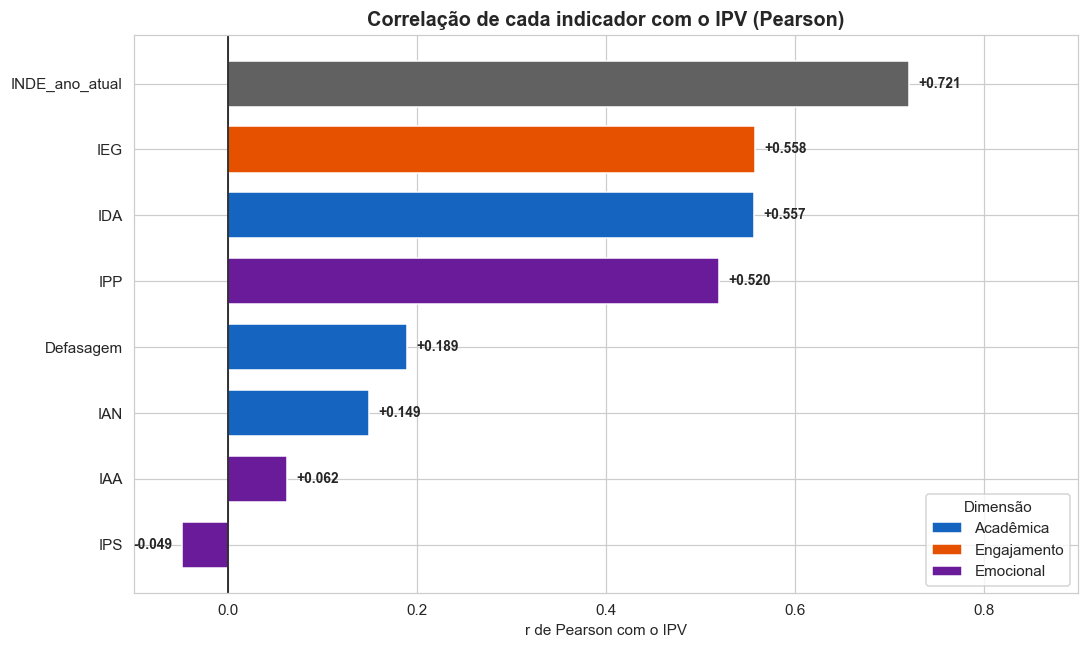

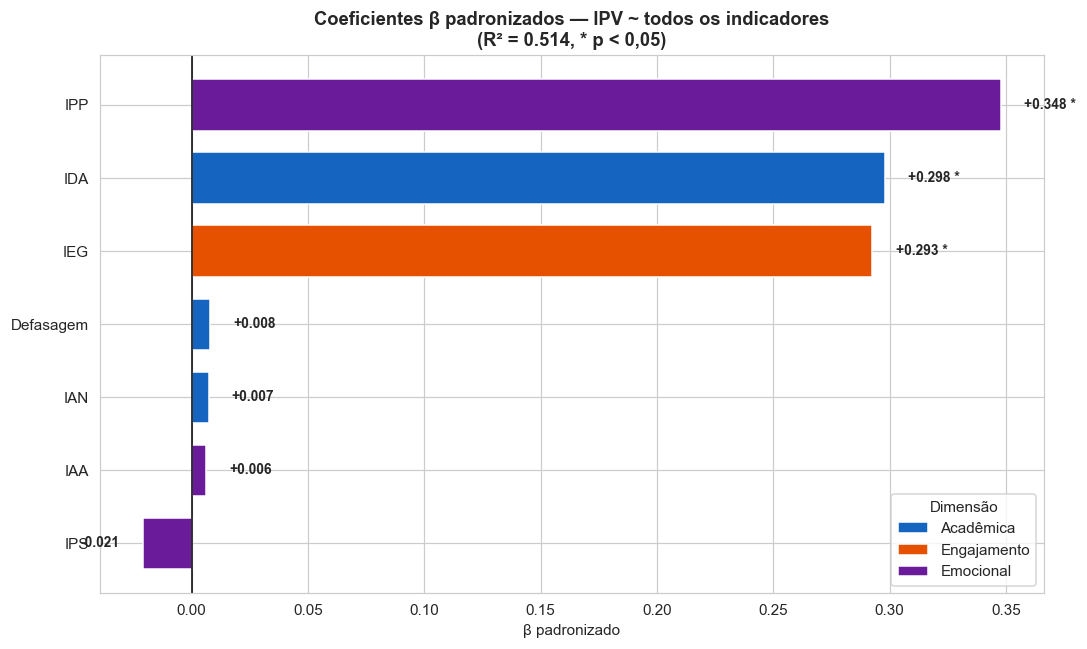

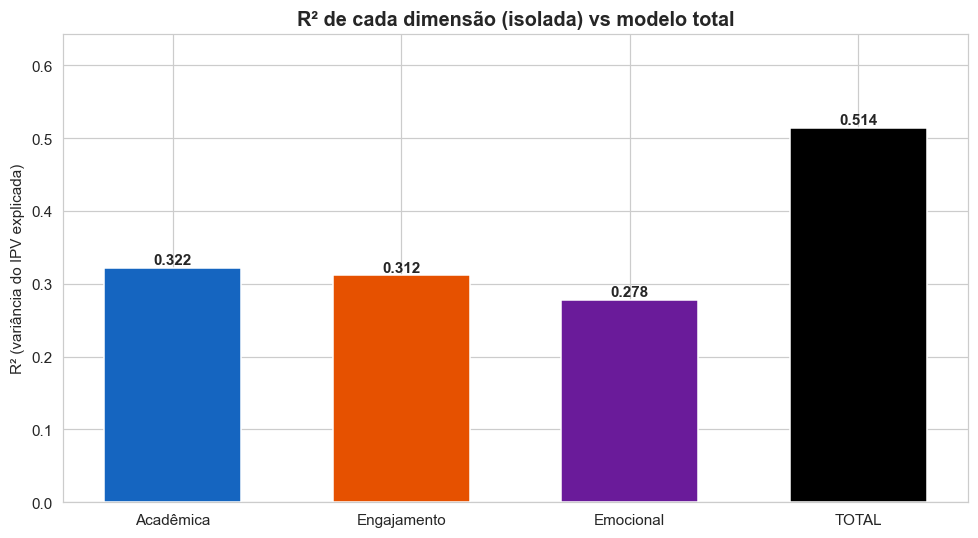

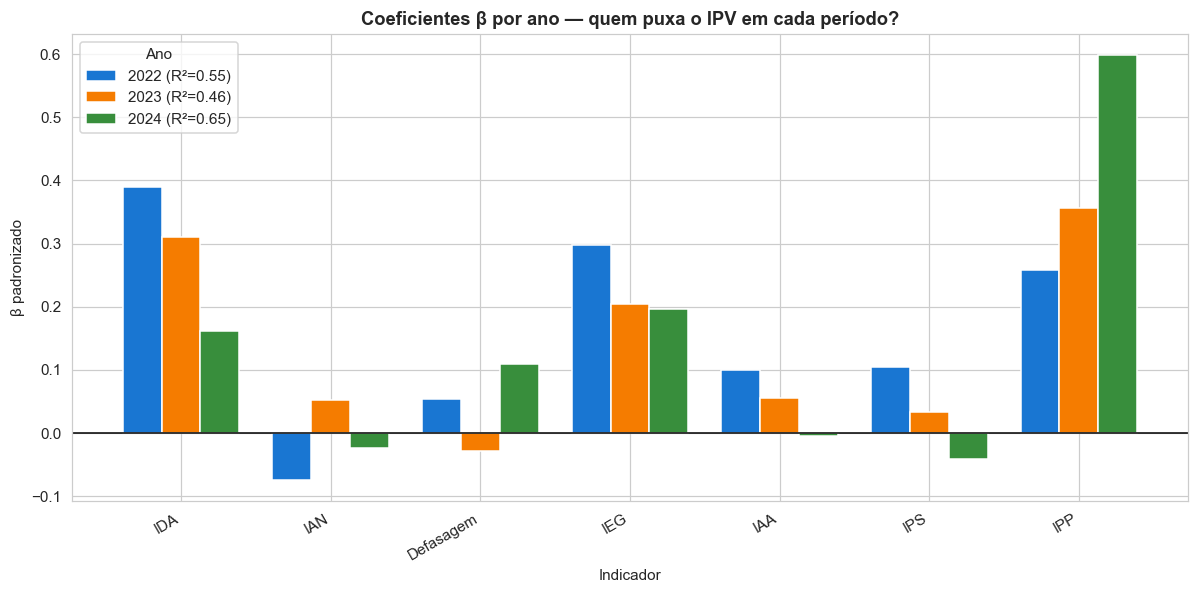

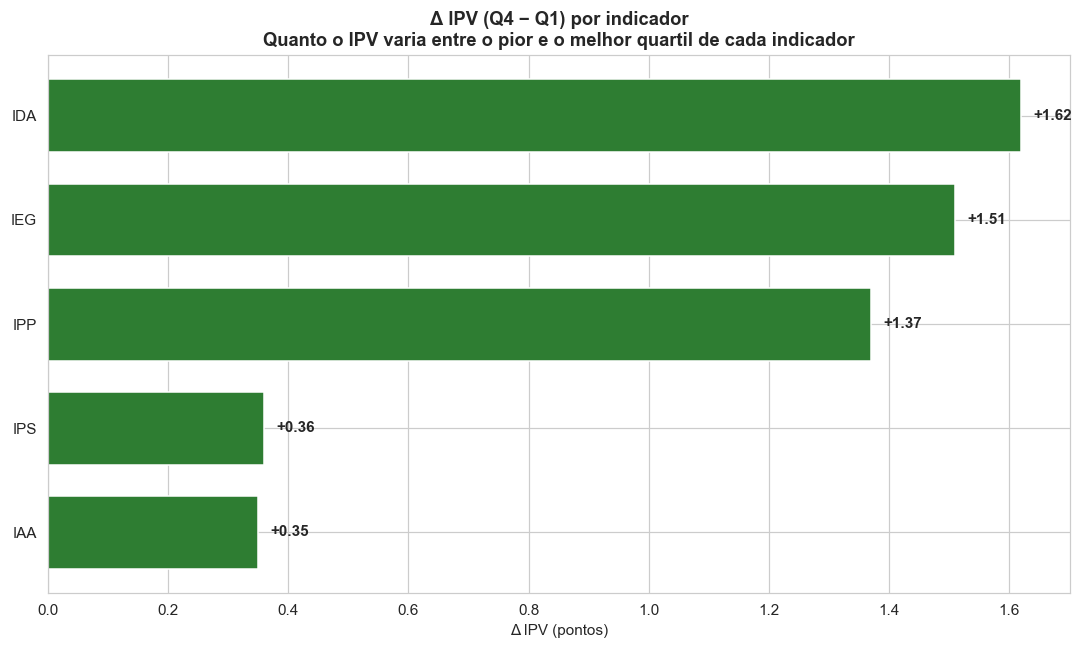

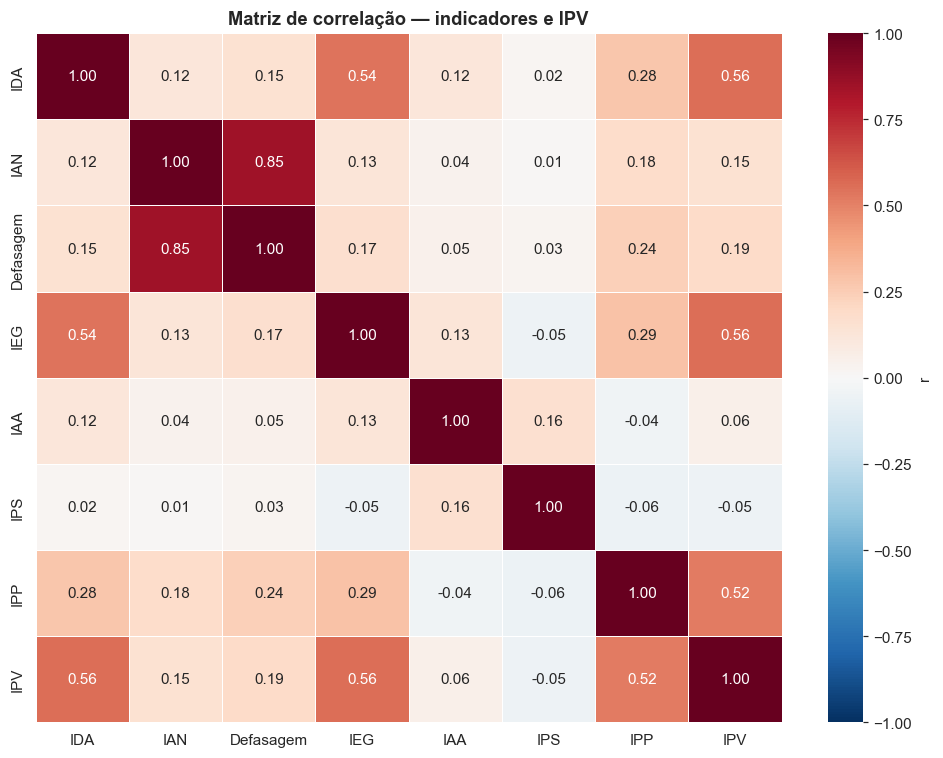


DIAGNÓSTICO — QUAIS COMPORTAMENTOS MAIS INFLUENCIAM O IPV?

▶ TOP 5 indicadores por |β| padronizado (regressão múltipla):
   IPP            [Emocional   ] β = +0.348   p = 0.0000  ✓
   IDA            [Acadêmica   ] β = +0.298   p = 0.0000  ✓
   IEG            [Engajamento ] β = +0.293   p = 0.0000  ✓
   IPS            [Emocional   ] β = -0.021   p = 0.1155  ×
   Defasagem      [Acadêmica   ] β = +0.008   p = 0.7567  ×

▶ TOP 5 indicadores por |r| univariado:
   INDE_ano_atual [Compósito   ] r = +0.721
   IEG            [Engajamento ] r = +0.558
   IDA            [Acadêmica   ] r = +0.557
   IPP            [Emocional   ] r = +0.520
   Defasagem      [Acadêmica   ] r = +0.189

▶ Contribuição por dimensão (R² isolado):
   Acadêmica      : 0.3216  (32.2%)
   Engajamento    : 0.3118  (31.2%)
   Emocional      : 0.2777  (27.8%)

▶ Dimensão que MAIS explica o IPV (isoladamente): Acadêmica
▶ Soma dos R² das dimensões: 0.9111
▶ R² do modelo completo    : 0.5141
   → As dimensões têm SOBREPOSIÇ

In [64]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

# Grupos dimensionais
DIM_ACADEMICA  = ['IDA', 'IAN', 'Defasagem']            # desempenho + adequação
DIM_ENGAJAMENTO = ['IEG']                                # engajamento
DIM_EMOCIONAL  = ['IAA', 'IPS', 'IPP']                  # autoavaliação, psicossocial, psicopedagógico

PREDITORES = DIM_ACADEMICA + DIM_ENGAJAMENTO + DIM_EMOCIONAL

# Remove IAN_categoria e categoriza IAN para padronização
# (Defasagem e IAN são correlacionados negativamente; mantemos ambos para o modelo completo)
print(f"Base: {df.shape[0]} registros")
print(f"IPV — nulos: {df['IPV'].isna().sum()}")


# ============================================================
# 1. CORRELAÇÕES UNIVARIADAS — IPV vs cada preditor
# ============================================================
print("\n" + "=" * 78)
print("CORRELAÇÕES UNIVARIADAS — IPV × CADA INDICADOR")
print("=" * 78)

corr_tab = []
for col in PREDITORES + ['INDE_ano_atual']:
    sub = df[[col, 'IPV']].dropna()
    if len(sub) < 30:
        continue
    r_p, p_p = stats.pearsonr(sub[col], sub['IPV'])
    r_s, p_s = stats.spearmanr(sub[col], sub['IPV'])
    corr_tab.append({
        'Indicador': col,
        'Dimensão': ('Acadêmica' if col in DIM_ACADEMICA else
                     'Engajamento' if col in DIM_ENGAJAMENTO else
                     'Emocional' if col in DIM_EMOCIONAL else 'Compósito'),
        'n': len(sub),
        'r_pearson': round(r_p, 3),
        'p_pearson': round(p_p, 6),
        'r_spearman': round(r_s, 3),
        'p_spearman': round(p_s, 6),
        'abs_r': round(abs(r_p), 3),
    })

corr_tab = pd.DataFrame(corr_tab).sort_values('abs_r', ascending=False)
print(corr_tab.to_string(index=False))


# ============================================================
# 2. REGRESSÃO MÚLTIPLA PADRONIZADA — coeficientes β
#    Padronizamos X e y para comparar o impacto relativo
# ============================================================
mask_ok = df[PREDITORES + ['IPV']].notna().all(axis=1)
df_reg = df[mask_ok].copy()
print(f"\nRegistros utilizados na regressão: {len(df_reg)}")

scaler = StandardScaler()
X_std = scaler.fit_transform(df_reg[PREDITORES])
y_std = (df_reg['IPV'] - df_reg['IPV'].mean()) / df_reg['IPV'].std()

X_std_const = sm.add_constant(X_std)
modelo_full = sm.OLS(y_std, X_std_const).fit()

coefs = pd.DataFrame({
    'Indicador': ['const'] + PREDITORES,
    'beta': modelo_full.params.round(4),
    'p_valor': modelo_full.pvalues.round(6),
    'IC_low':  modelo_full.conf_int()[0].round(4),
    'IC_high': modelo_full.conf_int()[1].round(4),
})
coefs = coefs[coefs['Indicador'] != 'const']
coefs['abs_beta'] = coefs['beta'].abs()
coefs['Dimensão'] = coefs['Indicador'].apply(
    lambda x: 'Acadêmica' if x in DIM_ACADEMICA else
              'Engajamento' if x in DIM_ENGAJAMENTO else 'Emocional'
)

print("\n" + "=" * 78)
print("REGRESSÃO MÚLTIPLA PADRONIZADA — IPV ~ todos os indicadores")
print("=" * 78)
print(f"R² = {modelo_full.rsquared:.4f}   "
      f"R² ajustado = {modelo_full.rsquared_adj:.4f}   "
      f"n = {int(modelo_full.nobs)}")
print("\nCoeficientes β (padronizados):")
print(coefs.sort_values('abs_beta', ascending=False)
           .to_string(index=False))


# ============================================================
# 3. IMPORTÂNCIA RELATIVA POR DIMENSÃO — variância explicada
# ============================================================
def var_explicada_por_grupo(df_in, grupo_cols, alvo='IPV'):
    """R² do modelo restrito a um grupo de variáveis."""
    sub = df_in[grupo_cols + [alvo]].dropna()
    if len(sub) < 30: return None
    X = sm.add_constant(sub[grupo_cols])
    modelo = sm.OLS(sub[alvo], X).fit()
    return modelo.rsquared

r2_por_dim = {}
for dim, cols in [('Acadêmica', DIM_ACADEMICA),
                  ('Engajamento', DIM_ENGAJAMENTO),
                  ('Emocional', DIM_EMOCIONAL)]:
    r2 = var_explicada_por_grupo(df_reg, cols)
    r2_por_dim[dim] = round(r2, 4) if r2 else None

r2_full = var_explicada_por_grupo(df_reg, PREDITORES)

print("\n" + "=" * 78)
print("R² POR DIMENSÃO (isolada) vs R² TOTAL")
print("=" * 78)
for k, v in r2_por_dim.items():
    print(f"  {k:<15}: R² = {v:.4f}  ({v*100:.1f}% da variância do IPV)")
print(f"  {'TOTAL':<15}: R² = {r2_full:.4f}  ({r2_full*100:.1f}%)")


# ============================================================
# 4. ANÁLISE POR ANO E POR FASE
# ============================================================
def reg_por_grupo(df_in, grupo):
    """Coeficientes padronizados por subgrupo."""
    res = []
    for g, sub in df_in.groupby(grupo, observed=True):
        sub = sub[PREDITORES + ['IPV']].dropna()
        if len(sub) < 40: continue
        X = StandardScaler().fit_transform(sub[PREDITORES])
        y = (sub['IPV'] - sub['IPV'].mean()) / sub['IPV'].std()
        modelo = sm.OLS(y, sm.add_constant(X)).fit()
        linha = {grupo: g, 'n': len(sub), 'R2': round(modelo.rsquared, 3)}
        for i, col in enumerate(PREDITORES):
            linha[col] = round(modelo.params[i+1], 3)
        res.append(linha)
    return pd.DataFrame(res).set_index(grupo)

print("\n" + "=" * 78)
print("COEFICIENTES β POR ANO")
print("=" * 78)
reg_ano = reg_por_grupo(df_reg, 'ano')
print(reg_ano.to_string())

print("\n" + "=" * 78)
print("COEFICIENTES β POR FASE IDEAL")
print("=" * 78)
reg_fase = reg_por_grupo(df_reg, 'Fase_Ideal_1')
print(reg_fase.to_string())


# ============================================================
# 5. ANÁLISE COM LAG — quem influencia o IPV do ano seguinte?
# ============================================================
def pivot_wide(col):
    return df.pivot_table(index='RA', columns='ano', values=col, aggfunc='last')

piv_ipv = pivot_wide('IPV')
piv_preditores = {c: pivot_wide(c) for c in PREDITORES}

def base_lag(piv_x, piv_y, t_x, t_y):
    bloco = pd.DataFrame({
        'X': piv_x[t_x] if t_x in piv_x.columns else pd.Series(dtype=float),
        'Y': piv_y[t_y] if t_y in piv_y.columns else pd.Series(dtype=float),
    }).dropna()
    return bloco

print("\n" + "=" * 78)
print("LAG 1 — INDICADOR EM T × IPV EM T+1 (correlações univariadas)")
print("=" * 78)

lag_tab = []
for col in PREDITORES:
    for (t_x, t_y) in [(2022, 2023), (2023, 2024)]:
        bloco = base_lag(piv_preditores[col], piv_ipv, t_x, t_y)
        if len(bloco) < 30: continue
        r, p = stats.pearsonr(bloco['X'], bloco['Y'])
        lag_tab.append({
            'Indicador': col,
            'Transição': f'{t_x}→{t_y}',
            'n': len(bloco),
            'r_pearson': round(r, 3),
            'p': round(p, 5),
        })

lag_tab = pd.DataFrame(lag_tab)
print(lag_tab.to_string(index=False))

# Agregando por indicador (média dos r nas duas transições)
lag_agreg = (lag_tab.groupby('Indicador')['r_pearson']
                    .agg(['mean', 'count'])
                    .round(3)
                    .sort_values('mean', ascending=False))
print("\n▶ Média dos r (lag 1) por indicador:")
print(lag_agreg.to_string())


# ============================================================
# 6. QUARTIS — efeito prático dos indicadores sobre o IPV
# ============================================================
print("\n" + "=" * 78)
print("IPV MÉDIO POR QUARTIL DE CADA INDICADOR")
print("=" * 78)

quartil_tab = []
for col in PREDITORES:
    sub = df[[col, 'IPV']].dropna()
    if len(sub) < 50: continue
    sub = sub.copy()
    try:
        sub['Q'] = pd.qcut(sub[col], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    except ValueError:
        continue
    ipv_por_q = sub.groupby('Q', observed=True)['IPV'].mean().round(2)
    if len(ipv_por_q) < 4: continue
    delta = ipv_por_q['Q4'] - ipv_por_q['Q1']
    quartil_tab.append({
        'Indicador': col,
        'IPV_Q1': ipv_por_q['Q1'],
        'IPV_Q2': ipv_por_q['Q2'],
        'IPV_Q3': ipv_por_q['Q3'],
        'IPV_Q4': ipv_por_q['Q4'],
        'Delta_Q4_Q1': round(delta, 2),
        'abs_delta': abs(delta),
    })

quartil_tab = pd.DataFrame(quartil_tab).sort_values('abs_delta', ascending=False)
print(quartil_tab.to_string(index=False))


# ============================================================
# 7. VISUALIZAÇÃO 1 — Correlações univariadas (barh ordenado)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

cores_dim = {'Acadêmica': '#1565C0',
             'Engajamento': '#E65100',
             'Emocional': '#6A1B9A',
             'Compósito': '#616161'}

data_plot = corr_tab.sort_values('r_pearson')
cores = [cores_dim[d] for d in data_plot['Dimensão']]

bars = ax.barh(data_plot['Indicador'], data_plot['r_pearson'],
               color=cores, edgecolor='white', height=0.7)

for b, v in zip(bars, data_plot['r_pearson']):
    ax.text(v + (0.01 if v >= 0 else -0.01), b.get_y() + b.get_height()/2,
            f"{v:+.3f}", va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Correlação de cada indicador com o IPV (Pearson)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('r de Pearson com o IPV')
ax.set_xlim(-0.1, 0.9)

# Legenda manual
from matplotlib.patches import Patch
legenda = [Patch(facecolor=c, label=d) for d, c in cores_dim.items() if d != 'Compósito']
ax.legend(handles=legenda, title='Dimensão', loc='lower right')
plt.tight_layout()
plt.show()


# ============================================================
# 8. VISUALIZAÇÃO 2 — Coeficientes β da regressão múltipla
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

coefs_plot = coefs.sort_values('beta')
cores_beta = [cores_dim[d] for d in coefs_plot['Dimensão']]

bars = ax.barh(coefs_plot['Indicador'], coefs_plot['beta'],
               color=cores_beta, edgecolor='white', height=0.7)

for b, v, p in zip(bars, coefs_plot['beta'], coefs_plot['p_valor']):
    label = f"{v:+.3f}" + (" *" if p < 0.05 else "")
    ax.text(v + (0.01 if v >= 0 else -0.01), b.get_y() + b.get_height()/2,
            label, va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=9, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Coeficientes β padronizados — IPV ~ todos os indicadores\n'
             f'(R² = {modelo_full.rsquared:.3f}, * p < 0,05)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('β padronizado')
ax.legend(handles=legenda, title='Dimensão', loc='lower right')
plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 3 — R² por dimensão (isolada) vs total
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

dims   = list(r2_por_dim.keys()) + ['TOTAL']
valores = [r2_por_dim[d] for d in dims[:-1]] + [r2_full]
cores_bar = [cores_dim[d] for d in dims[:-1]] + ['black']

bars = ax.bar(dims, valores, color=cores_bar, edgecolor='white', width=0.6)
for b, v in zip(bars, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005,
            f"{v:.3f}", ha='center', fontsize=10, fontweight='bold')

ax.set_title('R² de cada dimensão (isolada) vs modelo total',
             fontsize=13, fontweight='bold')
ax.set_ylabel('R² (variância do IPV explicada)')
ax.set_ylim(0, max(valores) * 1.25)
plt.tight_layout()
plt.show()


# ============================================================
# 10. VISUALIZAÇÃO 4 — Coeficientes β por ano
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

reg_ano_plot = reg_ano.drop(columns='n').reset_index()
x = np.arange(len(PREDITORES))
w = 0.26
cores_ano = {2022: '#1976D2', 2023: '#F57C00', 2024: '#388E3C'}

for i, ano in enumerate(reg_ano_plot['ano']):
    vals = [reg_ano_plot.loc[i, c] for c in PREDITORES]
    ax.bar(x + (i-1)*w, vals, width=w,
           color=cores_ano[int(ano)], edgecolor='white',
           label=f'{int(ano)} (R²={reg_ano_plot.loc[i, "R2"]:.2f})')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(PREDITORES, rotation=30, ha='right')
ax.set_title('Coeficientes β por ano — quem puxa o IPV em cada período?',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Indicador')
ax.set_ylabel('β padronizado')
ax.legend(title='Ano')
plt.tight_layout()
plt.show()


# ============================================================
# 11. VISUALIZAÇÃO 5 — Δ IPV entre Q1 e Q4 de cada indicador
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

quartil_sorted = quartil_tab.sort_values('abs_delta')
cores_q = ['#C62828' if d < 0 else '#2E7D32' for d in quartil_sorted['Delta_Q4_Q1']]

bars = ax.barh(quartil_sorted['Indicador'],
               quartil_sorted['Delta_Q4_Q1'],
               color=cores_q, edgecolor='white', height=0.7)

for b, v in zip(bars, quartil_sorted['Delta_Q4_Q1']):
    ax.text(v + (0.02 if v >= 0 else -0.02), b.get_y() + b.get_height()/2,
            f"{v:+.2f}", va='center',
            ha='left' if v >= 0 else 'right',
            fontsize=10, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)
ax.set_title('Δ IPV (Q4 − Q1) por indicador\n'
             'Quanto o IPV varia entre o pior e o melhor quartil de cada indicador',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Δ IPV (pontos)')
plt.tight_layout()
plt.show()


# ============================================================
# 12. VISUALIZAÇÃO 6 — Heatmap correlação entre preditores e IPV
# ============================================================
fig, ax = plt.subplots(figsize=(9, 7))
matriz = df[PREDITORES + ['IPV']].corr().round(2)
sns.heatmap(matriz, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, linewidths=0.6,
            cbar_kws={'label': 'r'}, ax=ax)
ax.set_title('Matriz de correlação — indicadores e IPV',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# 13. DIAGNÓSTICO FINAL
# ============================================================
print("\n" + "=" * 78)
print("DIAGNÓSTICO — QUAIS COMPORTAMENTOS MAIS INFLUENCIAM O IPV?")
print("=" * 78)

print("\n▶ TOP 5 indicadores por |β| padronizado (regressão múltipla):")
top5 = coefs.sort_values('abs_beta', ascending=False).head(5)
for _, row in top5.iterrows():
    sig = '✓' if row['p_valor'] < 0.05 else '×'
    print(f"   {row['Indicador']:<14} [{row['Dimensão']:<12}] "
          f"β = {row['beta']:+.3f}   p = {row['p_valor']:.4f}  {sig}")

print("\n▶ TOP 5 indicadores por |r| univariado:")
for _, row in corr_tab.head(5).iterrows():
    print(f"   {row['Indicador']:<14} [{row['Dimensão']:<12}] "
          f"r = {row['r_pearson']:+.3f}")

print("\n▶ Contribuição por dimensão (R² isolado):")
for k, v in r2_por_dim.items():
    print(f"   {k:<15}: {v:.4f}  ({v*100:.1f}%)")

# Veredito
top_dim = max(r2_por_dim, key=lambda k: r2_por_dim[k] or 0)
print(f"\n▶ Dimensão que MAIS explica o IPV (isoladamente): {top_dim}")

# Soma dos R² das três dimensões vs R² total
soma_r2 = sum(v for v in r2_por_dim.values() if v)
print(f"▶ Soma dos R² das dimensões: {soma_r2:.4f}")
print(f"▶ R² do modelo completo    : {r2_full:.4f}")
if r2_full > soma_r2 * 0.9:
    print("   → As dimensões são COMPLEMENTARES (R² total ≈ soma dos R² isolados).")
else:
    print("   → As dimensões têm SOBREPOSIÇÃO (R² total < soma dos R² isolados).")

print("\n" + "=" * 78)
print("VEREDITO")
print("=" * 78)

top3_beta = coefs.sort_values('abs_beta', ascending=False).head(3)['Indicador'].tolist()
top3_dims = coefs.sort_values('abs_beta', ascending=False).head(3)['Dimensão'].tolist()

from collections import Counter
dim_dominante = Counter(top3_dims).most_common(1)[0][0]

print(f"→ Dimensão dominante: {dim_dominante}")
print(f"→ Top 3 indicadores (por β): {', '.join(top3_beta)}")
print(f"→ R² do modelo completo: {r2_full:.3f} "
      f"({r2_full*100:.1f}% da variância do IPV explicada)")

# 8. Multidimensionalidade dos indicadores
Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais 
a nota global do aluno (INDE)?

A melhor combinação de indicadores para descrever  o INDE, são todos esses 4 juntos - R² do modelo completo: 0.843 (84.3% da variância do INDE).

O IDA individualmente é o que mais se correlaciona com o INDE. R² do modelo completo: 0.6167 (61.67% da variância do INDE).

▶ Contribuição marginal de cada indicador (cenário 'outros em Q1'):
   IDA    ↑  →  Δ INDE = +1.52
   IPS    ↑  →  Δ INDE = +0.74

Base: 2845 registros
INDE nulos: 0
Registros com todos os indicadores + INDE: 2845

1. DECOMPOSIÇÃO — QUANTO CADA INDICADOR CONTRIBUI PARA O INDE

▶ Coeficientes da regressão INDE ~ IDA + IEG + IPS + IPP
         coef  std_err      t    p
const  1.3947   0.0614  22.73  0.0
IDA    0.2471   0.0046  54.28  0.0
IEG    0.2727   0.0057  47.91  0.0
IPS    0.1235   0.0042  29.75  0.0
IPP    0.1781   0.0068  26.38  0.0

R² = 0.8430   R² ajustado = 0.8428   n = 2845

▶ Contribuição média ao INDE (média × coef)
   IDA   : 1.576  (26.8% do INDE explicado)
   IEG   : 2.244  (38.2% do INDE explicado)
   IPS   : 0.778  (13.2% do INDE explicado)
   IPP   : 1.278  (21.7% do INDE explicado)

▶ Soma dos coeficientes: 0.8214
   (se ≈ 1, o INDE é uma média ponderada desses 4 indicadores)

2. CORRELAÇÕES COM O INDE
IDA    0.785
IEG    0.745
IPP    0.454
IPS    0.200

▶ Matriz de correlação entre os 4 indicadores:
       IDA    IEG    IPS    IPP
IDA  1.000  0.544  0.022  0.280
IEG  0.544  1.000 -0.047  0.287

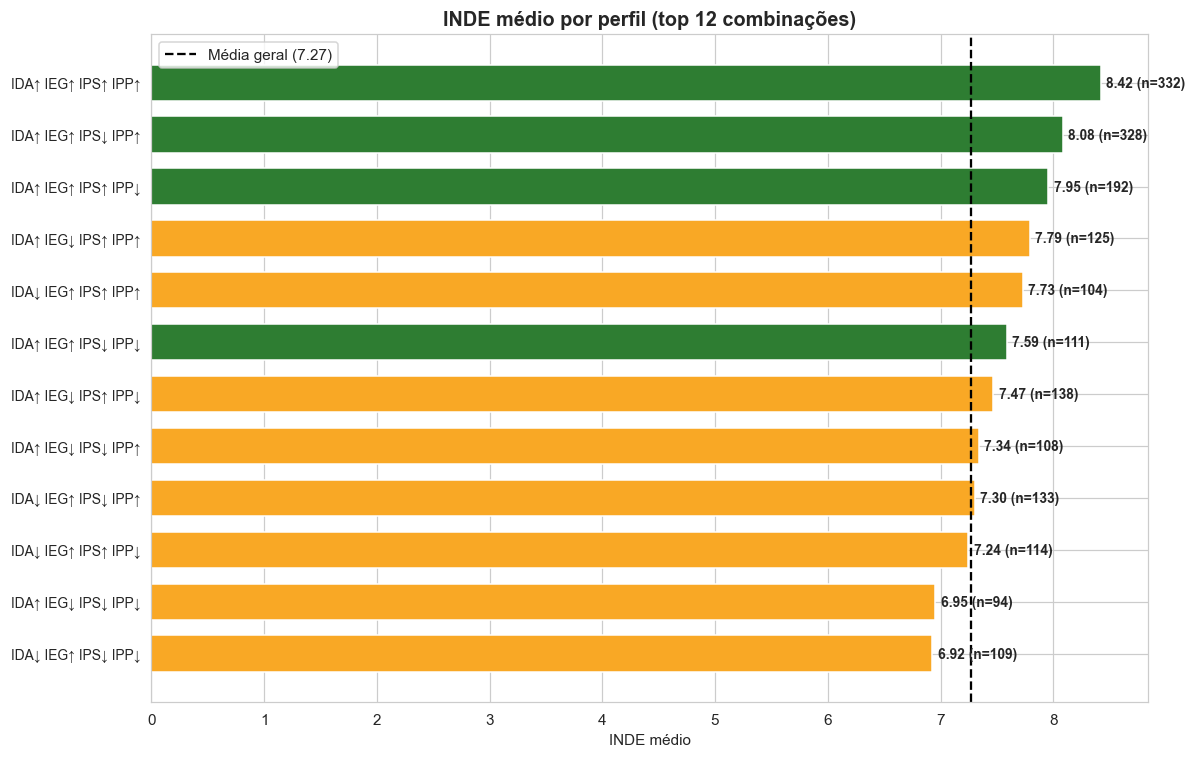

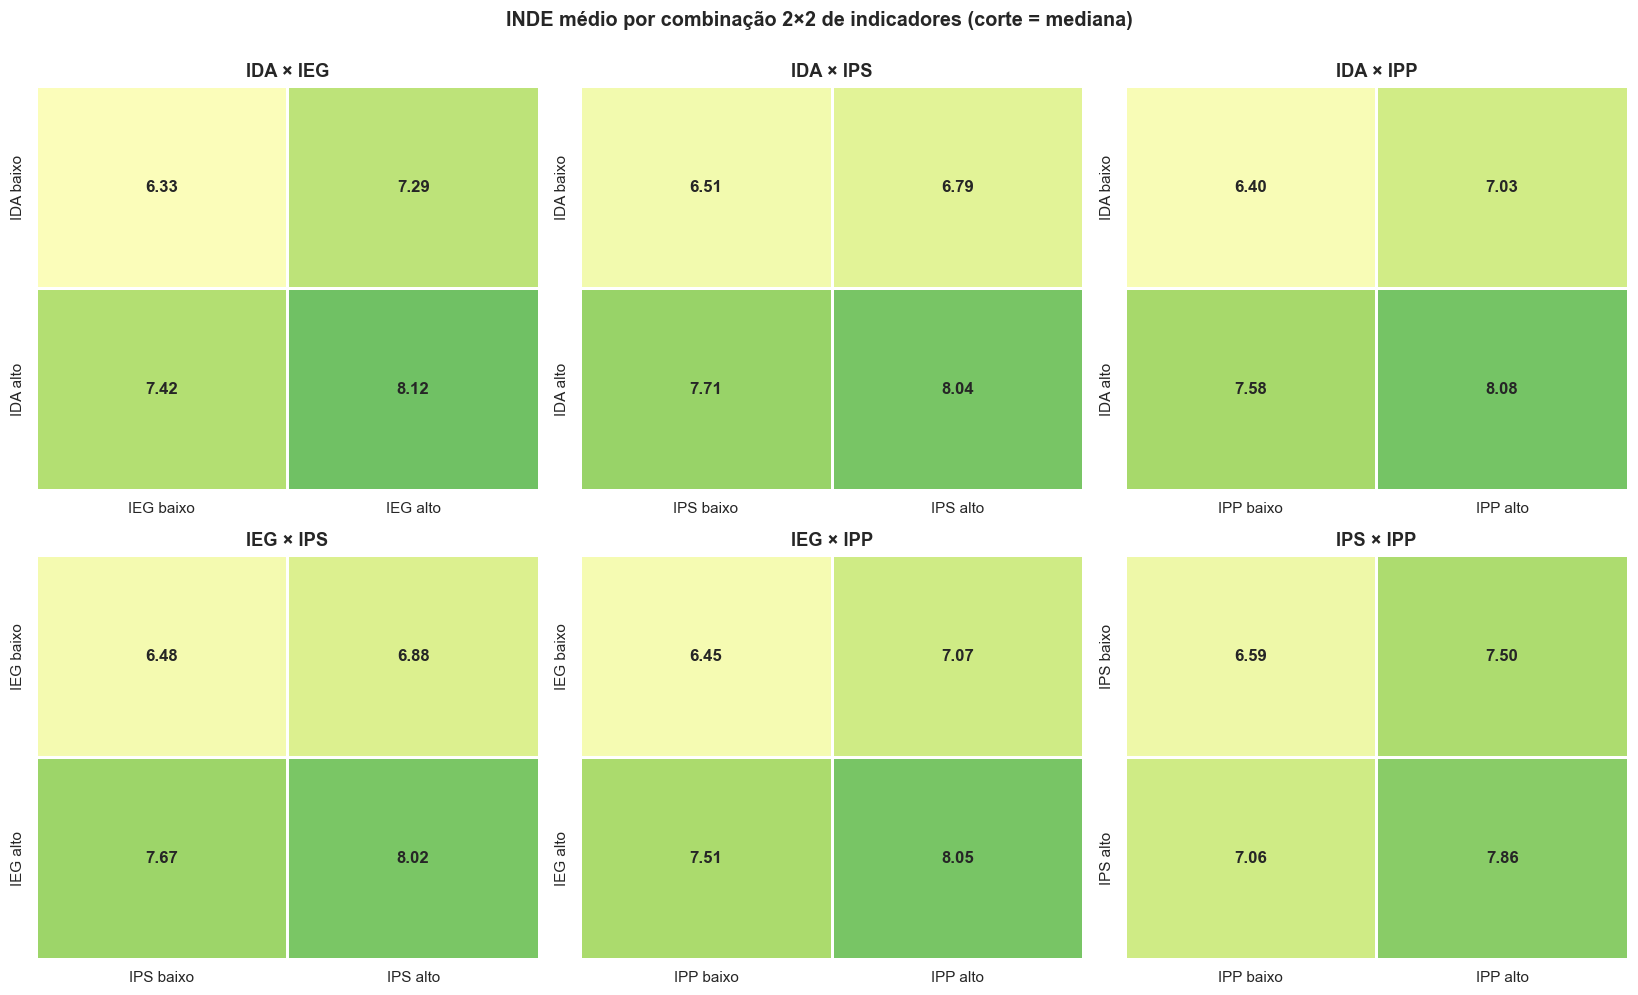

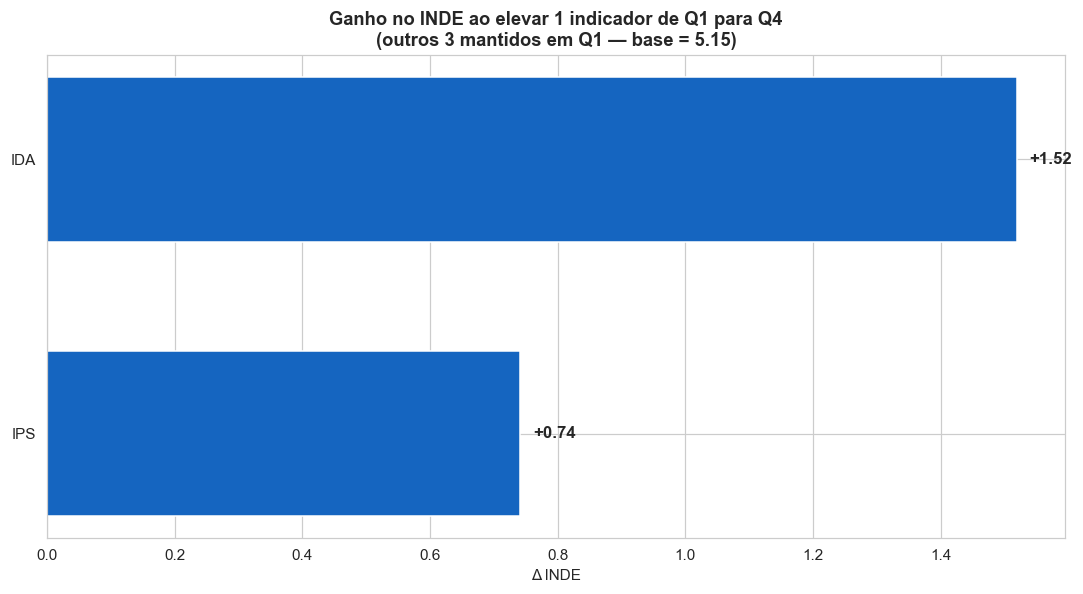

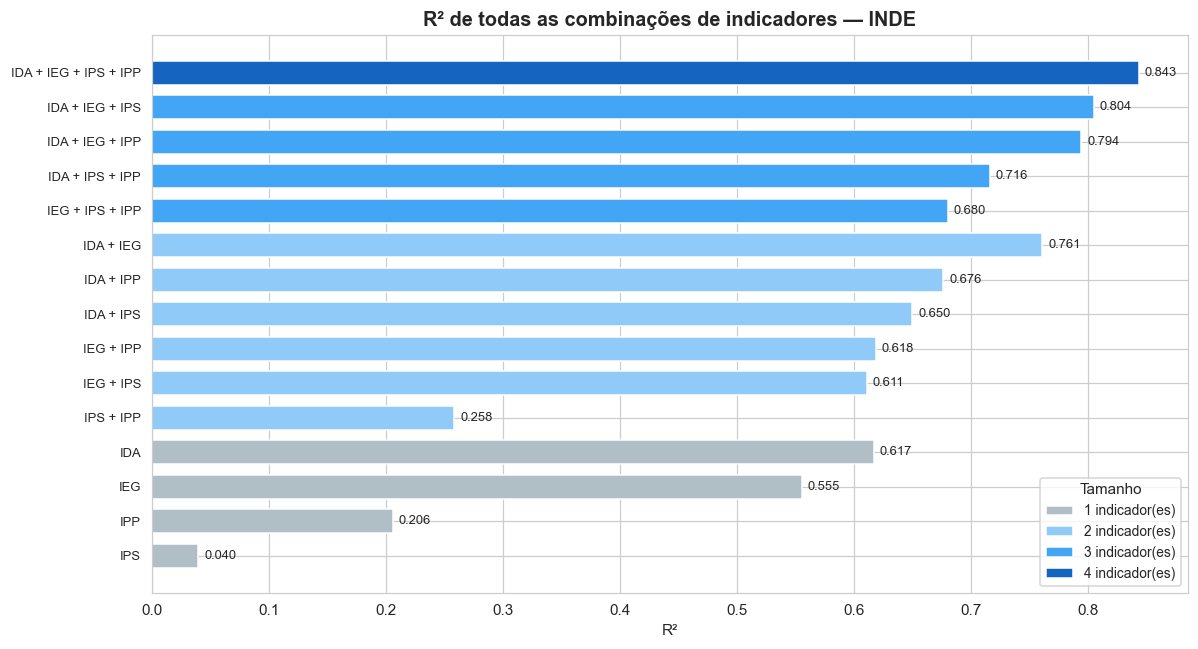


DIAGNÓSTICO — QUAIS COMBINAÇÕES ELEVAM MAIS O INDE?

▶ Combinação com maior R² (explica mais o INDE):
   IDA + IEG + IPS + IPP  →  R² = 0.8430

▶ Contribuição marginal de cada indicador (cenário 'outros em Q1'):
   IDA    ↑  →  Δ INDE = +1.52
   IPS    ↑  →  Δ INDE = +0.74

▶ Perfil de maior INDE:
   IDA↑ IEG↑ IPS↑ IPP↑  →  INDE = 8.42  (n = 332)

▶ Perfil de menor INDE:
   IDA↓ IEG↓ IPS↓ IPP↓  →  INDE = 6.00  (n = 314)

▶ Ganho total do cenário 'todos Q1' para 'todos Q4':
   5.15  →  8.74   (Δ = +3.60)

VEREDITO
→ Os indicadores que mais elevam o INDE (individualmente): IDA, IPS
→ Combinação mais eficiente: IDA + IEG + IPS + IPP
→ R² do modelo completo: 0.843 (84.3% da variância do INDE)


In [70]:
# ============================================================
# 0. Imports e carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from itertools import combinations

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

INDICADORES = ['IDA', 'IEG', 'IPS', 'IPP']
ALVO = 'INDE_ano_atual'

print(f"Base: {df.shape[0]} registros")
print(f"INDE nulos: {df[ALVO].isna().sum()}")

# Amostra completa para o alvo
df_ok = df[INDICADORES + [ALVO]].dropna().copy()
print(f"Registros com todos os indicadores + INDE: {len(df_ok)}")


# ============================================================
# 1. FÓRMULA EMPÍRICA — decomposição do INDE
# ============================================================
print("\n" + "=" * 78)
print("1. DECOMPOSIÇÃO — QUANTO CADA INDICADOR CONTRIBUI PARA O INDE")
print("=" * 78)

# Regressão linear completa (sem intercepto forçado, mas com ele)
X = sm.add_constant(df_ok[INDICADORES])
modelo = sm.OLS(df_ok[ALVO], X).fit()

print("\n▶ Coeficientes da regressão INDE ~ IDA + IEG + IPS + IPP")
coef_tab = pd.DataFrame({
    'coef': modelo.params.round(4),
    'std_err': modelo.bse.round(4),
    't': modelo.tvalues.round(2),
    'p': modelo.pvalues.round(6),
})
print(coef_tab.to_string())
print(f"\nR² = {modelo.rsquared:.4f}   "
      f"R² ajustado = {modelo.rsquared_adj:.4f}   "
      f"n = {int(modelo.nobs)}")

# Contribuição média de cada indicador ao INDE
contrib_media = {ind: (df_ok[ind].mean() * modelo.params[ind])
                 for ind in INDICADORES}
contrib_total = sum(contrib_media.values())
contrib_pct = {k: v / contrib_total * 100 for k, v in contrib_media.items()}

print("\n▶ Contribuição média ao INDE (média × coef)")
for ind in INDICADORES:
    print(f"   {ind:<6}: {contrib_media[ind]:.3f}  "
          f"({contrib_pct[ind]:.1f}% do INDE explicado)")

# Verifica se a soma dos coefs ~ 1 (é um compósito ponderado)
print(f"\n▶ Soma dos coeficientes: {modelo.params[INDICADORES].sum():.4f}")
print(f"   (se ≈ 1, o INDE é uma média ponderada desses 4 indicadores)")


# ============================================================
# 2. CORRELAÇÕES INDIVIDUAIS E ENTRE INDICADORES
# ============================================================
print("\n" + "=" * 78)
print("2. CORRELAÇÕES COM O INDE")
print("=" * 78)

corrs = df_ok[INDICADORES + [ALVO]].corr()[ALVO].drop(ALVO).round(3)
print(corrs.sort_values(ascending=False).to_string())

print("\n▶ Matriz de correlação entre os 4 indicadores:")
print(df_ok[INDICADORES].corr().round(3).to_string())


# ============================================================
# 3. ANÁLISE DE COMBINAÇÕES — TODOS OS PARES E TRINCAS
# ============================================================
print("\n" + "=" * 78)
print("3. R² DE TODAS AS COMBINAÇÕES DE INDICADORES")
print("=" * 78)

resultados = []

# Todos os subconjuntos de tamanho 1 a 4
for k in range(1, 5):
    for combo in combinations(INDICADORES, k):
        X = sm.add_constant(df_ok[list(combo)])
        m = sm.OLS(df_ok[ALVO], X).fit()
        resultados.append({
            'Combinação': ' + '.join(combo),
            'k': k,
            'R²': round(m.rsquared, 4),
            'R² ajustado': round(m.rsquared_adj, 4),
        })

res_combo = pd.DataFrame(resultados).sort_values('R²', ascending=False)
print(res_combo.to_string(index=False))


# ============================================================
# 4. ANÁLISE POR QUADRANTE — 4 INDICADORES (16 perfis possíveis)
# ============================================================
# Binariza cada indicador pela mediana
medianas = df_ok[INDICADORES].median()
df_ok['IDA_alt'] = (df_ok['IDA'] >= medianas['IDA']).astype(int)
df_ok['IEG_alt'] = (df_ok['IEG'] >= medianas['IEG']).astype(int)
df_ok['IPS_alt'] = (df_ok['IPS'] >= medianas['IPS']).astype(int)
df_ok['IPP_alt'] = (df_ok['IPP'] >= medianas['IPP']).astype(int)

# Cria um "perfil" com 4 letras (A=alto, B=baixo)
df_ok['perfil'] = (
    df_ok['IDA_alt'].map({1: 'IDA↑', 0: 'IDA↓'}) + ' ' +
    df_ok['IEG_alt'].map({1: 'IEG↑', 0: 'IEG↓'}) + ' ' +
    df_ok['IPS_alt'].map({1: 'IPS↑', 0: 'IPS↓'}) + ' ' +
    df_ok['IPP_alt'].map({1: 'IPP↑', 0: 'IPP↓'})
)

perfil_tab = (
    df_ok.groupby('perfil')
         .agg(n=(ALVO, 'size'),
              INDE_medio=(ALVO, 'mean'),
              INDE_mediana=(ALVO, 'median'))
         .round(3)
         .sort_values('INDE_medio', ascending=False)
)
perfil_tab['%_do_total'] = (perfil_tab['n'] / perfil_tab['n'].sum() * 100).round(1)

print("\n" + "=" * 78)
print("4. INDE MÉDIO POR PERFIL (16 combinações possíveis)")
print("=" * 78)
print(perfil_tab.to_string())

# Top 3 e bottom 3
print(f"\n▶ Top 3 perfis:")
for perfil in perfil_tab.head(3).index:
    print(f"   {perfil}  →  INDE médio = {perfil_tab.loc[perfil, 'INDE_medio']:.2f}  "
          f"(n = {int(perfil_tab.loc[perfil, 'n'])})")

print(f"\n▶ Bottom 3 perfis:")
for perfil in perfil_tab.tail(3).index:
    print(f"   {perfil}  →  INDE médio = {perfil_tab.loc[perfil, 'INDE_medio']:.2f}  "
          f"(n = {int(perfil_tab.loc[perfil, 'n'])})")

# Delta entre top e bottom
delta_perfil = perfil_tab['INDE_medio'].max() - perfil_tab['INDE_medio'].min()
print(f"\n▶ Δ INDE entre melhor e pior perfil: {delta_perfil:+.2f} pontos")


# ============================================================
# 5. DECOMPOSIÇÃO POR DIMENSÃO — quanto cada um agrega
# ============================================================
print("\n" + "=" * 78)
print("5. INCREMENTO DE INDE AO 'LIGAR' CADA INDICADOR")
print("=" * 78)

# Cenário: todos baixos (Q1) vs todos altos (Q4)
q25 = df_ok[INDICADORES].quantile(0.25)
q75 = df_ok[INDICADORES].quantile(0.75)

# INDE médio dos alunos com todos os indicadores no Q4
mask_all_high = (df_ok[INDICADORES] >= q75).all(axis=1)
mask_all_low  = (df_ok[INDICADORES] <= q25).all(axis=1)

inde_all_high = df_ok.loc[mask_all_high, ALVO].mean()
inde_all_low  = df_ok.loc[mask_all_low,  ALVO].mean()

print(f"▶ INDE médio com TODOS no Q4 (top 25%): {inde_all_high:.2f}  "
      f"(n = {mask_all_high.sum()})")
print(f"▶ INDE médio com TODOS no Q1 (bot 25%): {inde_all_low:.2f}  "
      f"(n = {mask_all_low.sum()})")
print(f"▶ Δ máximo (todos Q4 − todos Q1): {inde_all_high - inde_all_low:+.2f}")

# Comparação: 1 indicador no Q4, outros 3 no Q1
print("\n▶ Contribuição marginal — quanto 1 indicador 'puxa' o INDE:")
# for ind in INDICADORES:
#     outros = [x for x in INDICADORES if x != ind]
#     mask = (df_ok[ind] >= q75) & (df_ok[outros] <= q25).all(axis=1)
#     if mask.sum() >= 5:
#         inde = df_ok.loc[mask, ALVO].mean()
#         delta = inde - inde_all_low
#         print(f"   {ind:<6} ↑ enquanto outros 3 ↓  →  INDE = {inde:.2f}  "
#               f"(Δ = {delta:+.2f}, n = {mask.sum()})")
#     else:
#         print(f"   {ind:<6}: amostra insuficiente (n = {mask.sum()})")
for ind in INDICADORES:
    outros = [x for x in INDICADORES if x != ind]
    mask = (df_ok[ind] >= q75[ind]) & (df_ok[outros] <= q25[outros]).all(axis=1)
    #                   ↑ escalar                    ↑ Series com índice alinhado
    if mask.sum() >= 5:
        inde = df_ok.loc[mask, ALVO].mean()
        delta = inde - inde_all_low
        print(f"   {ind:<6} ↑ enquanto outros 3 ↓  →  INDE = {inde:.2f}  "
            f"(Δ = {delta:+.2f}, n = {mask.sum()})")
    else:
        print(f"   {ind:<6}: amostra insuficiente (n = {mask.sum()})")

# ============================================================
# 6. REGRESSÃO COM INTERAÇÕES — existe sinergia?
# ============================================================
print("\n" + "=" * 78)
print("6. INTERAÇÕES ENTRE INDICADORES")
print("=" * 78)

# Padroniza para comparar coeficientes
scaler = StandardScaler()
Z = pd.DataFrame(scaler.fit_transform(df_ok[INDICADORES]),
                 columns=INDICADORES, index=df_ok.index)

# Modelo sem interações
X_base = sm.add_constant(Z)
m_base = sm.OLS(df_ok[ALVO], X_base).fit()

# Modelo com todos os pares de interação
Z_inter = Z.copy()
for a, b in combinations(INDICADORES, 2):
    Z_inter[f'{a}_x_{b}'] = Z[a] * Z[b]

X_inter = sm.add_constant(Z_inter)
m_inter = sm.OLS(df_ok[ALVO], X_inter).fit()

print(f"R² sem interações  : {m_base.rsquared:.4f}")
print(f"R² com interações  : {m_inter.rsquared:.4f}")
print(f"Δ R² (ganho)       : {m_inter.rsquared - m_base.rsquared:+.4f}")

# Coeficientes das interações significativas
inter_coefs = pd.DataFrame({
    'coef': m_inter.params,
    'p': m_inter.pvalues
})
inter_coefs = inter_coefs[inter_coefs.index.str.contains('_x_')]
inter_coefs['abs_coef'] = inter_coefs['coef'].abs()
inter_coefs = inter_coefs.sort_values('abs_coef', ascending=False)

print("\n▶ Coeficientes das interações (ordenados por |coef|):")
print(inter_coefs.round(4).to_string())


# ============================================================
# 7. DETECÇÃO — combinação crítica para chegar ao topo do INDE
# ============================================================
print("\n" + "=" * 78)
print("7. QUAIS COMBINAÇÕES COLOCAM O ALUNO NO TOP 10% DO INDE?")
print("=" * 78)

limiar_top10 = df_ok[ALVO].quantile(0.90)
df_ok['top10'] = (df_ok[ALVO] >= limiar_top10).astype(int)
print(f"Limiar do top 10% do INDE: {limiar_top10:.2f}")

# % de alunos no top 10% dado cada combinação binária
print("\n▶ % de alunos no TOP 10% do INDE, por combinação de indicadores:")
print(f"   {'Combinação':<35} {'n':>5} {'% no top 10':>12}")
print("   " + "-" * 54)

for k in [2, 3, 4]:
    for combo in combinations(INDICADORES, k):
        cols_alt = [f'{c}_alt' for c in combo]
        mask = (df_ok[cols_alt] == 1).all(axis=1)
        if mask.sum() < 10:
            continue
        pct = df_ok.loc[mask, 'top10'].mean() * 100
        nome = ' + '.join(combo)
        print(f"   {nome:<35} {mask.sum():>5} {pct:>11.1f}%")


# ============================================================
# 8. VISUALIZAÇÃO 1 — INDE médio por perfil (top 12)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 7))

top_perfis = perfil_tab.head(12).iloc[::-1]
cores = ['#2E7D32' if 'IDA↑' in p and 'IEG↑' in p else
         '#F9A825' if 'IDA↑' in p or 'IEG↑' in p else
         '#C62828' for p in top_perfis.index]

bars = ax.barh(range(len(top_perfis)), top_perfis['INDE_medio'],
               color=cores, edgecolor='white', height=0.7)

for i, (b, v, n) in enumerate(zip(bars, top_perfis['INDE_medio'],
                                  top_perfis['n'])):
    ax.text(v + 0.05, b.get_y() + b.get_height()/2,
            f"{v:.2f} (n={int(n)})", va='center', fontsize=9,
            fontweight='bold')

ax.set_yticks(range(len(top_perfis)))
ax.set_yticklabels(top_perfis.index, fontsize=9)
ax.axvline(df_ok[ALVO].mean(), color='black', linestyle='--',
           linewidth=1.5, label=f'Média geral ({df_ok[ALVO].mean():.2f})')
ax.set_title('INDE médio por perfil (top 12 combinações)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('INDE médio')
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 2 — Heatmap de interação 2×2
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
pares = list(combinations(INDICADORES, 2))

for ax, (a, b) in zip(axes.flat, pares):
    piv = df_ok.pivot_table(
        index=f'{a}_alt',
        columns=f'{b}_alt',
        values=ALVO,
        aggfunc='mean'
    )
    piv.index   = [f'{a} baixo', f'{a} alto']
    piv.columns = [f'{b} baixo', f'{b} alto']

    sns.heatmap(piv, annot=True, fmt='.2f', cmap='RdYlGn',
                vmin=df_ok[ALVO].min(), vmax=df_ok[ALVO].max(),
                linewidths=0.8, cbar=False, ax=ax,
                annot_kws={'size': 11, 'weight': 'bold'})
    ax.set_title(f'{a} × {b}', fontsize=12, fontweight='bold')

# Remove subplot vazio se houver
for i in range(len(pares), 6):
    axes.flat[i].axis('off')

plt.suptitle('INDE médio por combinação 2×2 de indicadores (corte = mediana)',
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ============================================================
# 10. VISUALIZAÇÃO 3 — Contribuição marginal de cada indicador
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

increments = {}
for ind in INDICADORES:
    outros = [x for x in INDICADORES if x != ind]
    mask = (df_ok[ind] >= q75[ind]) & (df_ok[outros] <= q25[outros]).all(axis=1)
    if mask.sum() >= 5:
        increments[ind] = df_ok.loc[mask, ALVO].mean() - inde_all_low

increments = pd.Series(increments).sort_values(ascending=True)

cores_bar = ['#1565C0' if v >= 0 else '#C62828' for v in increments]
bars = ax.barh(increments.index, increments.values,
               color=cores_bar, edgecolor='white', height=0.6)

for b, v in zip(bars, increments.values):
    ax.text(v + 0.02, b.get_y() + b.get_height()/2,
            f"{v:+.2f}", va='center', fontsize=11, fontweight='bold')

ax.axvline(0, color='black', linewidth=1)
ax.set_title(f'Ganho no INDE ao elevar 1 indicador de Q1 para Q4\n'
             f'(outros 3 mantidos em Q1 — base = {inde_all_low:.2f})',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Δ INDE')
plt.tight_layout()
plt.show()


# ============================================================
# 11. VISUALIZAÇÃO 4 — R² por combinação
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

res_plot = res_combo.sort_values(['k', 'R²'])
res_plot['label'] = res_plot['Combinação']
cores_k = {1: '#B0BEC5', 2: '#90CAF9', 3: '#42A5F5', 4: '#1565C0'}
cores_b = [cores_k[k] for k in res_plot['k']]

bars = ax.barh(range(len(res_plot)), res_plot['R²'],
               color=cores_b, edgecolor='white', height=0.7)

for i, (b, v, k) in enumerate(zip(bars, res_plot['R²'], res_plot['k'])):
    ax.text(v + 0.005, b.get_y() + b.get_height()/2,
            f"{v:.3f}", va='center', fontsize=8.5)

ax.set_yticks(range(len(res_plot)))
ax.set_yticklabels(res_plot['label'], fontsize=8.5)
ax.set_title('R² de todas as combinações de indicadores — INDE',
             fontsize=13, fontweight='bold')
ax.set_xlabel('R²')

from matplotlib.patches import Patch
leg = [Patch(facecolor=cores_k[k], label=f'{k} indicador(es)') for k in [1,2,3,4]]
ax.legend(handles=leg, title='Tamanho', loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


# ============================================================
# 12. DIAGNÓSTICO FINAL
# ============================================================
print("\n" + "=" * 78)
print("DIAGNÓSTICO — QUAIS COMBINAÇÕES ELEVAM MAIS O INDE?")
print("=" * 78)

print("\n▶ Combinação com maior R² (explica mais o INDE):")
top_combo = res_combo.iloc[0]
print(f"   {top_combo['Combinação']}  →  R² = {top_combo['R²']:.4f}")

print("\n▶ Contribuição marginal de cada indicador (cenário 'outros em Q1'):")
for ind, v in increments.sort_values(ascending=False).items():
    print(f"   {ind:<6} ↑  →  Δ INDE = {v:+.2f}")

print("\n▶ Perfil de maior INDE:")
print(f"   {perfil_tab.index[0]}  →  INDE = {perfil_tab['INDE_medio'].iloc[0]:.2f}  "
      f"(n = {int(perfil_tab['n'].iloc[0])})")

print("\n▶ Perfil de menor INDE:")
print(f"   {perfil_tab.index[-1]}  →  INDE = {perfil_tab['INDE_medio'].iloc[-1]:.2f}  "
      f"(n = {int(perfil_tab['n'].iloc[-1])})")

print("\n▶ Ganho total do cenário 'todos Q1' para 'todos Q4':")
print(f"   {inde_all_low:.2f}  →  {inde_all_high:.2f}   "
      f"(Δ = {inde_all_high - inde_all_low:+.2f})")

print("\n" + "=" * 78)
print("VEREDITO")
print("=" * 78)

top_ind = increments.sort_values(ascending=False).index[:3].tolist()
print(f"→ Os indicadores que mais elevam o INDE (individualmente): "
      f"{', '.join(top_ind)}")
print(f"→ Combinação mais eficiente: {top_combo['Combinação']}")
print(f"→ R² do modelo completo: {modelo.rsquared:.3f} "
      f"({modelo.rsquared*100:.1f}% da variância do INDE)")

# 9. Previsão de risco com Machine Learning
Quais padrões nos indicadores permitem identificar alunos em risco antes 
de queda no desempenho ou aumento da defasagem? Construa um modelo 
preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de 
defasagem.

A analise e construção do modelode de Machine Learning estão no primeiro notebook "dataton".

# 10. Efetividade do programa
Os indicadores mostram melhora consistente ao longo do ciclo nas 
diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto 
real do programa?

Os dados de evolução dentro das categorias dentro desse limite do dataset de 3 anos não parece ter um perfil de estagnação, plana. Sem tendencia a mudanças.

Em alguns cenários pode se observar o crescimento da categoria mais alta, mas ao mesmo tempo se observa o crescimento da categoria mais baixa.

Base: 2845 registros

1. CALIBRAÇÃO — INDE MÉDIO POR PEDRA E ANO
ano              2022  2023  2024
pedra_ano_atual                  
Quartzo          5.35  5.64  5.49
Ágata            6.64  6.61  6.65
Ametista         7.50  7.51  7.53
Topázio          8.34  8.44  8.47

2. DISTRIBUIÇÃO GERAL POR PEDRA E ANO (NÃO CONTROLA PERMANÊNCIA)
pedra_ano_atual  Quartzo  Ágata  Ametista  Topázio  Total
ano                                                      
2022                 153    221       344      142    860
2023                  89    229       381      232    931
2024                 129    208       391      326   1054
Total                371    658      1116      700   2845

⚠️ ATENÇÃO: a tabela acima mistura alunos novos, antigos e evadidos.
   Para avaliar EFETIVIDADE, é preciso olhar apenas quem PERMANECEU.

MATRIZ DE TRANSIÇÃO — 2022 → 2023  (n = 570 alunos que permaneceram)
para      Quartzo  Ágata  Ametista  Topázio
de                                         
Quartzo        22   

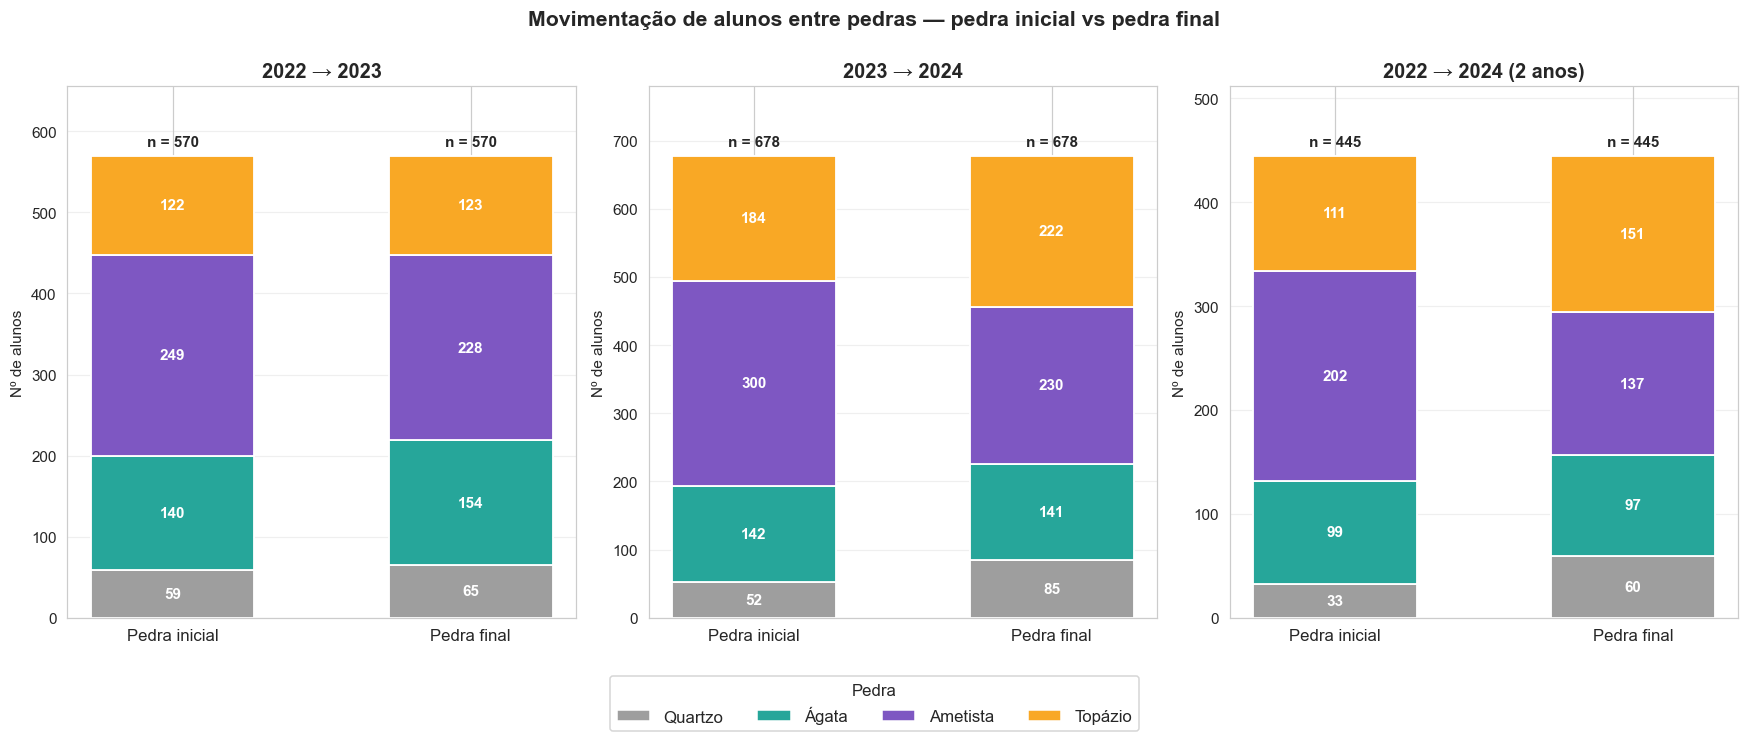

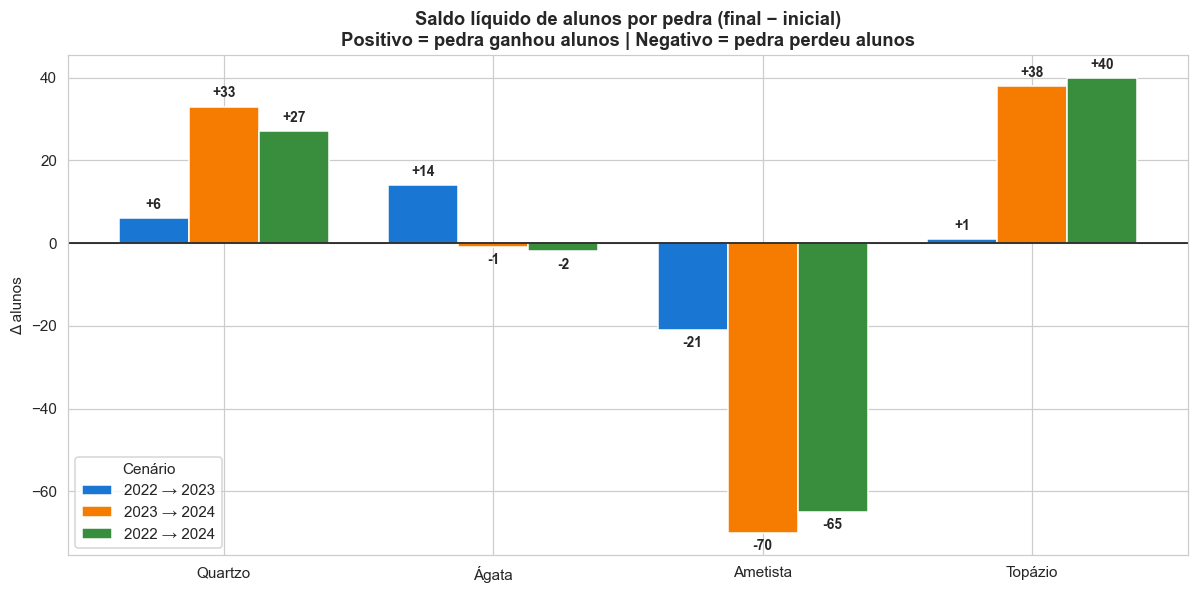


8. DIAGNÓSTICO — MUDANÇA DE PEDRA = MUDANÇA REAL DE INDE?

▶ Δ INDE contínuo por tipo de movimento de pedra (2022 → 2024):
                  n  delta_medio  delta_std
movimento                                  
Caiu 1 pedra     88       -0.826      0.506
Caiu 2 pedras    28       -1.738      0.542
Caiu 3 pedras     2       -3.666      0.329
Manteve         204        0.081      0.412
Subiu 1 pedra   108        0.798      0.371
Subiu 2 pedras   15        1.770      0.705

▶ Alunos que mudaram de pedra em 2 anos: 241
   Δ INDE médio: -0.066
   % com |Δ INDE| < 0,2 (ruído de fronteira): 3.7%
   % com 0,2 ≤ |Δ INDE| ≤ 0,5 (mudança intermediária): 16.2%
   % com |Δ INDE| > 0,5 (mudança real): 80.1%


C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\3652688815.py:305: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=par_2224_inde.assign(


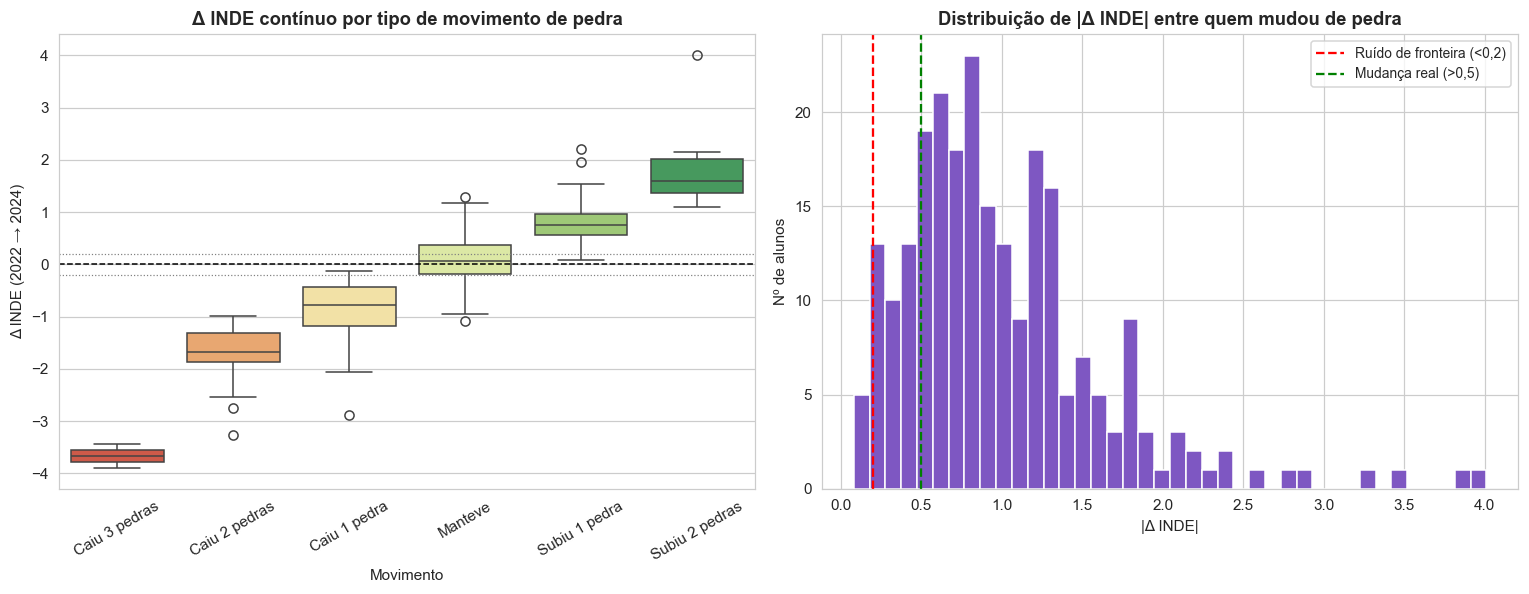


10. TRAJETÓRIA DO INDE — ALUNOS PRESENTES EM 2022, 2023 E 2024
Alunos nos 3 anos: 434

▶ INDE médio por ano:
ano
2022    7.379
2023    7.349
2024    7.376

▶ Δ INDE:
   2022 → 2023: -0.029
   2023 → 2024: +0.027
   2022 → 2024: -0.003

▶ % que subiu INDE nos 2 intervalos consecutivos: 22.1%
▶ % que desceu INDE nos 2 intervalos consecutivos: 17.1%
▶ % com INDE maior em 2024 vs 2022: 55.3%

11. TESTES — INDE MUDOU ENTRE ANOS? (Wilcoxon pareado)
   📉 2022 → 2023: Δ = -0.029  W = 45606  p = 0.54271  ×
   📈 2023 → 2024: Δ = +0.027  W = 42276  p = 0.05979  ×
   📉 2022 → 2024: Δ = -0.003  W = 43916  p = 0.20944  ×


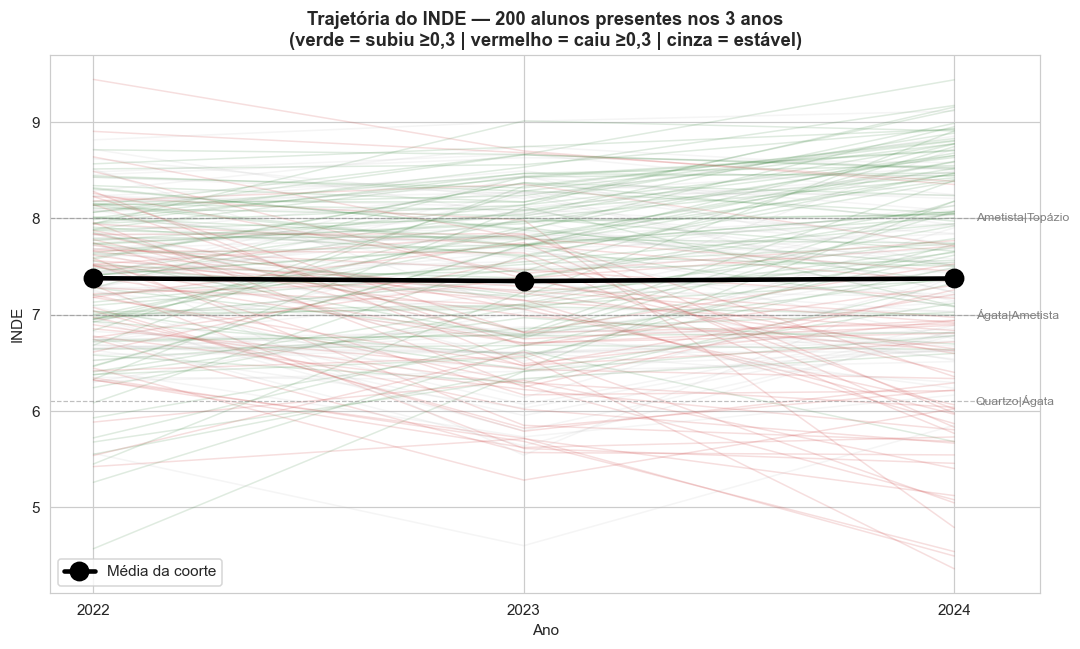


13. DIAGNÓSTICO FINAL — O PROGRAMA MOSTRA IMPACTO REAL?

▶ Movimentação líquida entre pedras (alunos que permaneceram):
   2022 → 2023: 3 pedra(s) com saldo positivo, 1 com saldo negativo
      Quartzo   : +6
      Ágata     : +14
      Ametista  : -21
      Topázio   : +1
   2023 → 2024: 2 pedra(s) com saldo positivo, 2 com saldo negativo
      Quartzo   : +33
      Ágata     : -1
      Ametista  : -70
      Topázio   : +38
   2022 → 2024: 2 pedra(s) com saldo positivo, 2 com saldo negativo
      Quartzo   : +27
      Ágata     : -2
      Ametista  : -65
      Topázio   : +40

▶ Trajetória do INDE dos 434 alunos presentes nos 3 anos:
   2022: 7.379
   2023: 7.349
   2024: 7.376
   Δ 2022 → 2024: -0.003

▶ Diagnóstico de ruído de fronteira:
   Dos 241 alunos que mudaram de pedra: 3.7% com |Δ INDE| < 0,2

VEREDITO
→ INDE médio: ESTAGNADO  (Δ = -0.003)
→ Movimento entre pedras: MUDANÇA REAL DE CATEGORIA

→ ❌ SEM EVIDÊNCIA DE IMPACTO REAL DO PROGRAMA.
   O INDE dos alunos acompanhados no

In [77]:
# ============================================================
# 0. IMPORTS E CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

# Corrige o erro de digitação do notebook original
df['pedra_ano_atual'] = df['pedra_ano_atual'].replace({'Amestista': 'Ametista'})

ORDEM_PEDRAS = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
CORES_PEDRAS = {
    'Quartzo':  '#9E9E9E',
    'Ágata':    '#26A69A',
    'Ametista': '#7E57C2',
    'Topázio':  '#F9A825',
}

df['pedra_ano_atual'] = pd.Categorical(df['pedra_ano_atual'],
                                       categories=ORDEM_PEDRAS, ordered=True)

print(f"Base: {df.shape[0]} registros")


# ============================================================
# 1. CALIBRAÇÃO DAS FAIXAS — o critério de pedra mudou entre anos?
# ============================================================
print("\n" + "=" * 78)
print("1. CALIBRAÇÃO — INDE MÉDIO POR PEDRA E ANO")
print("=" * 78)

inde_pedra = (
    df.pivot_table(index='pedra_ano_atual', columns='ano',
                   values='INDE_ano_atual', aggfunc='mean', observed=True)
      .round(2)
)
print(inde_pedra.to_string())

# Se as médias estiverem estáveis (~5,5 / ~6,6 / ~7,5 / ~8,4), as faixas
# mantêm significado. Caso contrário, comparações entre anos perdem validade.


# ============================================================
# 2. DISTRIBUIÇÃO GERAL — com alerta de composição
# ============================================================
print("\n" + "=" * 78)
print("2. DISTRIBUIÇÃO GERAL POR PEDRA E ANO (NÃO CONTROLA PERMANÊNCIA)")
print("=" * 78)

dist_ano = pd.crosstab(df['ano'], df['pedra_ano_atual'])
dist_ano['Total'] = dist_ano.sum(axis=1)
dist_ano.loc['Total'] = dist_ano.sum(axis=0)
print(dist_ano.to_string())

print("\n⚠️ ATENÇÃO: a tabela acima mistura alunos novos, antigos e evadidos.")
print("   Para avaliar EFETIVIDADE, é preciso olhar apenas quem PERMANECEU.")


# ============================================================
# 3. PIVOTS RA × ANO
# ============================================================
def pivot_wide(col):
    return df.pivot_table(index='RA', columns='ano',
                          values=col, aggfunc='last')

piv_pedra = pivot_wide('pedra_ano_atual')
piv_inde  = pivot_wide('INDE_ano_atual')


# ============================================================
# 4. MATRIZ DE TRANSIÇÃO — APENAS ALUNOS QUE PERMANECERAM
#    Por construção, alunos novos e evadidos são excluídos.
#    → Hipóteses de "efeito de entrada" ou "evasão" NÃO se aplicam.
# ============================================================
def matriz_transicao(t_de, t_para, label):
    par = pd.DataFrame({
        'de': piv_pedra[t_de],
        'para': piv_pedra[t_para],
    }).dropna()

    for col in ['de', 'para']:
        par[col] = pd.Categorical(par[col], categories=ORDEM_PEDRAS, ordered=True)

    tab = pd.crosstab(par['de'], par['para'])
    tab = tab.reindex(index=ORDEM_PEDRAS, columns=ORDEM_PEDRAS, fill_value=0)

    tab_pct = pd.crosstab(par['de'], par['para'], normalize='index') * 100
    tab_pct = tab_pct.reindex(index=ORDEM_PEDRAS, columns=ORDEM_PEDRAS,
                              fill_value=0).round(1)

    print(f"\n" + "=" * 78)
    print(f"MATRIZ DE TRANSIÇÃO — {label}  (n = {len(par)} alunos que permaneceram)")
    print("=" * 78)
    print(tab.to_string())
    print(f"\n% dentro da pedra de origem:")
    print(tab_pct.to_string())

    return par, tab, tab_pct


par_2223, tab_2223, pct_2223 = matriz_transicao(2022, 2023, '2022 → 2023')
par_2324, tab_2324, pct_2324 = matriz_transicao(2023, 2024, '2023 → 2024')
par_2224, tab_2224, pct_2224 = matriz_transicao(2022, 2024, '2022 → 2024 (salto de 2 anos)')


# ============================================================
# 5. MOVIMENTAÇÃO LÍQUIDA — GANHO / ESTÁVEL / PERDA POR PEDRA
#    Vocabulário neutro: "ganho líquido de alunos" e "perda líquida"
# ============================================================
def saldo_por_pedra(par):
    """Saldo líquido de alunos por pedra (final − inicial)."""
    de   = par['de'].value_counts().reindex(ORDEM_PEDRAS, fill_value=0)
    para = par['para'].value_counts().reindex(ORDEM_PEDRAS, fill_value=0)
    return (para - de).rename('saldo')


print("\n" + "=" * 78)
print("5. SALDO LÍQUIDO DE ALUNOS POR PEDRA (final − inicial)")
print("=" * 78)

saldo_2223 = saldo_por_pedra(par_2223)
saldo_2324 = saldo_por_pedra(par_2324)
saldo_2224 = saldo_por_pedra(par_2224)

saldo_tab = pd.DataFrame({
    '2022 → 2023': saldo_2223,
    '2023 → 2024': saldo_2324,
    '2022 → 2024': saldo_2224,
})
print(saldo_tab.to_string())


# ============================================================
# 6. VISUALIZAÇÃO 1 — PEDRA INICIAL vs PEDRA FINAL (barras empilhadas)
#    Retrato visual do fluxo bruto em cada cenário
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 6.5))

cenarios = [
    (par_2223, '2022 → 2023'),
    (par_2324, '2023 → 2024'),
    (par_2224, '2022 → 2024 (2 anos)'),
]

for ax, (par, titulo) in zip(axes, cenarios):
    cont_de   = par['de'].value_counts().reindex(ORDEM_PEDRAS, fill_value=0)
    cont_para = par['para'].value_counts().reindex(ORDEM_PEDRAS, fill_value=0)
    n_total   = len(par)
    bottom_de, bottom_para = 0, 0

    for pedra in ORDEM_PEDRAS:
        cor = CORES_PEDRAS[pedra]

        # Coluna inicial
        h = cont_de[pedra]
        ax.bar(0, h, bottom=bottom_de, color=cor, edgecolor='white',
               linewidth=1.2, width=0.55)
        if h > 15:
            ax.text(0, bottom_de + h/2, f"{h}", ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        bottom_de += h

        # Coluna final
        h = cont_para[pedra]
        ax.bar(1, h, bottom=bottom_para, color=cor, edgecolor='white',
               linewidth=1.2, width=0.55)
        if h > 15:
            ax.text(1, bottom_para + h/2, f"{h}", ha='center', va='center',
                    fontsize=10, fontweight='bold', color='white')
        bottom_para += h

    ax.text(0, n_total * 1.02, f"n = {n_total}", ha='center',
            fontsize=10, fontweight='bold')
    ax.text(1, n_total * 1.02, f"n = {n_total}", ha='center',
            fontsize=10, fontweight='bold')

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pedra inicial', 'Pedra final'], fontsize=11)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_ylabel('Nº de alunos')
    ax.set_ylim(0, n_total * 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)

handles = [Patch(facecolor=CORES_PEDRAS[p], edgecolor='white', label=p)
           for p in ORDEM_PEDRAS]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=11,
           frameon=True, bbox_to_anchor=(0.5, -0.02),
           title='Pedra', title_fontsize=11)

fig.suptitle('Movimentação de alunos entre pedras — pedra inicial vs pedra final',
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()


# ============================================================
# 7. VISUALIZAÇÃO 2 — SALDO LÍQUIDO POR PEDRA
# ============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

x = np.arange(len(ORDEM_PEDRAS))
w = 0.26
cores_cenario = {'2022 → 2023': '#1976D2',
                 '2023 → 2024': '#F57C00',
                 '2022 → 2024': '#388E3C'}

for i, col in enumerate(saldo_tab.columns):
    vals = saldo_tab[col].values
    bars = ax.bar(x + (i-1)*w, vals, width=w,
                  color=cores_cenario[col], edgecolor='white',
                  label=col)
    for b, v in zip(bars, vals):
        offset = 1.5 if v >= 0 else -1.5
        ax.text(b.get_x() + b.get_width()/2, v + offset, f"{v:+d}",
                ha='center', va='bottom' if v >= 0 else 'top',
                fontsize=9, fontweight='bold')

ax.axhline(0, color='black', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(ORDEM_PEDRAS)
ax.set_title('Saldo líquido de alunos por pedra (final − inicial)\n'
             'Positivo = pedra ganhou alunos | Negativo = pedra perdeu alunos',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Δ alunos')
ax.legend(title='Cenário')
plt.tight_layout()
plt.show()


# ============================================================
# 8. DIAGNÓSTICO — a mudança de pedra reflete mudança real no INDE?
#    Discrimina entre: (a) mudança real, (b) ruído de fronteira,
#    (c) instabilidade do indicador
# ============================================================
print("\n" + "=" * 78)
print("8. DIAGNÓSTICO — MUDANÇA DE PEDRA = MUDANÇA REAL DE INDE?")
print("=" * 78)

mapa_num = {p: i for i, p in enumerate(ORDEM_PEDRAS)}

par_2224_inde = pd.DataFrame({
    'inde_22':  piv_inde[2022],
    'inde_24':  piv_inde[2024],
    'pedra_22': piv_pedra[2022],
    'pedra_24': piv_pedra[2024],
}).dropna()

par_2224_inde['de_num']     = par_2224_inde['pedra_22'].astype(str).map(mapa_num)
par_2224_inde['para_num']   = par_2224_inde['pedra_24'].astype(str).map(mapa_num)
par_2224_inde['delta_pedra'] = par_2224_inde['para_num'] - par_2224_inde['de_num']
par_2224_inde['delta_inde']  = par_2224_inde['inde_24'] - par_2224_inde['inde_22']

# Δ INDE médio por tipo de movimento
print("\n▶ Δ INDE contínuo por tipo de movimento de pedra (2022 → 2024):")
resumo_mov = (
    par_2224_inde
      .assign(movimento=par_2224_inde['delta_pedra'].map({
          -3: 'Caiu 3 pedras', -2: 'Caiu 2 pedras', -1: 'Caiu 1 pedra',
           0: 'Manteve',         1: 'Subiu 1 pedra', 2: 'Subiu 2 pedras',
           3: 'Subiu 3 pedras'}))
      .groupby('movimento')['delta_inde']
      .agg(n='size', delta_medio='mean', delta_std='std')
      .round(3)
)
print(resumo_mov.to_string())

# Quem mudou de pedra: o INDE mudou o suficiente?
mudou = par_2224_inde[par_2224_inde['delta_pedra'] != 0]
n_mudou = len(mudou)

pct_ruido = (mudou['delta_inde'].abs() < 0.2).mean() * 100
pct_real  = (mudou['delta_inde'].abs() > 0.5).mean() * 100
pct_medio = ((mudou['delta_inde'].abs() >= 0.2) &
             (mudou['delta_inde'].abs() <= 0.5)).mean() * 100

print(f"\n▶ Alunos que mudaram de pedra em 2 anos: {n_mudou}")
print(f"   Δ INDE médio: {mudou['delta_inde'].mean():+.3f}")
print(f"   % com |Δ INDE| < 0,2 (ruído de fronteira): {pct_ruido:.1f}%")
print(f"   % com 0,2 ≤ |Δ INDE| ≤ 0,5 (mudança intermediária): {pct_medio:.1f}%")
print(f"   % com |Δ INDE| > 0,5 (mudança real): {pct_real:.1f}%")


# ============================================================
# 9. VISUALIZAÇÃO 3 — Δ INDE por tipo de movimento
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 9.1 Boxplot Δ INDE por movimento de pedra
ordem_mov = ['Caiu 3 pedras', 'Caiu 2 pedras', 'Caiu 1 pedra',
             'Manteve', 'Subiu 1 pedra', 'Subiu 2 pedras', 'Subiu 3 pedras']
presentes = [m for m in ordem_mov if m in resumo_mov.index]

sns.boxplot(data=par_2224_inde.assign(
                movimento=par_2224_inde['delta_pedra'].map({
                    -3: 'Caiu 3 pedras', -2: 'Caiu 2 pedras', -1: 'Caiu 1 pedra',
                     0: 'Manteve',         1: 'Subiu 1 pedra', 2: 'Subiu 2 pedras',
                     3: 'Subiu 3 pedras'})),
            x='movimento', y='delta_inde', order=presentes,
            palette='RdYlGn', ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].axhline(0.2, color='gray', linewidth=0.8, linestyle=':')
axes[0].axhline(-0.2, color='gray', linewidth=0.8, linestyle=':')
axes[0].set_title('Δ INDE contínuo por tipo de movimento de pedra',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Movimento')
axes[0].set_ylabel('Δ INDE (2022 → 2024)')
axes[0].tick_params(axis='x', rotation=30)

# 9.2 Distribuição de |Δ INDE| de quem mudou de pedra
axes[1].hist(mudou['delta_inde'].abs(), bins=40,
             color='#7E57C2', edgecolor='white')
axes[1].axvline(0.2, color='red', linewidth=1.5, linestyle='--',
                label='Ruído de fronteira (<0,2)')
axes[1].axvline(0.5, color='green', linewidth=1.5, linestyle='--',
                label='Mudança real (>0,5)')
axes[1].set_title('Distribuição de |Δ INDE| entre quem mudou de pedra',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('|Δ INDE|')
axes[1].set_ylabel('Nº de alunos')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


# ============================================================
# 10. TRAJETÓRIA DO INDE — ALUNOS PRESENTES NOS 3 ANOS
# ============================================================
print("\n" + "=" * 78)
print("10. TRAJETÓRIA DO INDE — ALUNOS PRESENTES EM 2022, 2023 E 2024")
print("=" * 78)

anos_por_ra = df.groupby('RA')['ano'].nunique()
ras_3anos = anos_por_ra[anos_por_ra == 3].index

df_3 = df[df['RA'].isin(ras_3anos)].copy()
traj = df_3.pivot_table(index='RA', columns='ano',
                        values='INDE_ano_atual', aggfunc='mean')
traj['delta_22_23'] = traj[2023] - traj[2022]
traj['delta_23_24'] = traj[2024] - traj[2023]
traj['delta_22_24'] = traj[2024] - traj[2022]

print(f"Alunos nos 3 anos: {len(traj)}")
print(f"\n▶ INDE médio por ano:")
print(traj[[2022, 2023, 2024]].mean().round(3).to_string())

print(f"\n▶ Δ INDE:")
print(f"   2022 → 2023: {traj['delta_22_23'].mean():+.3f}")
print(f"   2023 → 2024: {traj['delta_23_24'].mean():+.3f}")
print(f"   2022 → 2024: {traj['delta_22_24'].mean():+.3f}")

consistente_up   = ((traj['delta_22_23'] > 0) & (traj['delta_23_24'] > 0)).mean() * 100
consistente_down = ((traj['delta_22_23'] < 0) & (traj['delta_23_24'] < 0)).mean() * 100
total_up         = (traj['delta_22_24'] > 0).mean() * 100

print(f"\n▶ % que subiu INDE nos 2 intervalos consecutivos: {consistente_up:.1f}%")
print(f"▶ % que desceu INDE nos 2 intervalos consecutivos: {consistente_down:.1f}%")
print(f"▶ % com INDE maior em 2024 vs 2022: {total_up:.1f}%")


# ============================================================
# 11. TESTES ESTATÍSTICOS — Wilcoxon pareado
# ============================================================
print("\n" + "=" * 78)
print("11. TESTES — INDE MUDOU ENTRE ANOS? (Wilcoxon pareado)")
print("=" * 78)

resultados_w = []
for (t1, t2) in [(2022, 2023), (2023, 2024), (2022, 2024)]:
    sub = traj[[t1, t2]].dropna()
    if len(sub) < 20:
        continue
    stat, p = stats.wilcoxon(sub[t1], sub[t2])
    delta = (sub[t2] - sub[t1]).mean()
    sinal = '📈' if delta > 0 else '📉'
    sig = '✓' if p < 0.05 else '×'
    print(f"   {sinal} {t1} → {t2}: Δ = {delta:+.3f}  W = {stat:.0f}  "
          f"p = {p:.5f}  {sig}")
    resultados_w.append({'transicao': f'{t1}→{t2}', 'delta': delta, 'p': p})


# ============================================================
# 12. VISUALIZAÇÃO 4 — Trajetória individual (slope plot)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

amostra = traj.dropna(subset=[2022, 2023, 2024]).sample(
    min(200, len(traj)), random_state=42)

for _, row in amostra.iterrows():
    delta = row[2024] - row[2022]
    cor = '#2E7D32' if delta > 0.3 else '#C62828' if delta < -0.3 else '#BDBDBD'
    ax.plot([2022, 2023, 2024], [row[2022], row[2023], row[2024]],
            color=cor, alpha=0.15, linewidth=1)

for y, nome in [(6.1, 'Quartzo|Ágata'),
                (7.0, 'Ágata|Ametista'),
                (8.0, 'Ametista|Topázio')]:
    ax.axhline(y, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.text(2024.05, y, nome, fontsize=8, va='center', color='gray')

medias = traj[[2022, 2023, 2024]].mean()
ax.plot([2022, 2023, 2024], medias.values, color='black',
        marker='o', linewidth=3, markersize=12, label='Média da coorte')

ax.set_title(f'Trajetória do INDE — {len(amostra)} alunos presentes nos 3 anos\n'
             f'(verde = subiu ≥0,3 | vermelho = caiu ≥0,3 | cinza = estável)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('INDE')
ax.set_xticks([2022, 2023, 2024])
ax.set_xlim(2021.9, 2024.2)
ax.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 13. DIAGNÓSTICO FINAL — veredito consolidado
# ============================================================
print("\n" + "=" * 78)
print("13. DIAGNÓSTICO FINAL — O PROGRAMA MOSTRA IMPACTO REAL?")
print("=" * 78)

print("\n▶ Movimentação líquida entre pedras (alunos que permaneceram):")
for cen, saldo in [('2022 → 2023', saldo_2223),
                   ('2023 → 2024', saldo_2324),
                   ('2022 → 2024', saldo_2224)]:
    subiu = (saldo > 0).sum()
    desceu = (saldo < 0).sum()
    print(f"   {cen}: {subiu} pedra(s) com saldo positivo, "
          f"{desceu} com saldo negativo")
    for p in ORDEM_PEDRAS:
        print(f"      {p:<10}: {saldo[p]:+d}")

print(f"\n▶ Trajetória do INDE dos 434 alunos presentes nos 3 anos:")
print(f"   2022: {traj[2022].mean():.3f}")
print(f"   2023: {traj[2023].mean():.3f}")
print(f"   2024: {traj[2024].mean():.3f}")
print(f"   Δ 2022 → 2024: {traj['delta_22_24'].mean():+.3f}")

print(f"\n▶ Diagnóstico de ruído de fronteira:")
print(f"   Dos {n_mudou} alunos que mudaram de pedra: "
      f"{pct_ruido:.1f}% com |Δ INDE| < 0,2")

print("\n" + "=" * 78)
print("VEREDITO")
print("=" * 78)

delta_inde = traj['delta_22_24'].mean()
saldo_total = saldo_2224.sum()  # soma dos saldos absolutos (deve ser 0)

# Natureza do movimento
mudou_pouco = pct_ruido > 50

# 1. INDE médio estagnado?
if abs(delta_inde) < 0.05:
    diag_inde = "ESTAGNADO"
elif delta_inde > 0.1:
    diag_inde = "MELHORANDO"
else:
    diag_inde = "PIORANDO"

# 2. Movimento de pedras é real ou ruído?
if mudou_pouco:
    diag_mov = "RUÍDO DE FRONTEIRA (a maioria das mudanças é < 0,2 no INDE)"
else:
    diag_mov = "MUDANÇA REAL DE CATEGORIA"

print(f"→ INDE médio: {diag_inde}  (Δ = {delta_inde:+.3f})")
print(f"→ Movimento entre pedras: {diag_mov}")
print()

if diag_inde == "ESTAGNADO":
    print("→ ❌ SEM EVIDÊNCIA DE IMPACTO REAL DO PROGRAMA.")
    print("   O INDE dos alunos acompanhados nos 3 anos é estatisticamente plano.")
    print("   As mudanças de pedra refletem, em sua maioria, oscilações pequenas")
    print("   do INDE em torno dos limiares (6,1 / 7,0 / 8,0), não progressão real.")
elif diag_inde == "MELHORANDO":
    print("→ ✅ EVIDÊNCIA DE IMPACTO POSITIVO DO PROGRAMA.")
else:
    print("→ ⚠️ EVIDÊNCIA DE PIORA.")

# 11. Insights e criatividade
Você pode adicionar mais insights e pontos de vista não abordados nas 
perguntas, utilize a criatividade e a análise dos dados para trazer sugestões para 
a Passos Mágicos.

Fase 2 e 3, apresentam um pico na descontinuidade nos dados, o que pode se referir a evasão nesses periodos. O maior indicativo dessas descontinuidades são os indicadores acadêmicos (IDA), isso pode indicar a possibilidade de uma verificação e um plano de ação para a retenção desses alunos no programa.

Base: 2845 registros
RAs únicos: 1586

1. CLASSIFICAÇÃO DE TODOS OS RAs POR ÚLTIMO ANO NA BASE
status
Retido (em 2024)    1054
Saída após 2022      279
Saída após 2023      253

▶ Cruzamento status × tipo de saída:
tipo_saida        Retido  Saída antes da fase final  Saída na fase final (conclusão?)  Total
status                                                                                      
Retido (em 2024)    1054                          0                                 0   1054
Saída após 2022        0                        228                                51    279
Saída após 2023        0                        212                                41    253
Total               1054                        440                                92   1586

2. ALUNOS QUE SAÍRAM — SEPARADOS POR COORTE DE SAÍDA

▶ Saída após 2022: 279 alunos

   Distribuição por fase de saída:
      ALFA      :  15 (  5.4%)
      Fase 1    :  24 (  8.6%)
      Fase 2    :  52 ( 18.6%)
      Fase 3 

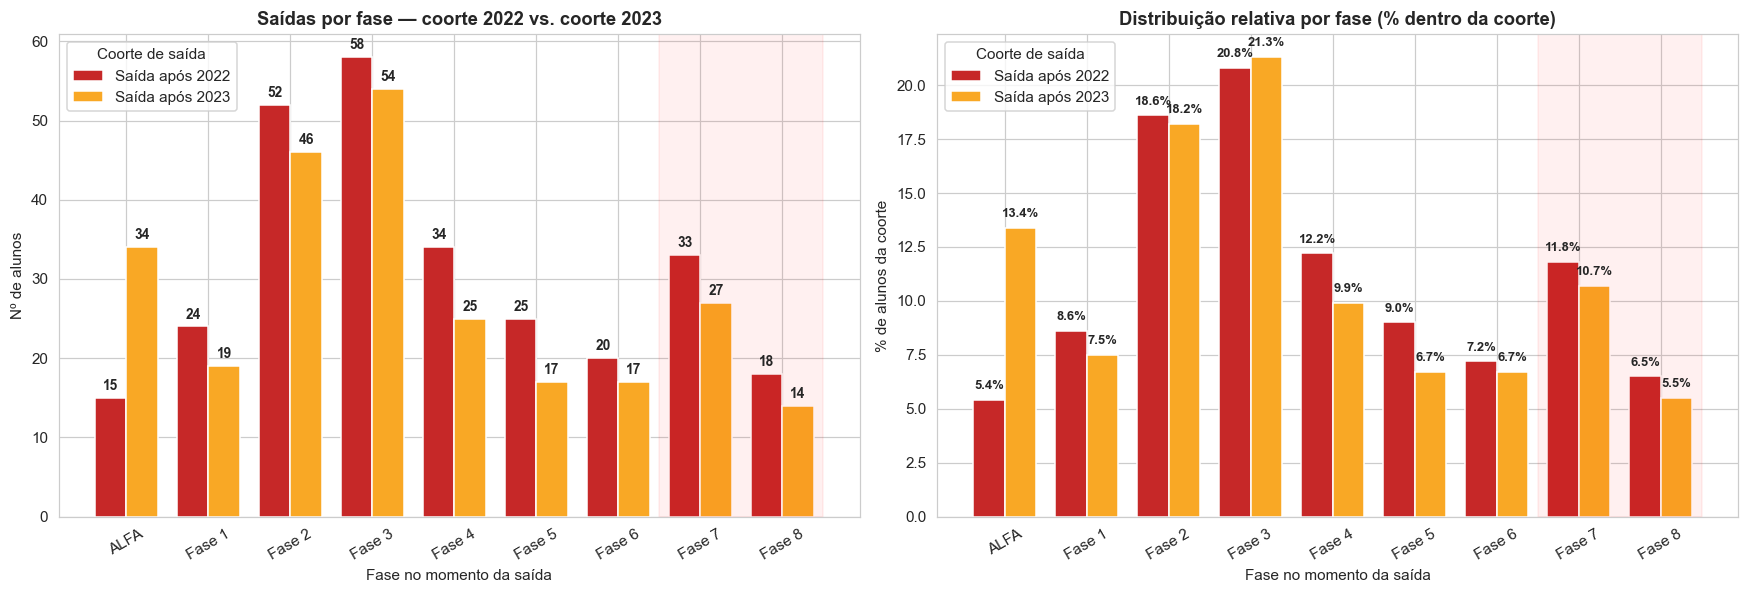

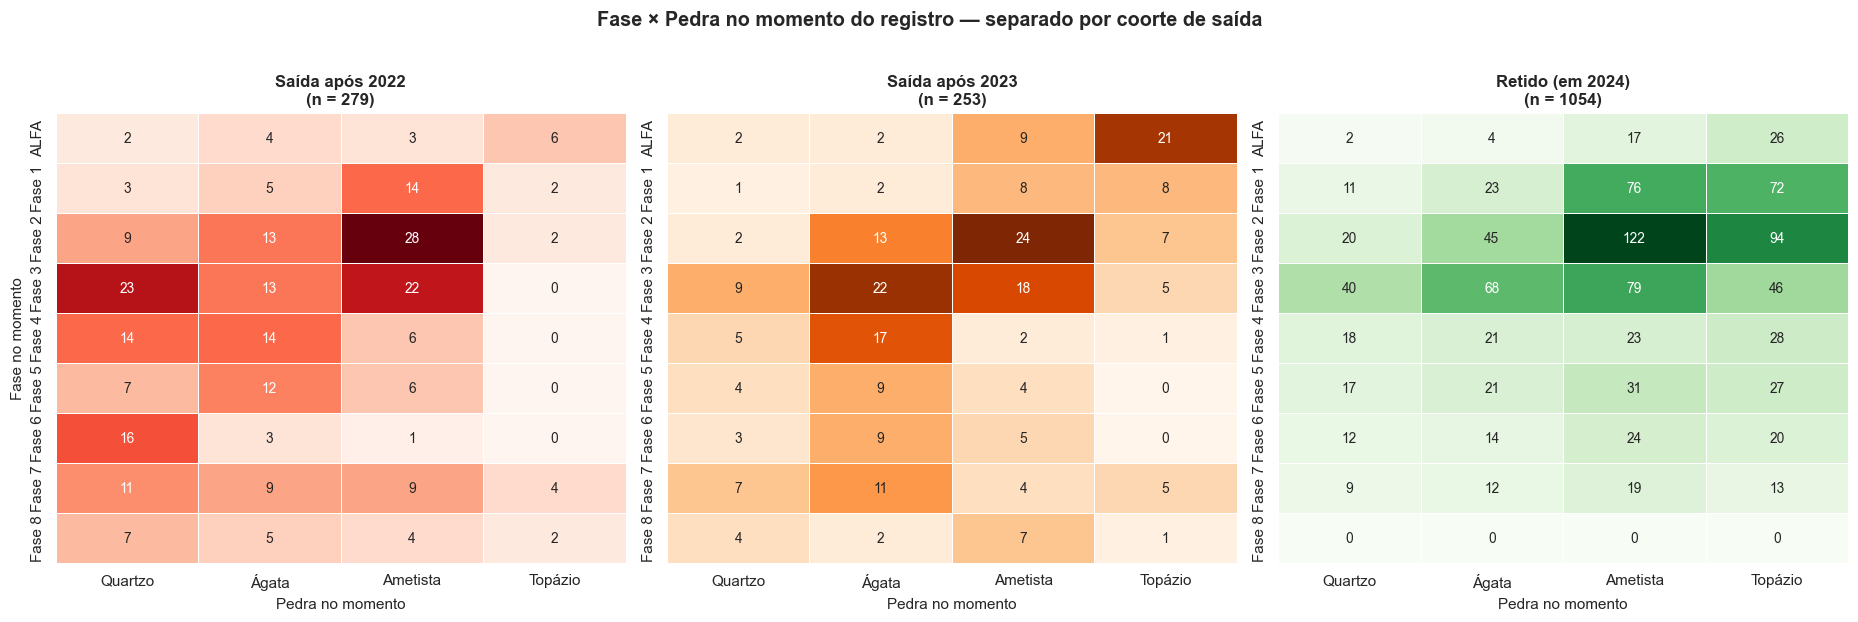

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:299: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados,
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:299: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados,
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:299: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados,
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:299: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old nam

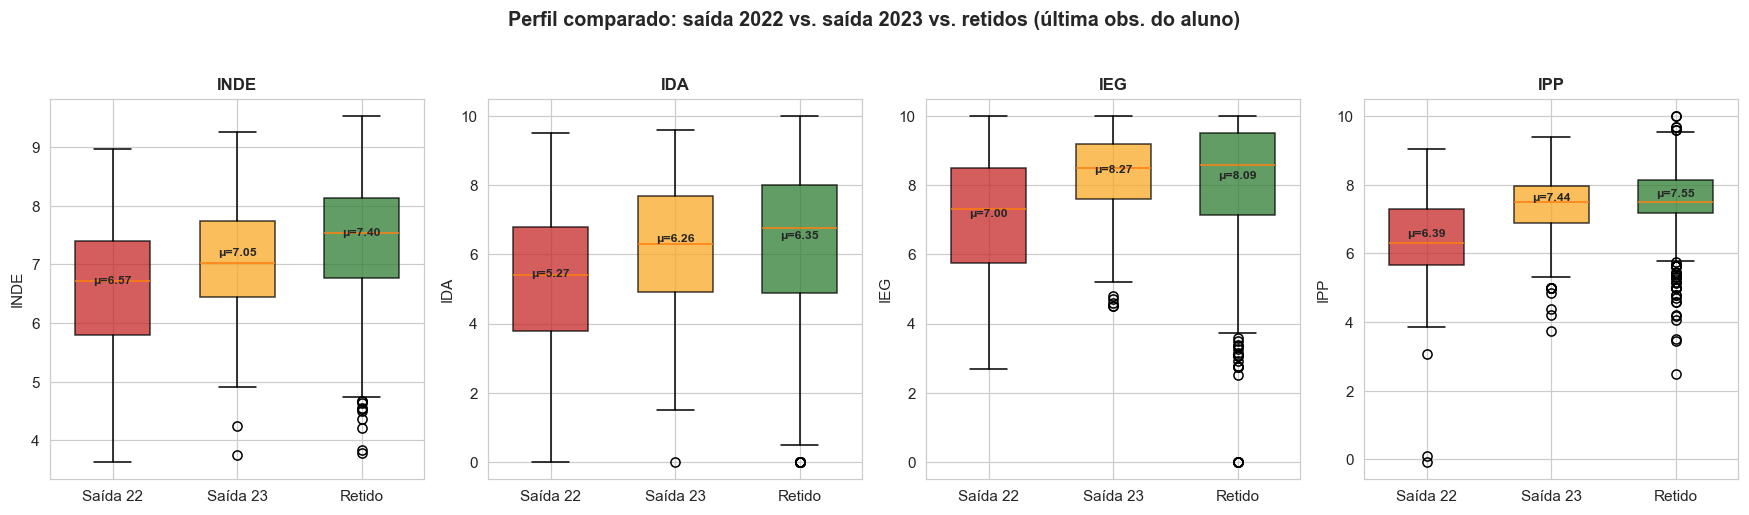

C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:332: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
C:\Users\fabio\AppData\Local\Temp\ipykernel_24784\2977367868.py:332: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({



8. TAXA DE SAÍDA ANTES DA FASE FINAL POR PEDRA — POR COORTE
             Saída após 2022  Saída após 2023
pedra_saida                                  
Quartzo                 80.4             70.3
Ágata                   82.1             85.1
Ametista                86.0             86.4
Topázio                 62.5             87.5


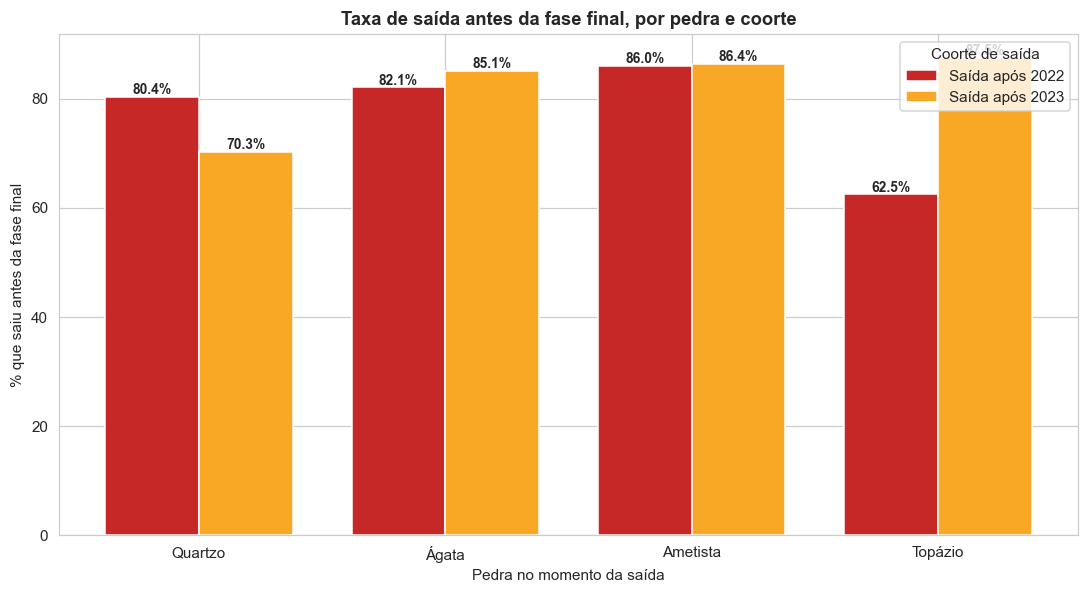


9. DIAGNÓSTICO — TENDÊNCIAS COMUNS E ESPECÍFICAS

▶ Tamanhos das coortes:
   Saída após 2022: 279 alunos
   Saída após 2023: 253 alunos
   Retidos em 2024: 1054 alunos

▶ Fase mais comum de saída:
   Coorte 2022: Fase 3 (58 alunos, 20.8%)
   Coorte 2023: Fase 3 (54 alunos, 21.3%)

▶ % que saiu antes da fase final:
   Coorte 2022: 81.7%
   Coorte 2023: 83.8%

▶ Perfil médio dos que saíram em cada coorte:
   INDE        : 2022 = 6.57 | 2023 = 7.05 | Δ = +0.49
   IDA         : 2022 = 5.27 | 2023 = 6.26 | Δ = +0.99
   IEG         : 2022 = 7.00 | 2023 = 8.27 | Δ = +1.27
   IPP         : 2022 = 6.39 | 2023 = 7.44 | Δ = +1.05

VEREDITO — TENDÊNCIAS
→ ✅ TENDÊNCIA COMUM: ambas as coortes têm pico de saída em Fase 3.
   Isso sugere um gargalo estrutural do programa nessa fase.

→ ✅ TENDÊNCIA COMUM: em ambas as coortes, mais de 60% das saídas ocorrem antes da fase final.

▶ Δ INDE (evadido − retido):
   Coorte 2022: -0.83
   Coorte 2023: -0.34
→ ✅ TENDÊNCIA COMUM: em ambas as coortes, evadidos t

In [81]:
# ============================================================
# 0. IMPORTS E CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
               'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

ORDEM_PEDRAS = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
CORES_PEDRAS = {
    'Quartzo':  '#9E9E9E',
    'Ágata':    '#26A69A',
    'Ametista': '#7E57C2',
    'Topázio':  '#F9A825',
}
df['pedra_ano_atual'] = pd.Categorical(df['pedra_ano_atual'],
                                       categories=ORDEM_PEDRAS, ordered=True)

FASES_FINAIS = ['Fase 7', 'Fase 8']

print(f"Base: {df.shape[0]} registros")
print(f"RAs únicos: {df['RA'].nunique()}")


# ============================================================
# 1. CLASSIFICAÇÃO DE CADA ALUNO POR ÚLTIMO ANO NA BASE
# ============================================================
# Última observação de cada RA (dados do ano de saída)
ult_obs = (
    df.sort_values('ano')
      .groupby('RA', as_index=False)
      .last()
      .rename(columns={'ano': 'ultimo_ano',
                       'Fase_Ideal_1': 'fase_saida',
                       'pedra_ano_atual': 'pedra_saida',
                       'INDE_ano_atual': 'INDE_saida',
                       'IDA': 'IDA_saida',
                       'IEG': 'IEG_saida',
                       'IPP': 'IPP_saida',
                       'IPS': 'IPS_saida',
                       'IAA': 'IAA_saida',
                       'IAN': 'IAN_saida',
                       'Defasagem': 'Defasagem_saida'})
)

# Status por último ano
ult_obs['status'] = ult_obs['ultimo_ano'].map({
    2022: 'Saída após 2022',
    2023: 'Saída após 2023',
    2024: 'Retido (em 2024)',
})

# Marca se a saída foi na fase final (possível conclusão) ou antes
ult_obs['tipo_saida'] = np.where(
    ult_obs['status'] == 'Retido (em 2024)',
    'Retido',
    np.where(ult_obs['fase_saida'].isin(FASES_FINAIS),
             'Saída na fase final (conclusão?)',
             'Saída antes da fase final')
)

print("\n" + "=" * 78)
print("1. CLASSIFICAÇÃO DE TODOS OS RAs POR ÚLTIMO ANO NA BASE")
print("=" * 78)
print(ult_obs['status'].value_counts().to_string())

print("\n▶ Cruzamento status × tipo de saída:")
cruz = pd.crosstab(ult_obs['status'], ult_obs['tipo_saida'])
cruz['Total'] = cruz.sum(axis=1)
cruz.loc['Total'] = cruz.sum(axis=0)
print(cruz.to_string())


# ============================================================
# 2. APENAS ALUNOS QUE SAÍRAM — SEPARADOS POR COORTE DE SAÍDA
# ============================================================
saidas = ult_obs[ult_obs['status'] != 'Retido (em 2024)'].copy()
saidas['fase_saida'] = pd.Categorical(saidas['fase_saida'],
                                      categories=ordem_fases, ordered=True)

print("\n" + "=" * 78)
print("2. ALUNOS QUE SAÍRAM — SEPARADOS POR COORTE DE SAÍDA")
print("=" * 78)

for coorte in ['Saída após 2022', 'Saída após 2023']:
    sub = saidas[saidas['status'] == coorte]
    print(f"\n▶ {coorte}: {len(sub)} alunos")

    # Por fase de saída
    dist = sub['fase_saida'].value_counts().reindex(ordem_fases, fill_value=0)
    dist_pct = (dist / dist.sum() * 100).round(1) if dist.sum() > 0 else dist
    print(f"\n   Distribuição por fase de saída:")
    for fase in ordem_fases:
        if dist[fase] > 0:
            print(f"      {fase:<10}: {dist[fase]:>3} ({dist_pct[fase]:>5.1f}%)")

    # Por tipo (antes/final)
    tipo = sub['tipo_saida'].value_counts()
    print(f"\n   Tipo de saída:")
    for t, n in tipo.items():
        print(f"      {t:<35}: {n} ({n/len(sub)*100:.1f}%)")

    # Por pedra na saída
    pedra = sub['pedra_saida'].value_counts().reindex(ORDEM_PEDRAS, fill_value=0)
    print(f"\n   Pedra no momento da saída:")
    for p in ORDEM_PEDRAS:
        if pedra[p] > 0:
            print(f"      {p:<10}: {pedra[p]:>3} ({pedra[p]/len(sub)*100:>5.1f}%)")


# ============================================================
# 3. PERFIL DOS INDICADORES — COMPARADO POR COORTE DE SAÍDA
# ============================================================
INDICADORES = ['INDE_saida', 'IDA_saida', 'IEG_saida', 'IPP_saida',
               'IPS_saida', 'IAA_saida', 'IAN_saida', 'Defasagem_saida']

grupos = ['Saída após 2022', 'Saída após 2023', 'Retido (em 2024)']
cores_g = {
    'Saída após 2022': '#C62828',
    'Saída após 2023': '#F9A825',
    'Retido (em 2024)': '#2E7D32',
}

perfil = (
    ult_obs.groupby('status')[INDICADORES]
           .agg(['mean', 'median', 'count'])
           .round(2)
)
print("\n" + "=" * 78)
print("3. PERFIL DOS INDICADORES POR COORTE DE SAÍDA (última obs. do aluno)")
print("=" * 78)
print(perfil.to_string())

# Comparação direta lado a lado
print("\n▶ Comparação direta das médias:")
print(f"   {'Indicador':<18} {'Saída 2022':>12} {'Saída 2023':>12} "
      f"{'Retido':>10} {'Δ(23−22)':>10}")
print("   " + "-" * 68)

for ind in INDICADORES:
    m22 = ult_obs.loc[ult_obs['status'] == 'Saída após 2022', ind].mean()
    m23 = ult_obs.loc[ult_obs['status'] == 'Saída após 2023', ind].mean()
    mret = ult_obs.loc[ult_obs['status'] == 'Retido (em 2024)', ind].mean()
    if pd.notna(m22) and pd.notna(m23):
        print(f"   {ind:<18} {m22:>12.2f} {m23:>12.2f} "
              f"{mret:>10.2f} {m23-m22:>+10.2f}")

# Testes estatísticos: saída 2022 vs. saída 2023
print("\n▶ Testes de Mann-Whitney — saída 2022 vs. saída 2023:")
for ind in INDICADORES:
    g22 = ult_obs.loc[ult_obs['status'] == 'Saída após 2022', ind].dropna()
    g23 = ult_obs.loc[ult_obs['status'] == 'Saída após 2023', ind].dropna()
    if len(g22) >= 10 and len(g23) >= 10:
        stat, p = stats.mannwhitneyu(g22, g23, alternative='two-sided')
        sig = '✓' if p < 0.05 else '×'
        print(f"   {ind:<18} U = {stat:>10.0f}  p = {p:.5f}  {sig}")


# ============================================================
# 4. DISTRIBUIÇÃO POR FASE — AS DUAS COORTES LADO A LADO
# ============================================================
dist_22 = (saidas[saidas['status'] == 'Saída após 2022']
           ['fase_saida'].value_counts().reindex(ordem_fases, fill_value=0))
dist_23 = (saidas[saidas['status'] == 'Saída após 2023']
           ['fase_saida'].value_counts().reindex(ordem_fases, fill_value=0))

dist_comp = pd.DataFrame({
    'Saída após 2022': dist_22,
    'Saída após 2023': dist_23,
})
dist_comp['Total'] = dist_comp.sum(axis=1)
dist_comp.loc['Total'] = dist_comp.sum(axis=0)

dist_comp_pct = pd.DataFrame({
    'Saída após 2022': (dist_22 / dist_22.sum() * 100).round(1),
    'Saída após 2023': (dist_23 / dist_23.sum() * 100).round(1),
})

print("\n" + "=" * 78)
print("4. DISTRIBUIÇÃO POR FASE DE SAÍDA — COMPARAÇÃO ENTRE COORTES")
print("=" * 78)
print("Contagens absolutas:")
print(dist_comp.to_string())
print("\nPercentual dentro de cada coorte:")
print(dist_comp_pct.to_string())


# ============================================================
# 5. VISUALIZAÇÃO 1 — Saídas por fase, comparando as duas coortes
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 5.1 Contagem absoluta lado a lado
x = np.arange(len(ordem_fases))
w = 0.38
b1 = axes[0].bar(x - w/2, dist_comp.loc[ordem_fases, 'Saída após 2022'],
                 width=w, color='#C62828', edgecolor='white',
                 label='Saída após 2022')
b2 = axes[0].bar(x + w/2, dist_comp.loc[ordem_fases, 'Saída após 2023'],
                 width=w, color='#F9A825', edgecolor='white',
                 label='Saída após 2023')

for bars in [b1, b2]:
    for b in bars:
        if b.get_height() > 0:
            axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                         f"{int(b.get_height())}", ha='center',
                         fontsize=9, fontweight='bold')

axes[0].axvspan(ordem_fases.index('Fase 7') - 0.5,
                len(ordem_fases) - 0.5, color='red', alpha=0.06)
axes[0].set_xticks(x)
axes[0].set_xticklabels(ordem_fases, rotation=30)
axes[0].set_title('Saídas por fase — coorte 2022 vs. coorte 2023',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fase no momento da saída')
axes[0].set_ylabel('Nº de alunos')
axes[0].legend(title='Coorte de saída')

# 5.2 Percentual dentro de cada coorte
b1 = axes[1].bar(x - w/2, dist_comp_pct['Saída após 2022'],
                 width=w, color='#C62828', edgecolor='white',
                 label='Saída após 2022')
b2 = axes[1].bar(x + w/2, dist_comp_pct['Saída após 2023'],
                 width=w, color='#F9A825', edgecolor='white',
                 label='Saída após 2023')

for bars in [b1, b2]:
    for b in bars:
        if b.get_height() > 0:
            axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                         f"{b.get_height():.1f}%", ha='center',
                         fontsize=8.5, fontweight='bold')

axes[1].axvspan(ordem_fases.index('Fase 7') - 0.5,
                len(ordem_fases) - 0.5, color='red', alpha=0.06)
axes[1].set_xticks(x)
axes[1].set_xticklabels(ordem_fases, rotation=30)
axes[1].set_title('Distribuição relativa por fase (% dentro da coorte)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Fase no momento da saída')
axes[1].set_ylabel('% de alunos da coorte')
axes[1].legend(title='Coorte de saída')

plt.tight_layout()
plt.show()


# ============================================================
# 6. VISUALIZAÇÃO 2 — Heatmap Fase de saída × Coorte × Pedra
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

for ax, (coorte, cor) in zip(axes, [('Saída após 2022', 'Reds'),
                                     ('Saída após 2023', 'Oranges'),
                                     ('Retido (em 2024)', 'Greens')]):
    sub = saidas if coorte != 'Retido (em 2024)' else ult_obs
    sub = sub[sub['status'] == coorte]

    heat = pd.crosstab(sub['fase_saida'], sub['pedra_saida'])
    heat = heat.reindex(index=ordem_fases, columns=ORDEM_PEDRAS, fill_value=0)

    sns.heatmap(heat, annot=True, fmt='d', cmap=cor,
                linewidths=0.6, cbar=False, ax=ax,
                annot_kws={'size': 9})
    ax.set_title(f'{coorte}\n(n = {len(sub)})',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Pedra no momento')
    ax.set_ylabel('Fase no momento' if ax == axes[0] else '')

plt.suptitle('Fase × Pedra no momento do registro — separado por coorte de saída',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 7. VISUALIZAÇÃO 3 — Perfil comparado entre coortes (boxplot)
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(16, 4.5))

for ax, ind in zip(axes, ['INDE_saida', 'IDA_saida', 'IEG_saida', 'IPP_saida']):
    dados = [ult_obs.loc[ult_obs['status'] == g, ind].dropna() for g in grupos]

    if all(len(d) > 0 for d in dados):
        bp = ax.boxplot(dados,
                        labels=['Saída 22', 'Saída 23', 'Retido'],
                        patch_artist=True, widths=0.6)
        for patch, g in zip(bp['boxes'], grupos):
            patch.set_facecolor(cores_g[g])
            patch.set_alpha(0.75)

    # Anota as médias
    for i, (g, d) in enumerate(zip(grupos, dados), start=1):
        if len(d) > 0:
            ax.text(i, d.mean() + 0.1, f"μ={d.mean():.2f}",
                    ha='center', fontsize=8, fontweight='bold')

    ax.set_title(ind.replace('_saida', ''), fontsize=11, fontweight='bold')
    ax.set_ylabel(ind.replace('_saida', ''))
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Perfil comparado: saída 2022 vs. saída 2023 vs. retidos '
             '(última obs. do aluno)',
             fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ============================================================
# 8. VISUALIZAÇÃO 4 — Taxa de saída antes do fim, por coorte e pedra
# ============================================================
def taxa_evasao_por_pedra(df_in, coorte):
    sub = df_in[df_in['status'] == coorte]
    if len(sub) == 0:
        return pd.Series(dtype=float)
    tab = (
        sub.groupby('pedra_saida', observed=True)
           .apply(lambda g: pd.Series({
               'n_total': len(g),
               'evadiu_antes_fim': (
                   g['tipo_saida'] == 'Saída antes da fase final'
               ).sum(),
           }))
    )
    tab['taxa_evasao'] = (tab['evadiu_antes_fim'] / tab['n_total'] * 100).round(1)
    return tab['taxa_evasao'].reindex(ORDEM_PEDRAS)

tx_22 = taxa_evasao_por_pedra(saidas, 'Saída após 2022')
tx_23 = taxa_evasao_por_pedra(saidas, 'Saída após 2023')

taxa_comp = pd.DataFrame({
    'Saída após 2022': tx_22,
    'Saída após 2023': tx_23,
}).round(1)

print("\n" + "=" * 78)
print("8. TAXA DE SAÍDA ANTES DA FASE FINAL POR PEDRA — POR COORTE")
print("=" * 78)
print(taxa_comp.to_string())

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(ORDEM_PEDRAS))
w = 0.38

vals_22 = taxa_comp['Saída após 2022'].fillna(0).values
vals_23 = taxa_comp['Saída após 2023'].fillna(0).values

b1 = ax.bar(x - w/2, vals_22, width=w, color='#C62828',
            edgecolor='white', label='Saída após 2022')
b2 = ax.bar(x + w/2, vals_23, width=w, color='#F9A825',
            edgecolor='white', label='Saída após 2023')

for bars in [b1, b2]:
    for b in bars:
        if b.get_height() > 0:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.5,
                    f"{b.get_height():.1f}%", ha='center',
                    fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(ORDEM_PEDRAS)
ax.set_title('Taxa de saída antes da fase final, por pedra e coorte',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Pedra no momento da saída')
ax.set_ylabel('% que saiu antes da fase final')
ax.legend(title='Coorte de saída')
plt.tight_layout()
plt.show()


# ============================================================
# 9. DIAGNÓSTICO — TENDÊNCIAS COMUNS ENTRE AS DUAS COORTES
# ============================================================
print("\n" + "=" * 78)
print("9. DIAGNÓSTICO — TENDÊNCIAS COMUNS E ESPECÍFICAS")
print("=" * 78)

n_22 = (saidas['status'] == 'Saída após 2022').sum()
n_23 = (saidas['status'] == 'Saída após 2023').sum()
n_ret = (ult_obs['status'] == 'Retido (em 2024)').sum()

print(f"\n▶ Tamanhos das coortes:")
print(f"   Saída após 2022: {n_22} alunos")
print(f"   Saída após 2023: {n_23} alunos")
print(f"   Retidos em 2024: {n_ret} alunos")

# Fase mais comum em cada coorte
fase_top_22 = dist_22.idxmax() if dist_22.sum() > 0 else None
fase_top_23 = dist_23.idxmax() if dist_23.sum() > 0 else None

print(f"\n▶ Fase mais comum de saída:")
print(f"   Coorte 2022: {fase_top_22} "
      f"({dist_22.max()} alunos, {dist_22.max()/max(dist_22.sum(),1)*100:.1f}%)")
print(f"   Coorte 2023: {fase_top_23} "
      f"({dist_23.max()} alunos, {dist_23.max()/max(dist_23.sum(),1)*100:.1f}%)")

# % que saiu antes da fase final, por coorte
pct_antes_22 = ((saidas[saidas['status'] == 'Saída após 2022']
                 ['tipo_saida'] == 'Saída antes da fase final').mean() * 100)
pct_antes_23 = ((saidas[saidas['status'] == 'Saída após 2023']
                 ['tipo_saida'] == 'Saída antes da fase final').mean() * 100)

print(f"\n▶ % que saiu antes da fase final:")
print(f"   Coorte 2022: {pct_antes_22:.1f}%")
print(f"   Coorte 2023: {pct_antes_23:.1f}%")

# Perfil médio
print(f"\n▶ Perfil médio dos que saíram em cada coorte:")
for ind in ['INDE_saida', 'IDA_saida', 'IEG_saida', 'IPP_saida']:
    m22 = ult_obs.loc[ult_obs['status'] == 'Saída após 2022', ind].mean()
    m23 = ult_obs.loc[ult_obs['status'] == 'Saída após 2023', ind].mean()
    print(f"   {ind.replace('_saida', ''):<12}: "
          f"2022 = {m22:.2f} | 2023 = {m23:.2f} | Δ = {m23-m22:+.2f}")

print("\n" + "=" * 78)
print("VEREDITO — TENDÊNCIAS")
print("=" * 78)

# 1. Mesma fase de pico?
if fase_top_22 == fase_top_23:
    print(f"→ ✅ TENDÊNCIA COMUM: ambas as coortes têm pico de saída em "
          f"{fase_top_22}.")
    print("   Isso sugere um gargalo estrutural do programa nessa fase.")
else:
    print(f"→ ⚠️ GARGALOS DIFERENTES: coorte 2022 sai mais em {fase_top_22}; "
          f"coorte 2023 sai mais em {fase_top_23}.")
    print("   O padrão de saída mudou entre os dois momentos.")

# 2. Concentração antes da fase final
if pct_antes_22 > 60 and pct_antes_23 > 60:
    print(f"\n→ ✅ TENDÊNCIA COMUM: em ambas as coortes, mais de 60% das "
          f"saídas ocorrem antes da fase final.")
elif abs(pct_antes_22 - pct_antes_23) < 10:
    print(f"\n→ TENDÊNCIA ESTÁVEL: saída antes da fase final em "
          f"{pct_antes_22:.0f}% (2022) e {pct_antes_23:.0f}% (2023).")
else:
    print(f"\n→ ⚠️ MUDANÇA TEMPORAL: em 2022, {pct_antes_22:.0f}% saíram "
          f"antes do fim; em 2023, {pct_antes_23:.0f}%.")
    if pct_antes_23 > pct_antes_22:
        print("   Houve AUMENTO das saídas precoces — piora.")
    else:
        print("   Houve REDUÇÃO das saídas precoces — melhora.")

# 3. Perfil dos evadidos
delta_inde_22 = (ult_obs.loc[ult_obs['status'] == 'Saída após 2022',
                             'INDE_saida'].mean()
                 - ult_obs.loc[ult_obs['status'] == 'Retido (em 2024)',
                               'INDE_saida'].mean())
delta_inde_23 = (ult_obs.loc[ult_obs['status'] == 'Saída após 2023',
                             'INDE_saida'].mean()
                 - ult_obs.loc[ult_obs['status'] == 'Retido (em 2024)',
                               'INDE_saida'].mean())

print(f"\n▶ Δ INDE (evadido − retido):")
print(f"   Coorte 2022: {delta_inde_22:+.2f}")
print(f"   Coorte 2023: {delta_inde_23:+.2f}")

if delta_inde_22 < -0.2 and delta_inde_23 < -0.2:
    print("→ ✅ TENDÊNCIA COMUM: em ambas as coortes, evadidos têm INDE "
          "menor que retidos.")
    print("   A evasão é seletiva por desempenho — alunos mais frágeis saem.")
elif delta_inde_22 > 0.2 and delta_inde_23 > 0.2:
    print("→ ⚠️ TENDÊNCIA COMUM: em ambas as coortes, evadidos têm INDE "
          "MAIOR que retidos.")
    print("   Alunos com bom desempenho estão saindo — possível efeito de "
          "conclusão/migração.")
else:
    print("→ Perfis diferentes entre coortes — investigar caso a caso.")

Analise do pico - fases 2 e 3

Base: 2845 registros
RAs únicos: 1586

1. CLASSIFICAÇÃO GERAL DOS RAs
status
Retido (em 2024)    1054
Saída após 2022      279
Saída após 2023      253

2. UNIVERSO — ALUNOS CUJA ÚLTIMA OBSERVAÇÃO FOI EM FASE 2 OU 3
status
Retido (em 2024)    514
Saída após 2022     110
Saída após 2023     100

▶ Cruzamento Fase × Status:
status      Retido (em 2024)  Saída após 2022  Saída após 2023  Total
fase_saida                                                           
Fase 2                   281               52               46    379
Fase 3                   233               58               54    345
Total                    514              110              100    724

3. GRUPOS DE COMPARAÇÃO — FASES 2 E 3

▶ Coorte 2022 (quem estava em Fase 2/3 em 2022):
grupo
Ficou (após 2022)    312
Saiu (após 2022)     113

▶ Coorte 2023 (quem estava em Fase 2/3 em 2023):
grupo
Ficou (após 2023)    349
Saiu (após 2023)     100

4. PERFIL — COORTE 2022 (Fase 2 e 3)
                  INDE_ano_atual     

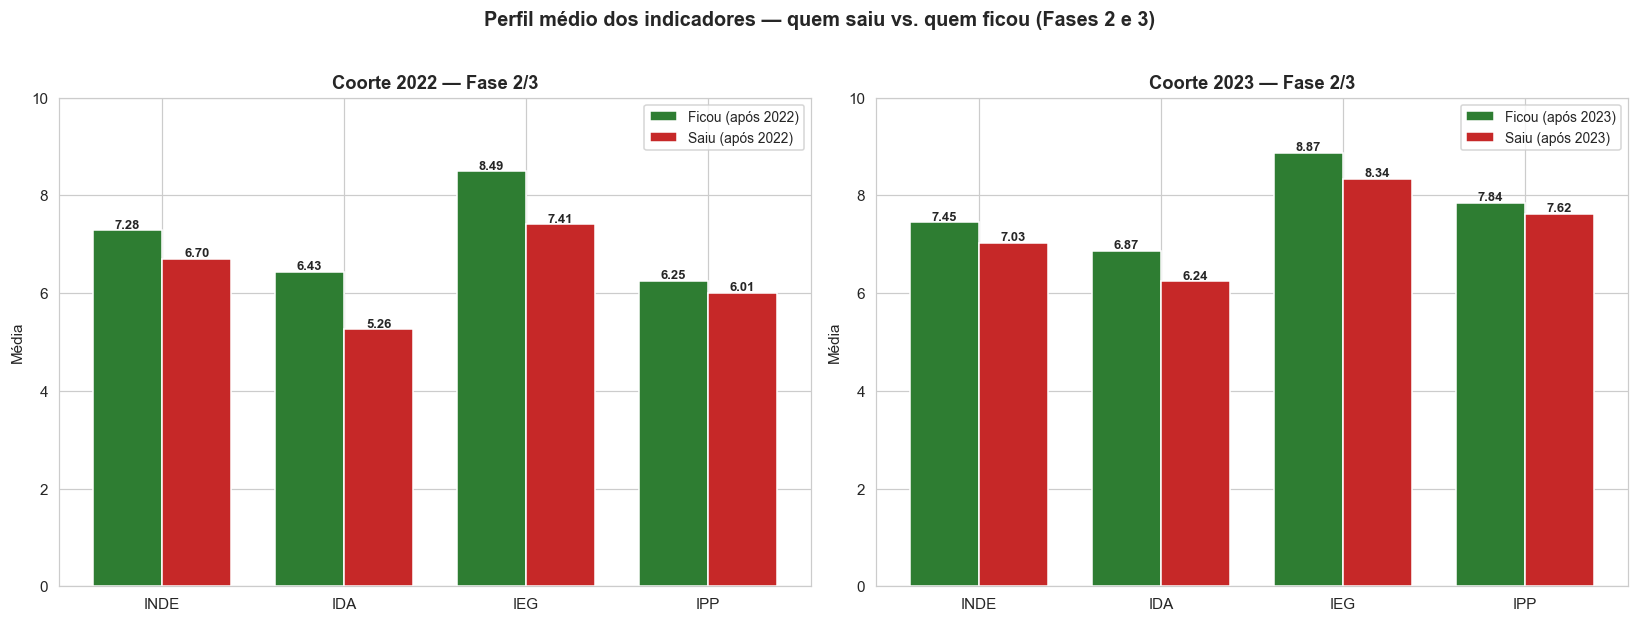

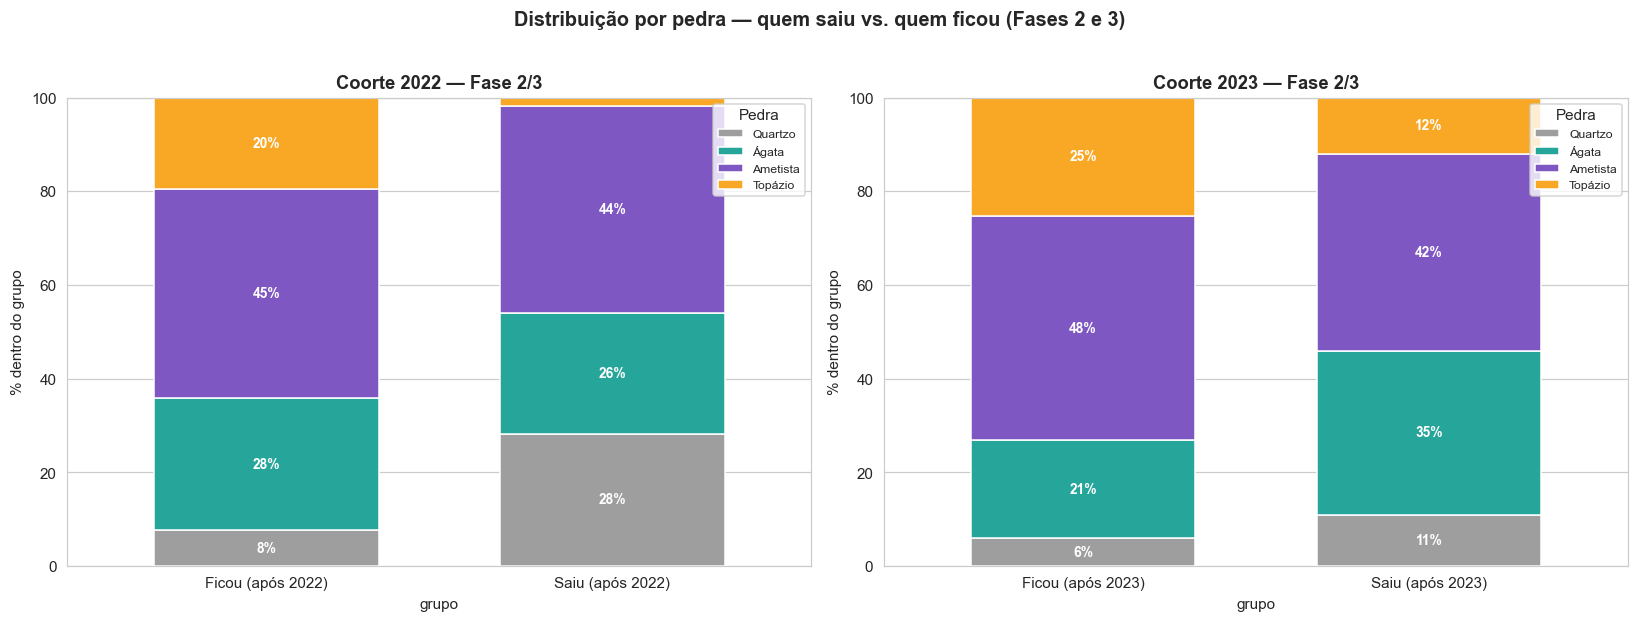

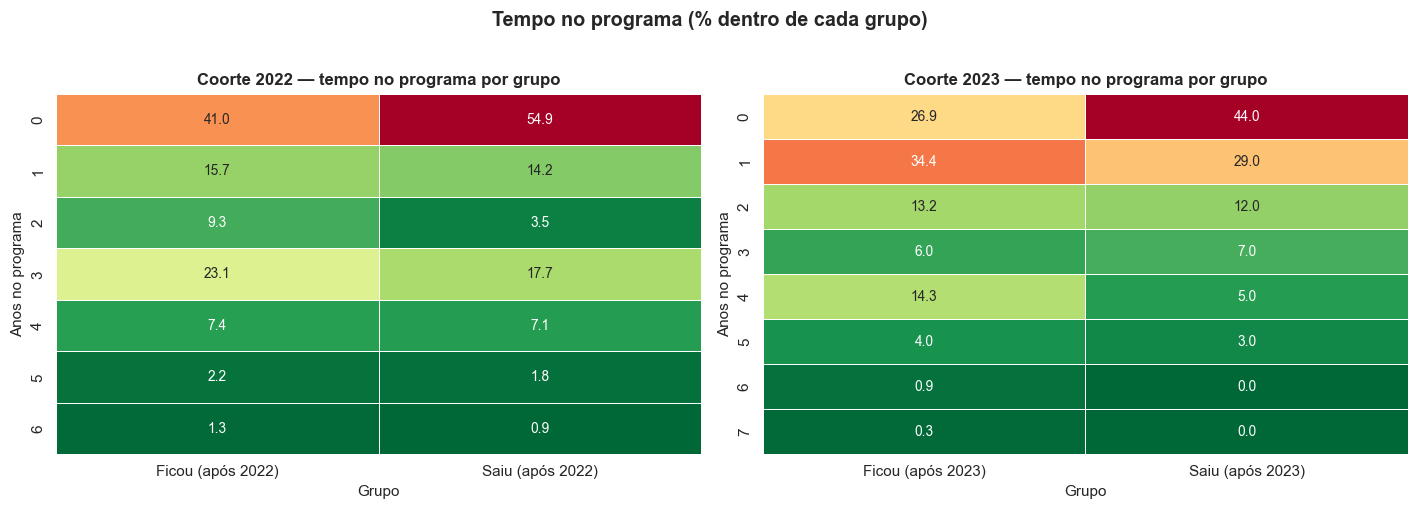


9. Δ (Saiu − Ficou) POR INDICADOR E COORTE
                Δ 2022 (Saiu−Ficou)  Δ 2023 (Saiu−Ficou)
Indicador                                               
INDE_ano_atual                -0.58                -0.42
IDA                           -1.17                -0.63
IEG                           -1.08                -0.53
IPP                           -0.24                -0.22
IPS                            0.03                -0.28
IAA                           -0.12                -0.66
IAN                            0.23                -0.26
Defasagem                      0.01                -0.08


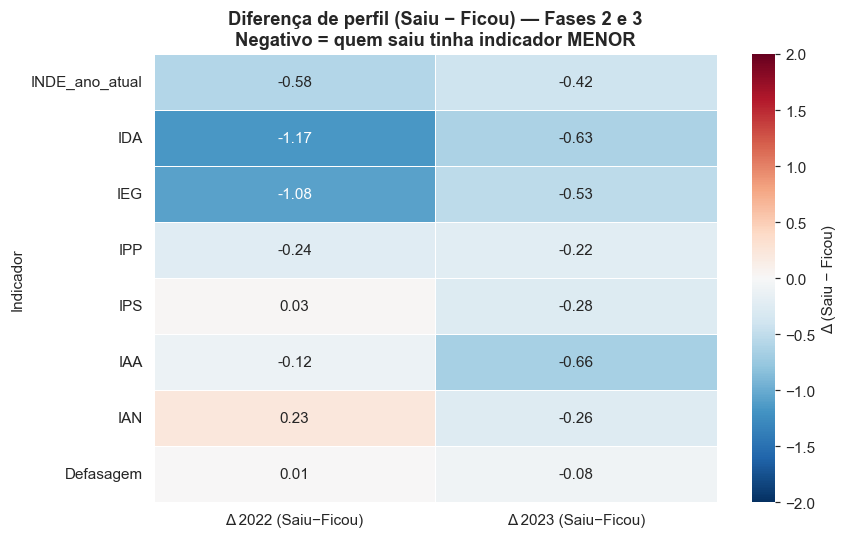


10. DIAGNÓSTICO — PADRÕES DE SAÍDA NAS FASES 2 E 3

▶ Universo (última obs. em Fase 2 ou 3): 724 alunos
   Saída após 2022: 110
   Saída após 2023: 100
   Retido em 2024: 514

▶ Tendências comuns (aparecem nas DUAS coortes):
   ⚠️ INDE_ano_atual: quem SAI tem indicador MENOR nas duas coortes (Δ22=-0.58, Δ23=-0.42)
   ⚠️ IDA: quem SAI tem indicador MENOR nas duas coortes (Δ22=-1.17, Δ23=-0.63)
   ⚠️ IEG: quem SAI tem indicador MENOR nas duas coortes (Δ22=-1.08, Δ23=-0.53)
   ⚠️ IPP: quem SAI tem indicador MENOR nas duas coortes (Δ22=-0.24, Δ23=-0.22)
   ➖ Defasagem: sem diferença clara entre saiu/ficou

VEREDITO
→ ✅ PADRÃO CLARO: alunos que saem das Fases 2 e 3 têm, consistentemente, indicadores MENORES que quem fica.
   Sugere evasão seletiva por fragilidade acadêmica / engajamento.

▶ Indicador que MAIS discrimina saiu vs. ficou: IDA (|Δ| médio = 0.90)

▶ Gênero:

   Coorte 2022:
   Gênero             Feminino  Masculino
   grupo                                 
   Ficou (após 2022) 

In [82]:
# ============================================================
# 0. IMPORTS E CARGA
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(ARQUIVO,
                 encoding='utf-8', dtype={'RA': str}, low_memory=False)
df['ano'] = df['ano'].astype('Int64')

ordem_fases = ['ALFA', 'Fase 1', 'Fase 2', 'Fase 3', 'Fase 4',
               'Fase 5', 'Fase 6', 'Fase 7', 'Fase 8']
df['Fase_Ideal_1'] = pd.Categorical(df['Fase_Ideal_1'],
                                    categories=ordem_fases, ordered=True)

ORDEM_PEDRAS = ['Quartzo', 'Ágata', 'Ametista', 'Topázio']
CORES_PEDRAS = {
    'Quartzo':  '#9E9E9E',
    'Ágata':    '#26A69A',
    'Ametista': '#7E57C2',
    'Topázio':  '#F9A825',
}
df['pedra_ano_atual'] = pd.Categorical(df['pedra_ano_atual'],
                                       categories=ORDEM_PEDRAS, ordered=True)

FASES_FOCO = ['Fase 2', 'Fase 3']

print(f"Base: {df.shape[0]} registros")
print(f"RAs únicos: {df['RA'].nunique()}")


# ============================================================
# 1. CLASSIFICAÇÃO — ÚLTIMO ANO DE CADA ALUNO
# ============================================================
presenca = (
    df.groupby(['RA', 'ano'])
      .size()
      .unstack(fill_value=0)
      .astype(bool)
)
presenca.columns = [f'em_{int(c)}' for c in presenca.columns]

# Última observação de cada RA
ult_obs = (
    df.sort_values('ano')
      .groupby('RA', as_index=False)
      .last()
      .rename(columns={'ano': 'ultimo_ano',
                       'Fase_Ideal_1': 'fase_saida',
                       'pedra_ano_atual': 'pedra_saida',
                       'INDE_ano_atual': 'INDE',
                       'IDA': 'IDA',
                       'IEG': 'IEG',
                       'IPP': 'IPP',
                       'IPS': 'IPS',
                       'IAA': 'IAA',
                       'IAN': 'IAN',
                       'Defasagem': 'Defasagem',
                       'Gênero': 'Genero',
                       'Instituição de ensino': 'Instituicao',
                       'Ano ingresso': 'Ano_ingresso'})
)

ult_obs['status'] = ult_obs['ultimo_ano'].map({
    2022: 'Saída após 2022',
    2023: 'Saída após 2023',
    2024: 'Retido (em 2024)',
})

ult_obs['tempo_programa'] = (ult_obs['ultimo_ano']
                             - ult_obs['Ano_ingresso']).astype('Int64')

print("\n" + "=" * 78)
print("1. CLASSIFICAÇÃO GERAL DOS RAs")
print("=" * 78)
print(ult_obs['status'].value_counts().to_string())


# ============================================================
# 2. RECORTE — QUEM ESTAVA NAS FASES 2 OU 3
# ============================================================
# Para cada aluno, olhamos a Fase_Ideal_1 no momento da saída (ou no último ano)
# Consideramos "saída nas Fases 2 ou 3" quem TEM última obs. nessas fases

alunos_fase23 = ult_obs[ult_obs['fase_saida'].isin(FASES_FOCO)].copy()

print("\n" + "=" * 78)
print("2. UNIVERSO — ALUNOS CUJA ÚLTIMA OBSERVAÇÃO FOI EM FASE 2 OU 3")
print("=" * 78)
print(alunos_fase23['status'].value_counts().to_string())

# Cruzamento fase_saida × status
print("\n▶ Cruzamento Fase × Status:")
cruz = pd.crosstab(alunos_fase23['fase_saida'],
                   alunos_fase23['status'],
                   margins=True, margins_name='Total')
print(cruz.to_string())


# ============================================================
# 3. GRUPOS DE COMPARAÇÃO POR COORTE
# ============================================================
# Coorte 2022:
#   - Evadiu em 2022 (último ano = 2022)
#   - Reteve em 2022 (estava em 2022 e continuou em 2023)
#
# Coorte 2023:
#   - Evadiu em 2023 (último ano = 2023)
#   - Reteve em 2023 (estava em 2023 e continuou em 2024)

# Marca quem estava nas Fases 2 ou 3 em cada ano
df_f23 = df[df['Fase_Ideal_1'].isin(FASES_FOCO)].copy()

# Presença por RA/ano
presenca_ra = presenca.copy()

# --- Grupo evasão / retenção por coorte ---
def classificar_por_coorte(df_in, ano_base, ano_seguinte):
    """Classifica alunos que estavam em Fase 2/3 em `ano_base`."""
    sub = df_in[df_in['ano'] == ano_base].copy()
    sub = sub[sub['Fase_Ideal_1'].isin(FASES_FOCO)]

    # Estava no ano seguinte?
    sub['continuou'] = sub['RA'].map(
        presenca_ra[f'em_{ano_seguinte}'].to_dict()
    ).fillna(False)

    sub['grupo'] = np.where(sub['continuou'],
                            f'Ficou (após {ano_base})',
                            f'Saiu (após {ano_base})')
    return sub


f23_2022 = classificar_por_coorte(df_f23, 2022, 2023)
f23_2023 = classificar_por_coorte(df_f23, 2023, 2024)

print("\n" + "=" * 78)
print("3. GRUPOS DE COMPARAÇÃO — FASES 2 E 3")
print("=" * 78)
print("\n▶ Coorte 2022 (quem estava em Fase 2/3 em 2022):")
print(f23_2022['grupo'].value_counts().to_string())
print(f"\n▶ Coorte 2023 (quem estava em Fase 2/3 em 2023):")
print(f23_2023['grupo'].value_counts().to_string())


# ============================================================
# 4. PERFIL — INDICADORES NO MOMENTO DA SAÍDA vs. PERMANÊNCIA
# ============================================================
INDICADORES = ['INDE_ano_atual', 'IDA', 'IEG', 'IPP', 'IPS', 'IAA',
               'IAN', 'Defasagem']

def perfil_por_grupo(df_in, indicadores, grupo_col='grupo'):
    return (
        df_in.groupby(grupo_col)[indicadores]
             .agg(['mean', 'median', 'size'])
             .round(2)
    )

print("\n" + "=" * 78)
print("4. PERFIL — COORTE 2022 (Fase 2 e 3)")
print("=" * 78)
print(perfil_por_grupo(f23_2022, INDICADORES).to_string())

print("\n" + "=" * 78)
print("5. PERFIL — COORTE 2023 (Fase 2 e 3)")
print("=" * 78)
print(perfil_por_grupo(f23_2023, INDICADORES).to_string())


# ============================================================
# 5. TESTES ESTATÍSTICOS — SAIU vs. FICOU
# ============================================================
def testes_grupos(df_in, indicadores, grupo_col='grupo', label=''):
    """Mann-Whitney entre 'Saiu' e 'Ficou'."""
    print(f"\n▶ Testes Mann-Whitney — {label}")
    print(f"   {'Indicador':<18} {'Saiu (μ)':>10} {'Ficou (μ)':>10} "
          f"{'Δ':>8} {'p':>10} {'sig':>5}")
    print("   " + "-" * 63)

    grupos = df_in[grupo_col].unique()
    g_saiu = [g for g in grupos if 'Saiu' in g][0]
    g_ficou = [g for g in grupos if 'Ficou' in g][0]

    res = []
    for ind in indicadores:
        a = df_in.loc[df_in[grupo_col] == g_saiu, ind].dropna()
        b = df_in.loc[df_in[grupo_col] == g_ficou, ind].dropna()
        if len(a) >= 5 and len(b) >= 5:
            stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
            delta = a.mean() - b.mean()
            sig = '✓' if p < 0.05 else '×'
            print(f"   {ind:<18} {a.mean():>10.2f} {b.mean():>10.2f} "
                  f"{delta:>+8.2f} {p:>10.5f} {sig:>5}")
            res.append({'indicador': ind, 'delta': delta, 'p': p,
                        'grupo': label})
    return pd.DataFrame(res)


res_2022 = testes_grupos(f23_2022, INDICADORES, label='Coorte 2022 (Fase 2/3)')
res_2023 = testes_grupos(f23_2023, INDICADORES, label='Coorte 2023 (Fase 2/3)')


# ============================================================
# 6. PERFIL CATEGÓRICO — GÊNERO, PEDRA, INSTITUIÇÃO
# ============================================================
def perfil_categorico(df_in, col, label=''):
    tab = pd.crosstab(df_in[col], df_in['grupo'],
                      normalize='columns') * 100
    tab = tab.round(1)
    print(f"\n▶ {label} — distribuição (%) de '{col}' por grupo:")
    print(tab.to_string())


print("\n" + "=" * 78)
print("6. PERFIL CATEGÓRICO — COORTE 2022 (Fase 2 e 3)")
print("=" * 78)
perfil_categorico(f23_2022, 'Gênero', 'Coorte 2022')
perfil_categorico(f23_2022, 'pedra_ano_atual', 'Coorte 2022')
perfil_categorico(f23_2022, 'Instituição de ensino', 'Coorte 2022')

print("\n" + "=" * 78)
print("7. PERFIL CATEGÓRICO — COORTE 2023 (Fase 2 e 3)")
print("=" * 78)
perfil_categorico(f23_2023, 'Gênero', 'Coorte 2023')
perfil_categorico(f23_2023, 'pedra_ano_atual', 'Coorte 2023')
perfil_categorico(f23_2023, 'Instituição de ensino', 'Coorte 2023')


# ============================================================
# 7. TEMPO NO PROGRAMA — quem sai está há mais ou menos tempo?
# ============================================================
f23_2022['tempo_programa'] = (f23_2022['ano']
                              - f23_2022['Ano ingresso']).astype('Int64')
f23_2023['tempo_programa'] = (f23_2023['ano']
                              - f23_2023['Ano ingresso']).astype('Int64')

print("\n" + "=" * 78)
print("8. TEMPO NO PROGRAMA (anos) — SAIU vs. FICOU")
print("=" * 78)
for label, sub in [('Coorte 2022', f23_2022), ('Coorte 2023', f23_2023)]:
    print(f"\n▶ {label}:")
    print(sub.groupby('grupo')['tempo_programa']
             .agg(['mean', 'median', 'min', 'max', 'size'])
             .round(2).to_string())


# ============================================================
# 8. VISUALIZAÇÃO 1 — Perfil médio: saiu vs. ficou (por coorte)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

IND_PLOT = ['INDE_ano_atual', 'IDA', 'IEG', 'IPP']

for ax, (df_in, titulo) in zip(
        axes,
        [(f23_2022, 'Coorte 2022 — Fase 2/3'),
         (f23_2023, 'Coorte 2023 — Fase 2/3')]):

    medias = df_in.groupby('grupo')[IND_PLOT].mean()
    x = np.arange(len(IND_PLOT))
    w = 0.38

    grupos = medias.index.tolist()
    cores = ['#C62828' if 'Saiu' in g else '#2E7D32' for g in grupos]

    for i, (g, cor) in enumerate(zip(grupos, cores)):
        vals = medias.loc[g].values
        bars = ax.bar(x + (i - 0.5) * w, vals, width=w,
                      color=cor, edgecolor='white', label=g)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.05,
                    f"{v:.2f}", ha='center', fontsize=8.5,
                    fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([i.replace('_ano_atual', '') for i in IND_PLOT])
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('Média')
    ax.set_ylim(0, 10)
    ax.legend(fontsize=9)

plt.suptitle('Perfil médio dos indicadores — quem saiu vs. quem ficou '
             '(Fases 2 e 3)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 9. VISUALIZAÇÃO 2 — Distribuição por pedra (empilhado 100%)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for ax, (df_in, titulo) in zip(
        axes,
        [(f23_2022, 'Coorte 2022 — Fase 2/3'),
         (f23_2023, 'Coorte 2023 — Fase 2/3')]):

    tab = pd.crosstab(df_in['grupo'], df_in['pedra_ano_atual'],
                      normalize='index') * 100
    tab = tab.reindex(columns=ORDEM_PEDRAS, fill_value=0)

    tab.plot(kind='bar', stacked=True, ax=ax,
             color=[CORES_PEDRAS[p] for p in tab.columns],
             edgecolor='white', width=0.65)

    for i, grupo in enumerate(tab.index):
        y = 0
        for pedra in tab.columns:
            v = tab.loc[grupo, pedra]
            if v > 5:
                ax.text(i, y + v/2, f"{v:.0f}%", ha='center',
                        va='center', color='white', fontsize=9,
                        fontweight='bold')
            y += v

    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_ylabel('% dentro do grupo')
    ax.set_ylim(0, 100)
    ax.legend(title='Pedra', loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Distribuição por pedra — quem saiu vs. quem ficou (Fases 2 e 3)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 10. VISUALIZAÇÃO 3 — Heatmap tempo no programa × status
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, (df_in, titulo) in zip(
        axes,
        [(f23_2022, 'Coorte 2022'),
         (f23_2023, 'Coorte 2023')]):

    tab = pd.crosstab(df_in['tempo_programa'], df_in['grupo'],
                      normalize='columns') * 100
    tab = tab.round(1)

    sns.heatmap(tab, annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, cbar=False, ax=ax,
                annot_kws={'size': 9})

    ax.set_title(f'{titulo} — tempo no programa por grupo',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Grupo')
    ax.set_ylabel('Anos no programa')

plt.suptitle('Tempo no programa (% dentro de cada grupo)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# ============================================================
# 11. VISUALIZAÇÃO 4 — Comparação resumida saiu vs. ficou por coorte
# ============================================================
# Heatmap com Δ (saiu − ficou) em cada indicador e coorte
delta_tab = []
for ind in INDICADORES:
    m_saiu_22 = f23_2022.loc[f23_2022['grupo'].str.contains('Saiu'),
                              ind].mean()
    m_ficou_22 = f23_2022.loc[f23_2022['grupo'].str.contains('Ficou'),
                               ind].mean()
    m_saiu_23 = f23_2023.loc[f23_2023['grupo'].str.contains('Saiu'),
                              ind].mean()
    m_ficou_23 = f23_2023.loc[f23_2023['grupo'].str.contains('Ficou'),
                               ind].mean()
    delta_tab.append({
        'Indicador': ind,
        'Δ 2022 (Saiu−Ficou)': round(m_saiu_22 - m_ficou_22, 2),
        'Δ 2023 (Saiu−Ficou)': round(m_saiu_23 - m_ficou_23, 2),
    })

delta_df = pd.DataFrame(delta_tab).set_index('Indicador')
print("\n" + "=" * 78)
print("9. Δ (Saiu − Ficou) POR INDICADOR E COORTE")
print("=" * 78)
print(delta_df.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(delta_df, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-2, vmax=2, linewidths=0.6,
            cbar_kws={'label': 'Δ (Saiu − Ficou)'}, ax=ax)
ax.set_title('Diferença de perfil (Saiu − Ficou) — Fases 2 e 3\n'
             'Negativo = quem saiu tinha indicador MENOR',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


# ============================================================
# 12. DIAGNÓSTICO FINAL — QUEM SAI DAS FASES 2 E 3?
# ============================================================
print("\n" + "=" * 78)
print("10. DIAGNÓSTICO — PADRÕES DE SAÍDA NAS FASES 2 E 3")
print("=" * 78)

print(f"\n▶ Universo (última obs. em Fase 2 ou 3): {len(alunos_fase23)} alunos")
print(f"   Saída após 2022: "
      f"{(alunos_fase23['status'] == 'Saída após 2022').sum()}")
print(f"   Saída após 2023: "
      f"{(alunos_fase23['status'] == 'Saída após 2023').sum()}")
print(f"   Retido em 2024: "
      f"{(alunos_fase23['status'] == 'Retido (em 2024)').sum()}")

# Tendências comuns
print("\n▶ Tendências comuns (aparecem nas DUAS coortes):")
for ind in INDICADORES:
    d22 = delta_df.loc[ind, 'Δ 2022 (Saiu−Ficou)']
    d23 = delta_df.loc[ind, 'Δ 2023 (Saiu−Ficou)']

    if d22 < -0.15 and d23 < -0.15:
        print(f"   ⚠️ {ind}: quem SAI tem indicador MENOR nas duas coortes "
              f"(Δ22={d22:+.2f}, Δ23={d23:+.2f})")
    elif d22 > 0.15 and d23 > 0.15:
        print(f"   ⚠️ {ind}: quem SAI tem indicador MAIOR nas duas coortes "
              f"(Δ22={d22:+.2f}, Δ23={d23:+.2f})")
    elif abs(d22) < 0.1 and abs(d23) < 0.1:
        print(f"   ➖ {ind}: sem diferença clara entre saiu/ficou")

print("\n" + "=" * 78)
print("VEREDITO")
print("=" * 78)

# Detecta padrão dominante
padroes_negativos = sum(
    1 for ind in INDICADORES
    if delta_df.loc[ind, 'Δ 2022 (Saiu−Ficou)'] < -0.15
    and delta_df.loc[ind, 'Δ 2023 (Saiu−Ficou)'] < -0.15
)
padroes_positivos = sum(
    1 for ind in INDICADORES
    if delta_df.loc[ind, 'Δ 2022 (Saiu−Ficou)'] > 0.15
    and delta_df.loc[ind, 'Δ 2023 (Saiu−Ficou)'] > 0.15
)

if padroes_negativos >= 3:
    print("→ ✅ PADRÃO CLARO: alunos que saem das Fases 2 e 3 têm, "
          "consistentemente, indicadores MENORES que quem fica.")
    print("   Sugere evasão seletiva por fragilidade acadêmica / "
          "engajamento.")
elif padroes_positivos >= 3:
    print("→ ⚠️ PADRÃO INVERSO: alunos que saem têm indicadores MAIORES "
          "que quem fica.")
    print("   Possível migração por bom desempenho (bolsas em outras "
          "escolas, etc.).")
else:
    print("→ Padrão misto: nem todos os indicadores apontam na mesma "
          "direção.")
    print("   A saída nas Fases 2/3 não tem um único fator dominante.")

# Verifica qual indicador discrimina mais
delta_abs = delta_df.abs().mean(axis=1).sort_values(ascending=False)
print(f"\n▶ Indicador que MAIS discrimina saiu vs. ficou: "
      f"{delta_abs.index[0]} (|Δ| médio = {delta_abs.iloc[0]:.2f})")

# Comparação de gênero e pedra
print(f"\n▶ Gênero:")
for label, sub in [('Coorte 2022', f23_2022), ('Coorte 2023', f23_2023)]:
    tab = pd.crosstab(sub['grupo'], sub['Gênero'], normalize='index') * 100
    print(f"\n   {label}:")
    print("   " + tab.round(1).to_string().replace('\n', '\n   '))